# Step 2 — State-Level Competitiveness
**Objective:** Disaggregate Brazil's national trade picture to the state level — identifying which states drive exports and imports, which sectors and products dominate each region, how trade balances vary, how growth is distributed, and whether the China dependency identified in Step 1 is uniform or concentrated.

This notebook covers:
1. State Trade Participation
2. State Export Growth Dynamics
3. Regional Export and Import Distribution
4. Export Sector Structure
5. Import Sector Structure
6. Product-Level Detail
7. China Dependency
8. State Trade Hub Profiles
9. Regional Trade Hub Profiles
10. Commodities vs Processed Products
11. Unit Price Analysis
12. Volume vs Value
13. Market Concentration
14. Trade Self-Sufficiency
15. Key Findings

## Setup

This section initializes the database connection and establishes the time horizon of the analysis.  
The full series covers 1997–2025.

In [104]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import os
from pathlib import Path
from sqlalchemy import create_engine
from dotenv import load_dotenv
from IPython.display import display

# Credentials
dotenv_path = Path(r"C:\Users\e_koh\Downloads\State Analysis\brazil-state-trade-analysis\.env")
load_dotenv(dotenv_path, override=True)

DB_USER     = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST     = os.getenv("DB_HOST")
DB_PORT     = os.getenv("DB_PORT")
DB_NAME     = os.getenv("DB_NAME")

engine = create_engine(f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}")
print("Connected to database successfully")

## Data capped at 2025 — 2026 contains only partial year data which distorts trend visuals
MAX_YEAR  = 2025
MIN_YEAR  = 1997

Connected to database successfully


## 2.1 — State Trade Participation — Who Drives Brazilian Trade?


***Note:** REGIAO NAO DECLARADA (UNDECLARED) is retained to preserve total national trade volume. Its exports ($2.31bn) cannot be attributed to a specific state and will be excluded from any state-level structural analysis.*

### 2.1.1 - State Trade by Export Value
Ranking all states by export, import and balance value in the most recent year — establishing which states dominate national trade and how concentrated Brazil's trade geography is.

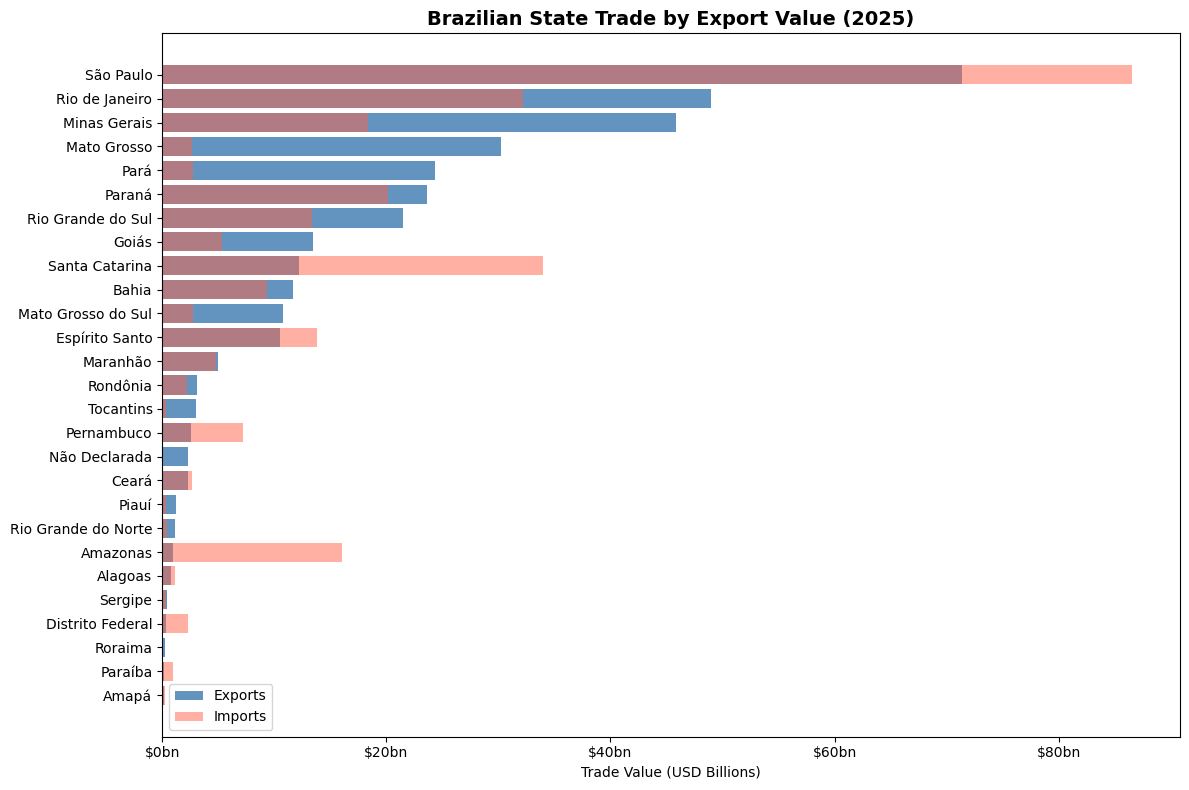


All States — Exports, Imports and Balance (2025)



State,Region,UF,Exports (USD bn),Imports (USD bn),Balance (USD bn)
São Paulo,Southeast,SP,$71.39bn,$86.50bn,-$15.11bn
Rio de Janeiro,Southeast,RJ,$48.98bn,$32.17bn,+$16.80bn
Minas Gerais,Southeast,MG,$45.83bn,$18.33bn,+$27.50bn
Mato Grosso,Center-West,MT,$30.19bn,$2.62bn,+$27.57bn
Pará,North,PA,$24.34bn,$2.74bn,+$21.59bn
Paraná,South,PR,$23.65bn,$20.15bn,+$3.50bn
Rio Grande do Sul,South,RS,$21.53bn,$13.38bn,+$8.15bn
Goiás,Center-West,GO,$13.47bn,$5.36bn,+$8.11bn
Santa Catarina,South,SC,$12.20bn,$33.99bn,-$21.80bn
Bahia,Northeast,BA,$11.63bn,$9.31bn,+$2.32bn


In [105]:
query_state_trade = f"""
    SELECT u.nome_estado AS state,
           u.nome_regiao AS region,
           u.sigla AS uf,
           COALESCE(e.exports_usd, 0) AS exports_usd,
           COALESCE(i.imports_usd, 0) AS imports_usd,
           COALESCE(e.exports_usd, 0) - COALESCE(i.imports_usd, 0) AS balance_usd
    FROM uf u
    LEFT JOIN (
        SELECT "SG_UF_NCM", SUM("VL_FOB") AS exports_usd
        FROM exp
        WHERE "CO_ANO" = {MAX_YEAR}
        GROUP BY "SG_UF_NCM"
    ) e ON e."SG_UF_NCM" = u.sigla
    LEFT JOIN (
        SELECT "SG_UF_NCM", SUM("VL_FOB") AS imports_usd
        FROM imp
        WHERE "CO_ANO" = {MAX_YEAR}
        GROUP BY "SG_UF_NCM"
    ) i ON i."SG_UF_NCM" = u.sigla
    WHERE COALESCE(e.exports_usd, 0) > 0 OR COALESCE(i.imports_usd, 0) > 0
    ORDER BY exports_usd DESC
"""

df_state = pd.read_sql(query_state_trade, engine)
df_state['exports_usd_bn'] = (df_state['exports_usd'] / 1e9).round(2)
df_state['imports_usd_bn'] = (df_state['imports_usd'] / 1e9).round(2)
df_state['balance_usd_bn'] = (df_state['balance_usd'] / 1e9).round(2)


## Translate region names to English
region_name_map = {
    'REGIAO NORDESTE'    : 'Northeast',
    'REGIAO NORTE'       : 'North',
    'REGIAO SUDESTE'     : 'Southeast',
    'REGIAO CENTRO OESTE': 'Center-West',
    'REGIAO SUL'         : 'South',
    'REGIAO NAO DECLARADA': 'Undeclared'
}
df_state['region'] = df_state['region'].map(region_name_map).fillna(df_state['region'])


df_top = df_state.head(27).sort_values('exports_usd_bn')

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(df_top['state'], df_top['exports_usd_bn'], color='steelblue', alpha=0.85, label='Exports')
ax.barh(df_top['state'], df_top['imports_usd_bn'], color='tomato', alpha=0.5, label='Imports')
ax.set_title(f"Brazilian State Trade by Export Value ({MAX_YEAR})", fontsize=14, fontweight='bold')
ax.set_xlabel("Trade Value (USD Billions)")
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0fbn'))
ax.legend()
plt.tight_layout()
plt.savefig('output_2_1_state_trade.png', dpi=150)
plt.show()

total_row = pd.DataFrame([{
    'state': 'TOTAL',
    'region': '',
    'uf': '',
    'exports_usd_bn': df_state['exports_usd_bn'].sum().round(2),
    'imports_usd_bn': df_state['imports_usd_bn'].sum().round(2),
    'balance_usd_bn': df_state['balance_usd_bn'].sum().round(2)
}])

df_state_print = pd.concat([df_state, total_row], ignore_index=True)

total_row = pd.DataFrame([{
    'state'          : 'TOTAL',
    'region'         : '',
    'uf'             : '',
    'exports_usd_bn' : df_state['exports_usd_bn'].sum().round(2),
    'imports_usd_bn' : df_state['imports_usd_bn'].sum().round(2),
    'balance_usd_bn' : df_state['balance_usd_bn'].sum().round(2)
}])

df_state_print = (
    pd.concat([df_state, total_row], ignore_index=True)
    [['state', 'region', 'uf', 'exports_usd_bn', 'imports_usd_bn', 'balance_usd_bn']]
    .copy()
    .rename(columns={
        'state'          : 'State',
        'region'         : 'Region',
        'uf'             : 'UF',
        'exports_usd_bn' : 'Exports (USD bn)',
        'imports_usd_bn' : 'Imports (USD bn)',
        'balance_usd_bn' : 'Balance (USD bn)',
    })
)

df_state_print['Exports (USD bn)'] = df_state_print['Exports (USD bn)'].apply(lambda x: f'${x:.2f}bn')
df_state_print['Imports (USD bn)'] = df_state_print['Imports (USD bn)'].apply(lambda x: f'${x:.2f}bn')
df_state_print['Balance (USD bn)'] = df_state_print['Balance (USD bn)'].apply(
    lambda x: f'+${x:.2f}bn' if x > 0 else f'-${abs(x):.2f}bn' if x < 0 else '$0.00bn'
)

print(f"\nAll States — Exports, Imports and Balance ({MAX_YEAR})\n")
display(
    df_state_print.style
    .set_caption(f'All States — Exports, Imports and Balance ({MAX_YEAR})')
    .set_properties(**{'text-align': 'left'})
    .hide(axis='index')
)

### Overview

**National concentration is extreme.** The top 5 exporting states — São Paulo, Rio de Janeiro, Minas Gerais, Mato Grosso and Pará — account for approximately \\$221bn of Brazil's \\$348bn total exports, or roughly 64% of national export value concentrated in five states across three regions.

**The Southeast dominates on both sides.** São Paulo (\\$71.39bn exports, \$86.50bn imports), Rio de Janeiro (\\$48.98bn, \\$32.17bn) and Minas Gerais (\\$45.83bn, \\$18.33bn) together represent the largest single regional trade cluster in Brazil. Their combined export value of \\$166bn exceeds the entire output of every other region combined.

**17 states run surpluses, 10 run deficits.** The largest surpluses are Mato Grosso (+\$27.57bn) and Minas Gerais (+\\$27.50bn) — both commodity-driven export economies with minimal import needs relative to their export scale. The largest deficits are Santa Catarina (-\\$21.80bn), Amazonas (-\\$15.13bn) and São Paulo (-\\$15.11bn), each driven by structurally different factors.

**Santa Catarina's deficit is the most anomalous finding.** It is the 11th largest exporter (\\$12.20bn) but the 2nd largest importer (\\$33.99bn) — importing nearly three times what it exports. No other state of comparable export size runs a deficit of this magnitude. This implies a significant import hub or re-export function that goes beyond its domestic industrial needs and warrants product-level investigation.

**Amazonas confirms the Zona Franca dynamic.** \$0.94bn in exports vs \\$16.06bn in imports — a coverage ratio of approximately 0.06. Despite generating the highest USD/kg value density in Step 2b, Amazonas runs the second largest absolute import deficit in the country.

**The Center-West states are the purest surplus generators.** Mato Grosso (+\\$27.57bn), Mato Grosso do Sul (+\\$8.04bn) and Goiás (+\\$8.11bn) all run large surpluses with negligible import volumes relative to their exports. This reflects the agricultural frontier profile — bulk commodity exports require minimal imported inputs compared to industrial production.

> ⚠️ *Não Declarada (\\$2.31bn exports, \\$0 imports) represents transactions where the origin state was not recorded in the MDIC system. At \\$2.31bn this is not negligible — it would rank 17th among all states. The zero imports figure is likely a recording artefact rather than a true reflection of undeclared import origins.*

---
---

### 2.1.2 — Trade Balance by State: Net Exporters vs Net Importers (2025)
Which states run trade surpluses and which run deficits? The coverage ratio (exports/imports) reveals each state's degree of external trade dependency.

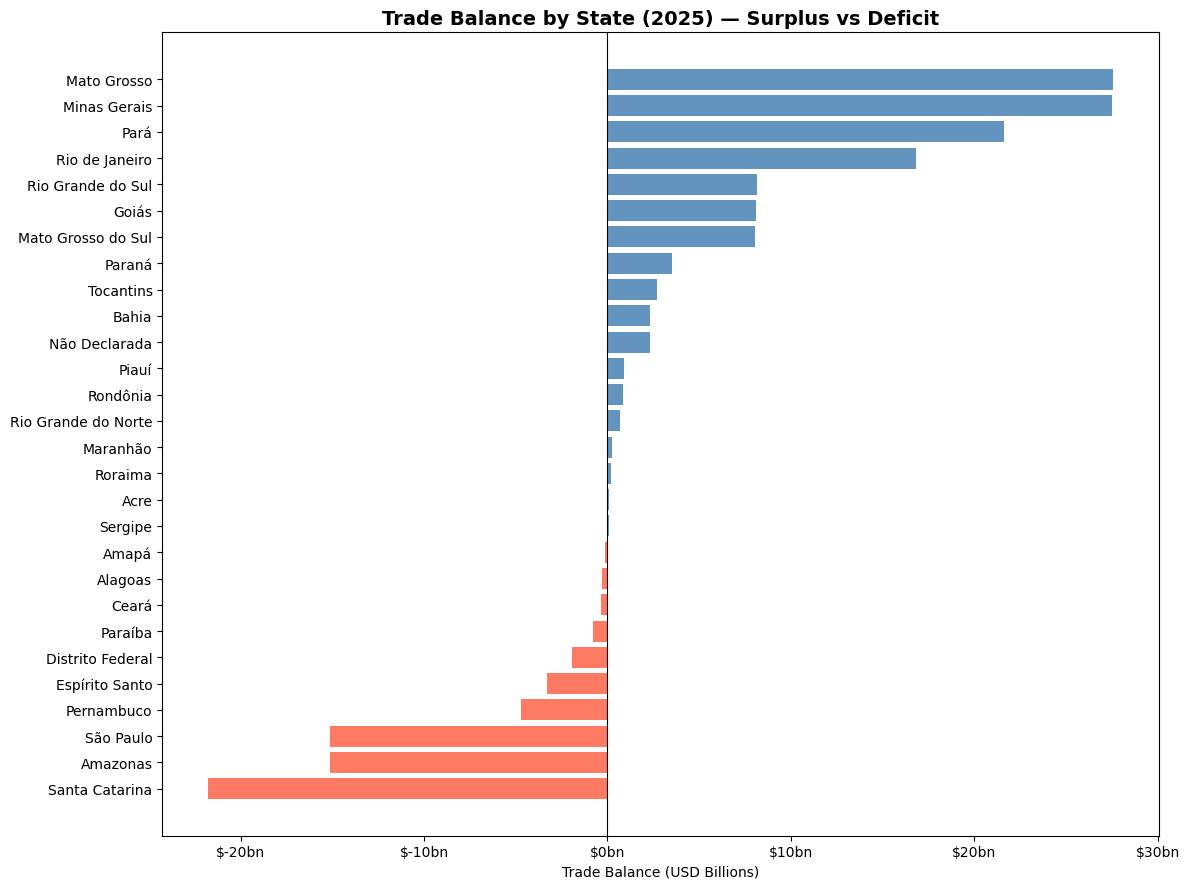


Net Exporting States (2025)



State,Region,Trade Balance (USD bn)
Mato Grosso,Center-West,+$27.57bn
Minas Gerais,Southeast,+$27.50bn
Pará,North,+$21.59bn
Rio de Janeiro,Southeast,+$16.80bn
Rio Grande do Sul,South,+$8.15bn
Goiás,Center-West,+$8.11bn
Mato Grosso do Sul,Center-West,+$8.04bn
Paraná,South,+$3.50bn
Tocantins,North,+$2.70bn
Bahia,Northeast,+$2.32bn



Net Importing States (2025)



State,Region,Trade Balance (USD bn)
Santa Catarina,South,-$21.80bn
Amazonas,North,-$15.13bn
São Paulo,Southeast,-$15.11bn
Pernambuco,Northeast,-$4.70bn
Espírito Santo,Southeast,-$3.30bn
Distrito Federal,Center-West,-$1.94bn
Paraíba,Northeast,-$0.81bn
Ceará,Northeast,-$0.34bn
Alagoas,Northeast,-$0.30bn
Amapá,North,-$0.14bn


In [106]:
## Uses df_state from 2.1
df_balance = (
    df_state[
        (df_state['state'] != 'Exterior')  # remove unwanted category
    ][['state', 'uf', 'region', 'balance_usd_bn']]
    .sort_values('balance_usd_bn')
)
colors = ['tomato' if x < 0 else 'steelblue' for x in df_balance['balance_usd_bn']]

fig, ax = plt.subplots(figsize=(12, 9))
ax.barh(df_balance['state'], df_balance['balance_usd_bn'], color=colors, alpha=0.85)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title(f"Trade Balance by State ({MAX_YEAR}) — Surplus vs Deficit", fontsize=14, fontweight='bold')
ax.set_xlabel("Trade Balance (USD Billions)")
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0fbn'))
plt.tight_layout()
plt.savefig('output_2_3_state_balance.png', dpi=150)
plt.show()

surplus_states = df_balance[df_balance['balance_usd_bn'] > 0].sort_values('balance_usd_bn', ascending=False)
deficit_states = df_balance[df_balance['balance_usd_bn'] < 0].sort_values('balance_usd_bn')

def format_balance(x):
    return f'+${x:.2f}bn' if x > 0 else f'-${abs(x):.2f}bn'

surplus_states = df_balance[df_balance['balance_usd_bn'] > 0].sort_values('balance_usd_bn', ascending=False).copy()
deficit_states = df_balance[df_balance['balance_usd_bn'] < 0].sort_values('balance_usd_bn').copy()

for df, label in [
    (surplus_states, f'Net Exporting States ({MAX_YEAR})'),
    (deficit_states, f'Net Importing States ({MAX_YEAR})'),
]:
    df_disp = (
        df[['state', 'region', 'balance_usd_bn']]
        .copy()
        .rename(columns={
            'state'          : 'State',
            'region'         : 'Region',
            'balance_usd_bn' : 'Trade Balance (USD bn)',
        })
    )
    df_disp['Trade Balance (USD bn)'] = df_disp['Trade Balance (USD bn)'].apply(format_balance)

    print(f'\n{label}\n')
    display(
        df_disp.style
        .set_caption(label)
        .set_properties(**{'text-align': 'left'})
        .hide(axis='index')
    )

#### Overview

**18 states run surpluses, 10 run deficits.** The surplus states are predominantly commodity exporters from Centro-Oeste, Norte and Nordeste (elaborated in 2b). The deficit states are predominantly industrial, administrative or import-dependent economies from Sul, Sudeste and Nordeste.

##### Surplus States

The top four surpluses — Mato Grosso (+\\$27.57bn), Minas Gerais (+\\$27.50bn), Pará (+\\$21.59bn) and Rio de Janeiro (+\\$16.80bn) — together account for the bulk of Brazil's national trade surplus. All four are commodity-driven: soybeans, iron ore, iron ore and oil respectively (as seen in 2b.1 and 2b.7).

The Centro-Oeste — Mato Grosso, Mato Grosso do Sul and Goiás all run surpluses, confirming the region's role as a net contributor to Brazil's export balance. None of the three has meaningful import volumes relative to its export scale.

##### Deficit States

**Santa Catarina (-\\$21.80bn)** is the largest deficit state and the most structurally anomalous. Its deficit exceeds its entire export value (\\$12.20bn), implying it imports nearly three times what it exports. Further investigation is required to evaluate if it is functioning as a regional import hub rather than simply a net importer. What drives \\$33.99bn in imports into a state with \\$12.20bn in exports requires product-level investigation in Step 4.

**Amazonas (-\\$15.13bn) and São Paulo (-\\$15.11bn)** are almost identical in deficit magnitude despite structurally distinct trade profiles.
  - São Paulo's deficit reflects its import base of capital goods (\\$15.72bn), electrical equipment (\$10.66bn), chemicals and pharmaceuticals — inputs consistent with a diversified industrial economy.
  - Amazonas's deficit is driven by electrical equipment imports alone (\\$7.06bn, 44.0% of total imports) against an export base of \\$0.94bn — a concentration and scale imbalance examined further in Section 2.14.1.

**Distrito Federal (-\\$1.94bn)** runs a deficit as expected — it is an administrative capital with minimal productive export base and imports goods for government and consumption purposes.

##### Regional Balance Pattern

| Region | Net position | Key driver |
|---|---|---|
| Centro-Oeste | Strongly positive | Agricultural commodity surpluses |
| Norte | Mixed — large surpluses (Pará) offset by Amazonas deficit | Mineral extraction vs Zona Franca |
| Sul | Mixed — Paraná and RS surplus offset by SC deficit | SC deficit anomaly |
| Sudeste | Mixed — MG and RJ surplus offset by SP deficit | Commodity surplus vs industrial deficit |
| Nordeste | Predominantly balanced considering small values | Small agricultural surpluses dominate |

> ⚠️ *Santa Catarina is the most analytically unresolved state in Step 2. Its \\$33.99bn import base against a \\$12.20bn export base produces a −\\$21.80bn deficit — the largest state trade deficit in the dataset, a coverage ratio of 0.36x, and the sole driver of the South region's −\\$10.15bn regional deficit. The import composition at SH2 level (machinery, electrical equipment, plastics, iron and steel, copper) is consistent with a manufacturing economy but does not explain the scale of the deficit. Whether the import volume reflects domestic industrial consumption, transshipment activity, or both cannot be determined from SH2-level data alone. NCM-level import analysis is required before any structural conclusion can be drawn. Deferred to future steps.*

---
---

### 2.1.3 — Trade Balance by State:  Which States Were Most Resilient?

Comparing state-level trade balances across the key periods identified in Step 1 (1997, 2009, 2014, 2020, 2025) — showing which states drove Brazil's national trade deficit during the 2014 recession and which demonstrated the greatest resilience across all three shock periods (2009 global recession, 2014 domestic recession, 2020 COVID).

Only the 12 largest export states by 2025 export value are included, representing states with sufficient export scale to meaningfully influence Brazil's national trade position. Smaller states are excluded as their individual contribution to aggregate dynamics is negligible.

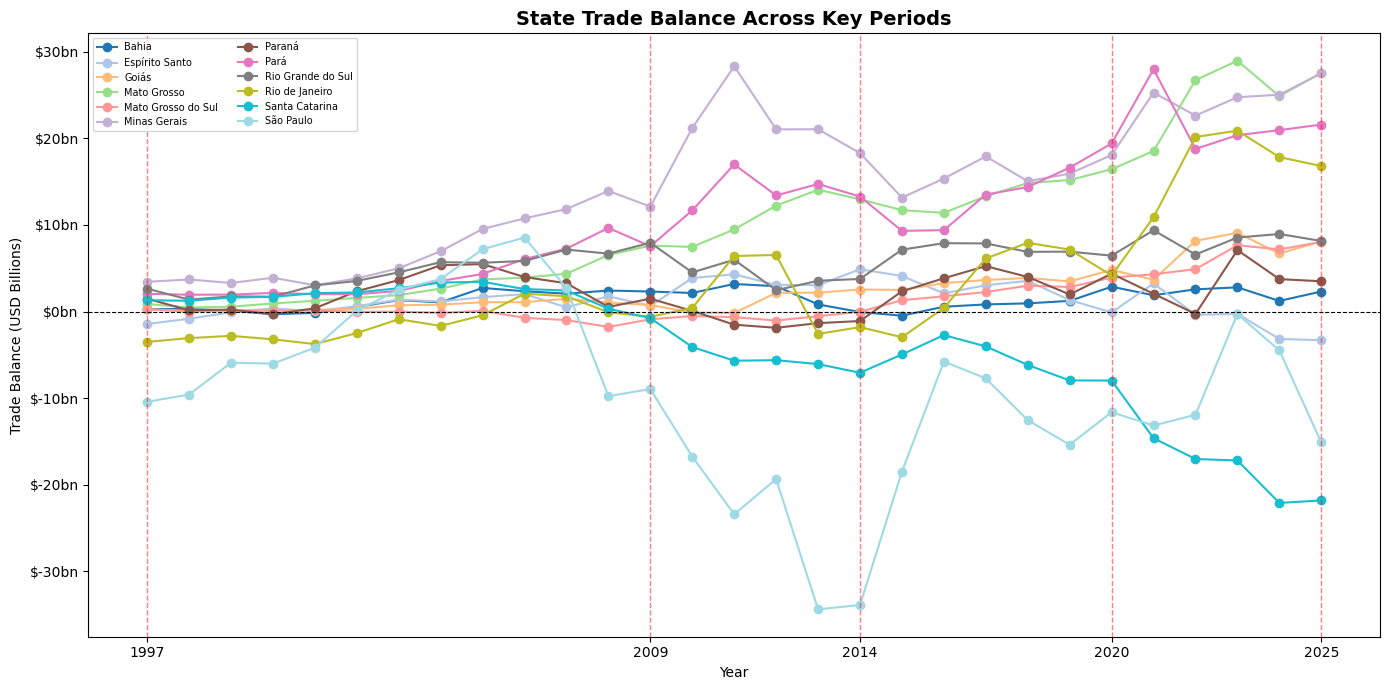


State trade balance across all years (USD bn):


C:\Users\e_koh\AppData\Local\Temp\ipykernel_27852\898191218.py:111: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(color_balance, subset=df_display.columns[1:])


State,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
Acre,$-0.0,$-0.0,$0.0,$-0.0,$0.0,$0.0,$0.0,$0.0,$0.0,$0.0,$0.0,$0.0,$0.0,$0.0,$0.0,$0.0,$0.0,$-0.0,$0.0,$0.0,$0.0,$0.0,$0.0,$0.0,$0.1,$0.1,$0.0,$0.1,$0.1
Alagoas,$0.2,$0.2,$0.2,$0.2,$0.2,$0.2,$0.3,$0.4,$0.5,$0.6,$0.4,$0.7,$0.7,$0.7,$0.9,$0.6,$0.2,$0.0,$0.1,$-0.2,$0.1,$-0.1,$-0.3,$-0.2,$-0.3,$-0.2,$0.2,$0.0,$-0.3
Amapá,$0.0,$0.1,$0.0,$0.0,$0.0,$0.0,$0.0,$0.0,$0.1,$0.1,$0.1,$0.1,$0.1,$0.3,$0.5,$0.3,$0.3,$0.3,$0.2,$0.2,$0.2,$0.1,$0.1,$0.1,$-0.1,$-0.6,$-1.0,$-0.4,$-0.1
Amazonas,$-4.0,$-2.7,$-2.4,$-3.1,$-2.4,$-2.0,$-2.1,$-3.1,$-3.0,$-4.7,$-5.8,$-8.9,$-6.2,$-10.0,$-11.8,$-12.5,$-13.3,$-12.2,$-8.2,$-5.7,$-8.0,$-9.3,$-9.4,$-8.9,$-12.4,$-13.3,$-11.7,$-15.2,$-15.1
Bahia,$0.3,$0.3,$0.1,$-0.3,$-0.1,$0.5,$1.3,$1.1,$2.7,$2.4,$2.1,$2.4,$2.3,$2.1,$3.2,$2.9,$0.8,$-0.1,$-0.5,$0.6,$0.8,$0.9,$1.2,$2.9,$1.9,$2.6,$2.8,$1.2,$2.3
Ceará,$-0.3,$-0.3,$-0.2,$-0.2,$-0.1,$-0.1,$0.2,$0.3,$0.3,$-0.1,$-0.3,$-0.3,$-0.1,$-0.9,$-1.0,$-1.6,$-1.9,$-1.5,$-1.6,$-2.2,$-0.1,$-0.2,$-0.1,$-0.6,$-1.1,$-2.6,$-1.1,$-1.6,$-0.3
Distrito Federal,$-0.3,$-0.4,$-0.7,$-0.5,$-0.6,$-0.6,$-0.5,$-0.5,$-0.7,$-0.8,$-1.1,$-0.9,$-1.0,$-1.4,$-1.1,$-0.9,$-1.1,$-0.9,$-0.9,$-1.3,$-0.8,$-0.7,$-0.9,$-1.2,$-3.3,$-2.0,$-1.8,$-1.3,$-1.9
Espírito Santo,$-1.4,$-0.8,$-0.1,$0.4,$0.0,$0.6,$1.4,$1.2,$1.7,$2.0,$0.5,$1.8,$0.7,$3.9,$4.3,$3.1,$3.0,$4.9,$4.1,$2.1,$3.0,$3.5,$1.3,$-0.1,$3.2,$-0.4,$-0.3,$-3.2,$-3.3
Goiás,$0.2,$0.1,$0.0,$0.2,$0.2,$0.3,$0.7,$0.8,$1.1,$1.1,$1.5,$1.0,$0.8,$-0.1,$-0.2,$2.2,$2.2,$2.5,$2.5,$3.3,$3.6,$3.9,$3.5,$4.8,$3.7,$8.2,$9.1,$6.7,$8.1
Maranhão,$0.3,$0.3,$0.3,$0.3,$-0.3,$-0.2,$0.1,$0.5,$0.3,$-0.0,$-0.2,$-1.3,$-0.8,$-0.9,$-3.2,$-4.0,$-4.5,$-4.3,$-0.6,$0.1,$0.5,$0.7,$-0.0,$1.4,$0.2,$-1.8,$0.6,$1.6,$0.3


In [107]:
## Key periods from Step 1 analysis
key_years = [1997, 2009, 2014, 2020, MAX_YEAR]
key_years_2 = list(range(1997, MAX_YEAR + 1))

query_balance_periods = f"""
    SELECT year, uf, state,
           COALESCE(MAX(exports_usd), 0) - COALESCE(MAX(imports_usd), 0) AS balance_usd
    FROM (
        SELECT e."CO_ANO" AS year,
               u.sigla AS uf,
               u.nome_estado AS state,
               SUM(e."VL_FOB") AS exports_usd,
               NULL::numeric AS imports_usd
        FROM exp e
        JOIN uf u ON e."SG_UF_NCM" = u.sigla
        WHERE e."CO_ANO" IN ({','.join(map(str, key_years_2))})
        GROUP BY e."CO_ANO", u.sigla, u.nome_estado
        UNION ALL
        SELECT i."CO_ANO" AS year,
               u.sigla AS uf,
               u.nome_estado AS state,
               NULL::numeric AS exports_usd,
               SUM(i."VL_FOB") AS imports_usd
        FROM imp i
        JOIN uf u ON i."SG_UF_NCM" = u.sigla
        WHERE i."CO_ANO" IN ({','.join(map(str, key_years_2))})
        GROUP BY i."CO_ANO", u.sigla, u.nome_estado
    ) t
    GROUP BY year, uf, state
"""

df_periods = pd.read_sql(query_balance_periods, engine)
df_periods['balance_usd_bn'] = (df_periods['balance_usd'] / 1e9).round(2)

## Pivot: rows = states, columns = years
df_periods_pivot = df_periods.pivot(index='state', columns='year', values='balance_usd_bn').fillna(0)

## Focus on top 15 states by absolute balance in MAX_YEAR
top15_balance = df_state.nlargest(12, 'exports_usd_bn')['state'].tolist()
df_periods_plot = df_periods_pivot.loc[df_periods_pivot.index.isin(top15_balance)]

# Creating second layer to create a table
all_balance = df_state[df_state['state'] != 'Não Declarada'].nlargest(27, 'exports_usd_bn')['state'].tolist()
df_all_periods_plot = df_periods_pivot.loc[df_periods_pivot.index.isin(all_balance)]

fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(key_years))

# Add distinct colors using tab20 colormap
colors = plt.cm.tab20(np.linspace(0, 1, len(df_periods_plot.index)))

for i, state in enumerate(df_periods_plot.index):
    ax.plot(
        key_years_2,
        df_periods_plot.loc[state],
        marker='o',
        label=state,
        linewidth=1.5,
        color=colors[i]  # <-- key addition
    )

ax.axhline(y=0, color='black', linewidth=0.8, linestyle='--')

# Add vertical lines for key years
for year in key_years:
    ax.axvline(
        x=year,
        linestyle='--',
        linewidth=1,
        color='red',
        alpha=0.5
    )
    
# Titles and labels
ax.set_title("State Trade Balance Across Key Periods", fontsize=14, fontweight='bold')
ax.set_xlabel("Year")
ax.set_ylabel("Trade Balance (USD Billions)")
ax.set_xticks(key_years)
ax.legend(loc='upper left', fontsize=7, ncol=2)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0fbn'))

plt.tight_layout()
plt.savefig('output_2_4_state_balance_periods.png', dpi=150)
plt.show()


## _______________________Table_________________________________________________________________
df_display = df_all_periods_plot.copy().reset_index()
df_display.columns = ['State'] + [str(col) for col in df_display.columns[1:]]

# Defining the function
def color_balance(val):
    if pd.isna(val):
        return 'color: gray'
    return 'color: #2e7d32' if val >= 0 else 'color: #c62828'

styled = (
    df_display.style
    .set_properties(**{
        'font-size': '11px',
        'text-align': 'right',
        'padding': '4px 8px',
        'white-space': 'nowrap',
    })
    .set_properties(subset=['State'], **{
        'text-align': 'left',
        'font-weight': 'bold'
    })
    .format(lambda x: f'${x:.1f}' if isinstance(x, (int, float)) else x)
    # APPLY COLORING
    .applymap(color_balance, subset=df_display.columns[1:])
    .set_table_styles([
        {'selector': 'thead th', 'props': [
            ('background-color', '#f5f5f5'),
            ('font-size', '10px'),
            ('font-weight', 'bold'),
            ('text-align', 'center'),
            ('padding', '6px 8px'),
            ('border-bottom', '2px solid #ddd'),
        ]},
        {'selector': 'tbody tr:nth-child(even)', 'props': [
            ('background-color', '#fafafa'),
        ]},
        {'selector': 'tbody tr:hover', 'props': [
            ('background-color', '#f0f4ff'),
        ]},
        {'selector': 'td, th', 'props': [
            ('border-bottom', '1px solid #eee'),
        ]},
        {'selector': 'table', 'props': [
            ('border-collapse', 'collapse'),
            ('font-family', 'monospace'),
        ]},
    ])
    .hide(axis='index')
)

print(f"\nState trade balance across all years (USD bn):")
display(styled)

#### Overview

Across 1997–2025, three structural patterns emerge: states that expanded surpluses across all three shock periods; states whose balances swung with commodity price cycles; and states whose import dependency deepened regardless of the economic cycle. 

The 2009 global recession, 2014 domestic recession, and 2020 COVID shock produced temporary moderation rather than structural reversals in the majority of states. Espírito Santo and Paraná are the two exceptions where the post-2014 trajectory did not recover.

---

#### States That Strengthened Consistently

**Mato Grosso** expanded its surplus from \\$0.88bn (1997) to \\$27.57bn (2025) without a single period of contraction across all three shock periods.

**Pará** moved from \\$2.05bn (1997) to \\$21.59bn (2025) with only minor moderation at each of the three shocks.

**Rio Grande do Sul** recorded no deficit years across either reference point or any shock period, growing from \\$2.65bn (1997) to \\$8.15bn (2025).

---

#### States With Reversals

**Minas Gerais** peaked at \\$28.32bn (2011), fell to \\$18.30bn (2014), held at \\$18.07bn through COVID, and recovered to \\$27.50bn (2025).

**Rio de Janeiro** moved from -\\$3.50bn (1997) to +\\$16.80bn (2025). In 1997 it was a net importer; by 2025 it is among Brazil's largest surplus states.

**Espírito Santo** reversed from +\\$4.89bn (2014) to -\\$3.30bn (2025) — an \\$8.19bn swing in eleven years with no recovery across subsequent years.

> ⚠️ Espírito Santo's reversal mechanism is unconfirmed. Future steps will determine whether iron ore import volumes are the primary driver.

**Paraná** moved from -\\$1.93bn (2012) to +\\$3.50bn (2025), though the recovery path is not monotonic.

> ⚠️ Drivers of Paraná's recovery are unidentified. Step 3 (trade balances and competitiveness analysis) will investigate whether product mix change, new export markets, or logistics improvements explain the shift.

---

#### Persistent Deficit States

**São Paulo** peaked at -\\$33.88bn (2014) before recovering to -\\$15.11bn (2025). The near-balance of -\\$0.30bn in 2023 is the closest São Paulo has come to balance outside the 2002–2007 window. São Paulo will remain a structural deficit state; its industrial economy requires imported inputs that cannot be substituted domestically.

**Santa Catarina** moved from +\\$1.31bn (1997) to -\\$21.80bn (2025) — a \\$23.11bn deterioration and the largest absolute deterioration of any state in the dataset. The worsening is present across both reference points and all three shock periods including COVID.

---

#### The Center-West Transformation

The three Center-West states reached a combined surplus of \\$43.72bn in 2025, up from \\$1.38bn in 1997. As established in Section 2.12 (commodity vs processed product composition), Center-West exports are overwhelmingly classified as primary commodities — raw agricultural goods, principally soybeans and beef, with minimal processing before export. The surplus expansion reflects volume and price growth in raw commodity exports, not a shift toward higher value-added production.

| State                  | 1997         | 2025          | Change        |
|------------------------|--------------|---------------|---------------|
| Mato Grosso            | +\\$0.88bn     | +\\$27.57bn     | +\\$26.69bn     |
| Goiás                  | +\\$0.25bn     | +\\$8.11bn      | +\\$7.86bn      |
| Mato Grosso do Sul     | +\\$0.25bn     | +\\$8.04bn      | +\\$7.79bn      |
| **Center-West Total**  | **+\\$1.38bn** | **+\\$43.72bn** | **+\\$42.34bn** |

> ⚠️ Step 4 (product-level export analysis by state) will confirm the specific commodity composition driving each state's surplus expansion.

---
---

## 2.2 — State Export Growth Dynamics: Which States Are Rising and Falling?
Tracking the top 8 exporting states from 1997 to 2025 — identifying fast-growing emerging exporters, states in structural decline, and how key economic events impacted different states differently.

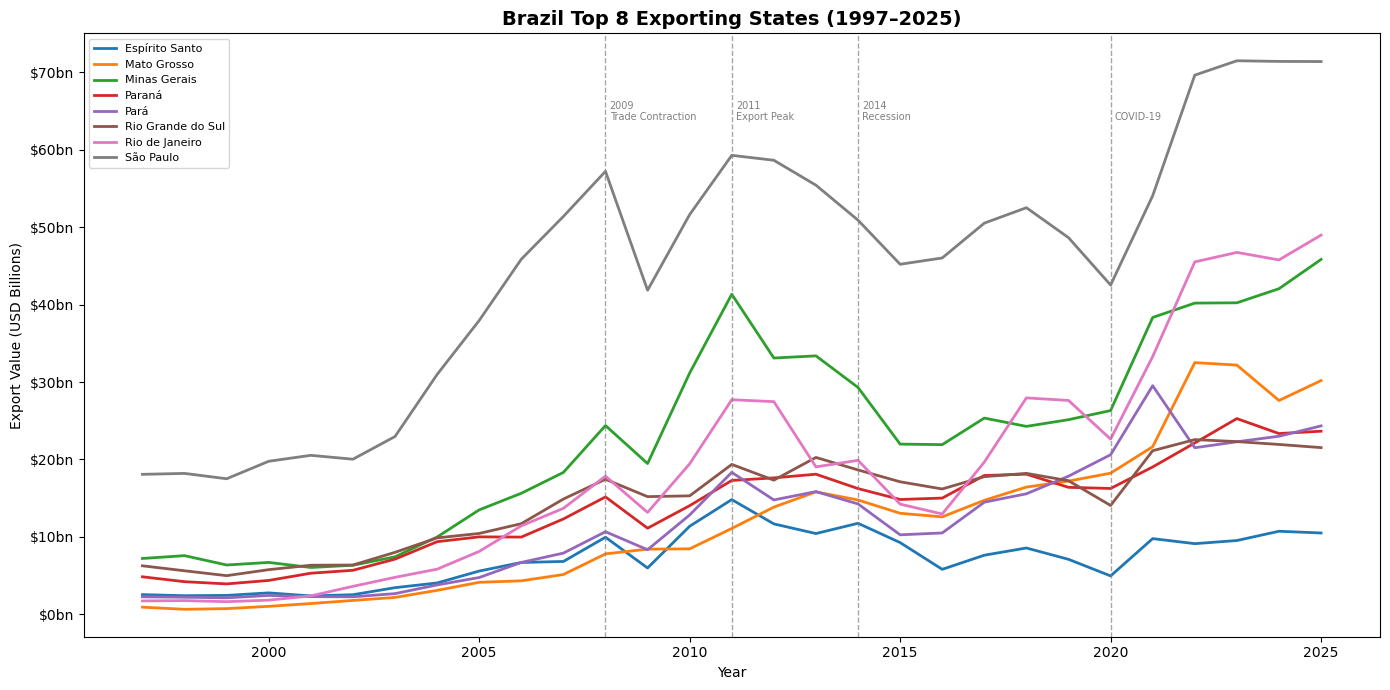

State Export Growth Summary — 1997 to 2025


C:\Users\e_koh\AppData\Local\Temp\ipykernel_27852\3557282519.py:95: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.loc[x['exports_usd_bn'].idxmax(), ['year', 'exports_usd_bn']])
C:\Users\e_koh\AppData\Local\Temp\ipykernel_27852\3557282519.py:185: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(color_pct, subset=pct_cols)


#,State,Region,Exports 1997 (USD bn),Exports 2025 (USD bn),Total Growth 1997–2025 (%),CAGR 1997–2025 (%),CAGR 2020–2025 — Last 5Y (%),YoY Growth 2024–2025 (%),Peak Year,Peak Exports (USD bn)
1,São Paulo,Southeast,$18.08,$71.39,+294.9%,+5.0%,+10.9%,-0.0%,2023,$71.49
2,Rio de Janeiro,Southeast,$1.73,$48.98,+2728.1%,+12.7%,+16.7%,+7.0%,2025,$48.98
3,Minas Gerais,Southeast,$7.22,$45.83,+535.0%,+6.8%,+11.7%,+9.0%,2025,$45.83
4,Mato Grosso,Center-West,$0.93,$30.19,+3157.0%,+13.2%,+10.6%,+9.3%,2022,$32.51
5,Pará,North,$2.26,$24.34,+975.2%,+8.9%,+3.4%,+5.8%,2021,$29.53
6,Paraná,South,$4.85,$23.65,+387.7%,+5.8%,+7.8%,+1.3%,2023,$25.28
7,Rio Grande do Sul,South,$6.27,$21.53,+243.5%,+4.5%,+8.9%,-1.9%,2022,$22.56
8,Goiás,Center-West,$0.48,$13.47,+2733.3%,+12.7%,+10.6%,+9.4%,2022,$14.15
9,Santa Catarina,South,$2.80,$12.20,+335.3%,+5.4%,+8.5%,+4.4%,2025,$12.20
10,Bahia,Northeast,$1.87,$11.63,+523.1%,+6.8%,+8.2%,-2.3%,2022,$13.92


In [108]:
query_state_time = f"""
    SELECT e."CO_ANO" AS year,
           u.nome_estado AS state,
           SUM(e."VL_FOB") AS exports_usd
    FROM exp e
    JOIN uf u ON e."SG_UF_NCM" = u.sigla
    WHERE e."CO_ANO" <= {MAX_YEAR}
    GROUP BY e."CO_ANO", u.nome_estado
    ORDER BY e."CO_ANO", exports_usd DESC
"""

df_state_time = pd.read_sql(query_state_time, engine)
df_state_time['exports_usd_bn'] = df_state_time['exports_usd'] / 1e9

top8_states = (
    df_state_time.groupby('state')['exports_usd']
    .sum().nlargest(8).index.tolist()
)

df_top8 = df_state_time[df_state_time['state'].isin(top8_states)]
df_pivot = df_top8.pivot(index='year', columns='state', values='exports_usd_bn').fillna(0)

## Annotate key periods identified in Step 1
events = {
    2009: ('2009\nTrade Contraction', 2008),
    2011: ('2011\nExport Peak',       2011),
    2014: ('2014\nRecession',         2014.0),
    2020: ('COVID-19',                2020)
}

fig, ax = plt.subplots(figsize=(14, 7))
for state in df_pivot.columns:
    ax.plot(df_pivot.index, df_pivot[state], label=state, linewidth=2)
for year, (label, xpos) in events.items():
    ax.axvline(x=xpos, color='gray', linestyle='--', linewidth=1, alpha=0.7)
    ax.text(xpos + 0.1, ax.get_ylim()[1] * 0.85, label, fontsize=7, color='gray')

ax.set_title(f"Brazil Top 8 Exporting States (1997–{MAX_YEAR})", fontsize=14, fontweight='bold')
ax.set_xlabel("Year")
ax.set_ylabel("Export Value (USD Billions)")
ax.legend(loc='upper left', fontsize=8)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0fbn'))
plt.tight_layout()
plt.savefig('output_2_2_state_exports_time.png', dpi=150)
plt.show()

## ── Growth summary table ─────────────────────────────────────────────────────
region_map = (
    df_state[['state', 'region']]
    .drop_duplicates()
    .assign(region=lambda d: d['region'].map({
        'REGIAO NORDESTE'     : 'Northeast',
        'REGIAO NORTE'        : 'North',
        'REGIAO SUDESTE'      : 'Southeast',
        'REGIAO CENTRO OESTE' : 'Center-West',
        'REGIAO SUL'          : 'South',
        'REGIAO NAO DECLARADA': 'Undeclared'
    }).fillna(d['region']))
)

exclude_states = [
    'Não Declarada', 'Exterior',
    'Consumo de Bordo', 'Mercadoria Nacionalizada',
    'Reexportação', 'Zona Não Declarada'
]
df_growth = df_state_time[~df_state_time['state'].isin(exclude_states)].copy()

val_1997 = (
    df_growth[df_growth['year'] == 1997]
    .set_index('state')['exports_usd_bn']
    .rename('val_1997')
)
val_2025 = (
    df_growth[df_growth['year'] == MAX_YEAR]
    .set_index('state')['exports_usd_bn']
    .rename('val_2025')
)
val_prev = (
    df_growth[df_growth['year'] == MAX_YEAR - 1]
    .set_index('state')['exports_usd_bn']
    .rename('val_prev')
)
val_2020 = (
    df_growth[df_growth['year'] == MAX_YEAR - 5]
    .set_index('state')['exports_usd_bn']
    .rename('val_2020')
)

yoy_growth = (
    (val_2025 / val_prev.reindex(val_2025.index).replace(0, float('nan'))) - 1
) * 100

peak = (
    df_growth.groupby('state')
    .apply(lambda x: x.loc[x['exports_usd_bn'].idxmax(), ['year', 'exports_usd_bn']])
    .rename(columns={'year': 'peak_year', 'exports_usd_bn': 'peak_val_usd_bn'})
)

n_full   = MAX_YEAR - 1997
n_recent = 5

cagr_full = (
    (val_2025 / val_1997.reindex(val_2025.index).replace(0, float('nan'))) ** (1 / n_full) - 1
) * 100

cagr_recent = (
    (val_2025 / val_2020.reindex(val_2025.index).replace(0, float('nan'))) ** (1 / n_recent) - 1
) * 100

total_growth = (
    (val_2025 / val_1997.reindex(val_2025.index).replace(0, float('nan'))) - 1
) * 100

df_summary = pd.DataFrame({
    'exports_1997_usd_bn'       : val_1997,
    'exports_2025_usd_bn'       : val_2025,
    'total_growth_1997_2025_pct': total_growth,
    'cagr_1997_2025_pct'        : cagr_full,
    'cagr_2020_2025_pct'        : cagr_recent,
    'yoy_growth_2024_2025_pct'  : yoy_growth,
    'peak_year'                 : peak['peak_year'],
    'peak_exports_usd_bn'       : peak['peak_val_usd_bn'],
}).reset_index().rename(columns={'index': 'state'})

df_summary = df_summary.merge(region_map, on='state', how='left')
df_summary = df_summary.sort_values('exports_2025_usd_bn', ascending=False).reset_index(drop=True)
df_summary.insert(0, 'rank_2025', df_summary.index + 1)

for col in ['exports_1997_usd_bn', 'exports_2025_usd_bn', 'peak_exports_usd_bn']:
    df_summary[col] = df_summary[col].round(2)
for col in ['total_growth_1997_2025_pct', 'cagr_1997_2025_pct',
            'cagr_2020_2025_pct', 'yoy_growth_2024_2025_pct']:
    df_summary[col] = df_summary[col].round(1)
df_summary['peak_year'] = df_summary['peak_year'].astype('Int64')

## ── Styled display ───────────────────────────────────────────────────────────
df_display = df_summary[[
    'rank_2025', 'state', 'region',
    'exports_1997_usd_bn', 'exports_2025_usd_bn',
    'total_growth_1997_2025_pct',
    'cagr_1997_2025_pct',
    'cagr_2020_2025_pct',
    'yoy_growth_2024_2025_pct',
    'peak_year', 'peak_exports_usd_bn'
]].copy()

df_display.columns = [
    '#', 'State', 'Region',
    'Exports 1997 (USD bn)', 'Exports 2025 (USD bn)',
    'Total Growth 1997–2025 (%)',
    'CAGR 1997–2025 (%)',
    'CAGR 2020–2025 — Last 5Y (%)',
    'YoY Growth 2024–2025 (%)',
    'Peak Year', 'Peak Exports (USD bn)'
]

pct_cols = [
    'Total Growth 1997–2025 (%)',
    'CAGR 1997–2025 (%)',
    'CAGR 2020–2025 — Last 5Y (%)',
    'YoY Growth 2024–2025 (%)'
]

def color_pct(val):
    if pd.isna(val):
        return 'color: gray'
    return 'color: #2e7d32' if val >= 0 else 'color: #c62828'

styled = (
    df_display.style
    .set_properties(**{
        'font-size' : '12px',
        'text-align': 'right',
        'padding'   : '4px 10px',
        'white-space': 'nowrap',
    })
    .set_properties(subset=['State', 'Region'], **{
        'text-align': 'left',
    })
    .set_properties(subset=['#'], **{
        'text-align': 'center',
        'color'     : 'gray',
        'font-size' : '11px',
    })
    .applymap(color_pct, subset=pct_cols)
    .format({
        'Exports 1997 (USD bn)'          : lambda x: f'${x:.2f}' if pd.notna(x) else '—',
        'Exports 2025 (USD bn)'          : lambda x: f'${x:.2f}' if pd.notna(x) else '—',
        'Peak Exports (USD bn)'          : lambda x: f'${x:.2f}' if pd.notna(x) else '—',
        'Total Growth 1997–2025 (%)'     : lambda x: f'{x:+.1f}%' if pd.notna(x) else '—',
        'CAGR 1997–2025 (%)'             : lambda x: f'{x:+.1f}%' if pd.notna(x) else '—',
        'CAGR 2020–2025 — Last 5Y (%)'  : lambda x: f'{x:+.1f}%' if pd.notna(x) else '—',
        'YoY Growth 2024–2025 (%)'       : lambda x: f'{x:+.1f}%' if pd.notna(x) else '—',
        'Peak Year'                      : lambda x: str(int(x)) if pd.notna(x) else '—',
    })
    .set_table_styles([
        {'selector': 'thead th', 'props': [
            ('background-color', '#f5f5f5'),
            ('font-size', '11px'),
            ('font-weight', 'bold'),
            ('text-align', 'center'),
            ('padding', '6px 10px'),
            ('border-bottom', '2px solid #ddd'),
            ('white-space', 'nowrap'),
        ]},
        {'selector': 'tbody tr:nth-child(even)', 'props': [
            ('background-color', '#fafafa'),
        ]},
        {'selector': 'tbody tr:hover', 'props': [
            ('background-color', '#f0f4ff'),
        ]},
        {'selector': 'td, th', 'props': [
            ('border-bottom', '1px solid #eee'),
        ]},
        {'selector': 'table', 'props': [
            ('border-collapse', 'collapse'),
            ('width', '100%'),
            ('font-family', 'monospace'),
        ]},
    ])
    .hide(axis='index')
)

print(f"State Export Growth Summary — 1997 to {MAX_YEAR}")
display(styled)

### Overview

**São Paulo (\\$18.08bn → \\$71.39bn, CAGR +5.0%)** has been the dominant exporter throughout the period. Growth has been consistent rather than cycle-driven — the post-2020 trajectory is steeper than any prior period. The last 5Y CAGR of +10.9% is materially above the full-period CAGR, confirming this acceleration. The near-zero YoY figure for 2024–2025 suggests a recent slowdown in growth.

**Rio de Janeiro (\\$1.73bn → \\$48.98bn, CAGR +12.7%)** records the highest full-period CAGR among large exporters — a result of its near-zero 1997 base. Its peak year is 2025 and last 5Y CAGR of +16.7% confirms post-2020 growth is ongoing. Unlike Minas Gerais it did not show a pronounced peak around 2011.

**Minas Gerais (\\$7.22bn → \\$45.83bn, CAGR +6.8%)** shows a clear cyclical pattern — strong growth to 2011, followed by contraction through 2015–2016, and recovery to a new peak in 2025. The +11.7% last 5Y CAGR and +9.0% YoY indicate that this recovery is ongoing.

**Mato Grosso (\\$0.93bn → \\$30.19bn, CAGR +13.2%)** peaked at \\$32.51bn in 2022 before moderating to $30.19bn by 2025. The +10.6% last 5Y CAGR and +9.3% YoY indicate continued growth.

**Pará (\\$2.26bn → \\$24.34bn, CAGR +8.9%)** peaked in 2021 at \\$29.53bn — a \\$5bn gap to its 2025 value, the largest peak-to-current divergence among the top 10. Its trajectory shows moderate growth to 2011, contraction through 2014–2016, recovery post-2017, and lower values after 2021. The +3.4% last 5Y CAGR is the weakest among the top 10 states.

**The Southern states (Paraná +5.8%, Rio Grande do Sul +4.5%, Santa Catarina +5.4%)** have the three most similar full-period CAGRs of any region — a quantitative confirmation of the structural coherence identified in Step 2b. All three show last 5Y CAGRs materially above their full-period figures (+7.8%, +8.9%, +8.5% respectively), consistent with post-COVID recovery. Neither Paraná nor Rio Grande do Sul exhibit the pronounced peaks and contractions through 2014–2016, recovery post-2017, and lower values after 2021. Rio Grande do Sul's -1.9% YoY is the only negative figure in the Sul cluster and warrants monitoring.

**Espírito Santo (\\$2.55bn → \\$10.51bn, CAGR +5.2%)** peaked in 2011 at \\$14.82bn and remains below that level in 2025 — the only top-12 state still below its historical peak. The combination of a +16.2% last 5Y CAGR and -2.1% YoY indicates strong recent growth followed by a decline in the most recent year.

**Macroeconomic events are visible across all states simultaneously.** The 2014 recession produced a contraction or flattening across every state between 2013 and 2016 — confirming it was a national rather than state-specific event. The 2009 trade contraction is visible as a brief dip before rapid recovery. COVID-19 produced a noticeably smaller disruption than 2014 — consistent with the Step 1 finding that Brazil's goods trade was resilient during the pandemic.

**The small-state growth figures require context.** Tocantins (+22.8% CAGR), Acre (+24.7%) and Rondônia (+17.1%) record the highest CAGRs in the dataset — a direct result of near-zero 1997 bases. These are not analytically comparable to large-state CAGRs and should be read alongside absolute values (\\$3.05bn, \\$0.10bn and $3.09bn respectively).

**Ceará's +55.6% YoY is the most anomalous single-year figure in the table** — a rise from approximately \\$1.47bn in 2024 to \\$2.28bn in 2025. Sergipe’s +62.6% last 5Y CAGR is similarly high relative to its absolute value (\\$0.45bn). These changes cannot be explained using aggregate data at this level of analysis.


>*⚠️ Three figures warrant specific follow-up in Step 4: Ceará's +55.6% YoY, Sergipe's +62.6% last 5Y CAGR, and Pará's \\$5bn gap to its 2021 peak. All three cannot be resolved from aggregate trade flow data alone.*

---
---

## 2.3 — Regional Export and Import Distribution

### 2.3.1 — Regional Export Distribution: How Brazil's Five Macro-Regions Compare
Breaking down export value and share by Brazil's five macro-regions (Norte, Nordeste, Centro-Oeste, Sudeste, Sul) from 1997 to 2025 — showing which regions have gained or lost export share over 30 years

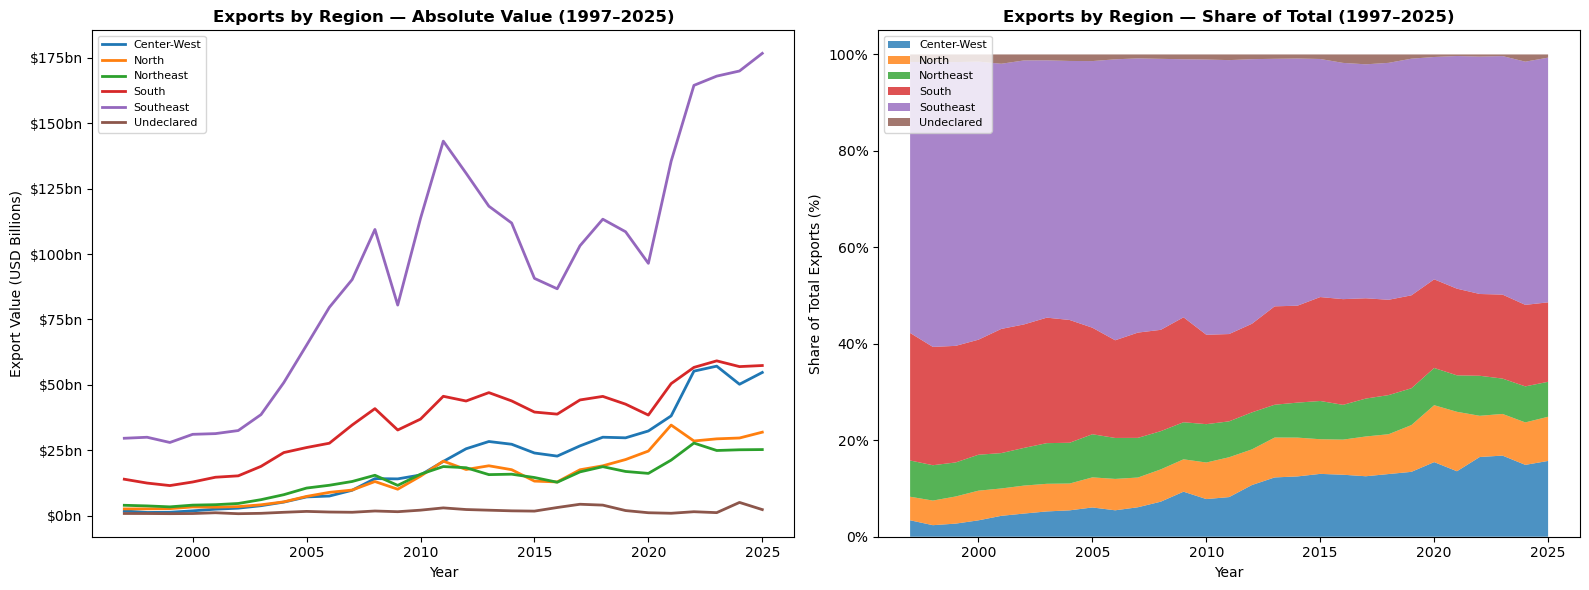


Regional Export Share — 1997 vs 2025



Region,1997 (%),1997 (USD bn),2025 (%),2025 (USD bn),Change (pp)
Southeast,56.2%,$29.58bn,50.7%,$176.71bn,-5.5pp
South,26.4%,$13.92bn,16.5%,$57.38bn,-10.0pp
Center-West,3.4%,$1.79bn,15.7%,$54.73bn,+12.3pp
North,4.9%,$2.57bn,9.2%,$31.90bn,+4.3pp
Northeast,7.5%,$3.96bn,7.3%,$25.25bn,-0.3pp
Undeclared,1.6%,$0.82bn,0.7%,$2.31bn,-0.9pp


In [109]:
query_region = f"""
    SELECT e."CO_ANO" AS year,
           u.nome_regiao AS region,
           SUM(e."VL_FOB") AS exports_usd
    FROM exp e
    JOIN uf u ON e."SG_UF_NCM" = u.sigla
    WHERE e."CO_ANO" <= {MAX_YEAR}
    GROUP BY e."CO_ANO", u.nome_regiao
    ORDER BY e."CO_ANO"
"""

# Mapping dictionary (Portuguese -> English)
region_map = {
    'REGIAO NORDESTE'     : 'Northeast',
    'REGIAO NORTE'        : 'North',
    'REGIAO SUDESTE'      : 'Southeast',
    'REGIAO CENTRO OESTE' : 'Center-West',
    'REGIAO SUL'          : 'South',
    'REGIAO NAO DECLARADA': 'Undeclared'
}

# Regions/categories to exclude
exclude_regions = [
    'Não Declarada',
    'Exterior',
    'CONSUMO DE BORDO',
    'MERCADORIA NACIONALIZADA',
    'REEXPORTACAO',
    'Zona Não Declarada'
]

df_region = pd.read_sql(query_region, engine)

# Remove unwanted categories BEFORE mapping/pivot
df_region = df_region[~df_region['region'].isin(exclude_regions)]

# Apply mapping
df_region['region'] = df_region['region'].map(region_map).fillna(df_region['region'])

df_region['exports_usd_bn'] = df_region['exports_usd'] / 1e9
df_region_pivot = df_region.pivot(index='year', columns='region', values='exports_usd_bn').fillna(0)
df_region_pct   = df_region_pivot.div(df_region_pivot.sum(axis=1), axis=0) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for region in df_region_pivot.columns:
    ax1.plot(df_region_pivot.index, df_region_pivot[region], label=region, linewidth=2)

ax1.set_title(f"Exports by Region — Absolute Value (1997–{MAX_YEAR})", fontsize=12, fontweight='bold')
ax1.set_xlabel("Year")
ax1.set_ylabel("Export Value (USD Billions)")
ax1.legend(fontsize=8)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0fbn'))

ax2.stackplot(
    df_region_pct.index,
    df_region_pct.T,
    labels=df_region_pct.columns,
    alpha=0.8
)

ax2.set_title(f"Exports by Region — Share of Total (1997–{MAX_YEAR})", fontsize=12, fontweight='bold')
ax2.set_xlabel("Year")
ax2.set_ylabel("Share of Total Exports (%)")
ax2.legend(loc='upper left', fontsize=8)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

plt.tight_layout()
plt.savefig('output_2_5_region_exports.png', dpi=150)
plt.show()

start_year = df_region_pct.index[0]

usd_start = df_region_pivot.loc[start_year].round(2)
usd_end   = df_region_pivot.loc[MAX_YEAR].round(2)

summary_region = pd.DataFrame({
    'Region'                 : df_region_pct.columns,
    f'{start_year} (%)'      : df_region_pct.loc[start_year].round(1).values,
    f'{start_year} (USD bn)' : usd_start.values,
    f'{MAX_YEAR} (%)'        : df_region_pct.loc[MAX_YEAR].round(1).values,
    f'{MAX_YEAR} (USD bn)'   : usd_end.values,
    'Change (pp)'            : (df_region_pct.loc[MAX_YEAR] - df_region_pct.loc[start_year]).round(1).values
})

summary_region = pd.DataFrame({
    'Region'                 : df_region_pct.columns,
    f'{start_year} (%)'      : df_region_pct.loc[start_year].round(1).values,
    f'{start_year} (USD bn)' : usd_start.values,
    f'{MAX_YEAR} (%)'        : df_region_pct.loc[MAX_YEAR].round(1).values,
    f'{MAX_YEAR} (USD bn)'   : usd_end.values,
    'Change (pp)'            : (df_region_pct.loc[MAX_YEAR] - df_region_pct.loc[start_year]).round(1).values
}).sort_values(f'{MAX_YEAR} (%)', ascending=False).copy()

summary_region[f'{start_year} (%)']      = summary_region[f'{start_year} (%)'].apply(lambda x: f'{x:.1f}%')
summary_region[f'{start_year} (USD bn)'] = summary_region[f'{start_year} (USD bn)'].apply(lambda x: f'${x:.2f}bn')
summary_region[f'{MAX_YEAR} (%)']        = summary_region[f'{MAX_YEAR} (%)'].apply(lambda x: f'{x:.1f}%')
summary_region[f'{MAX_YEAR} (USD bn)']   = summary_region[f'{MAX_YEAR} (USD bn)'].apply(lambda x: f'${x:.2f}bn')
summary_region['Change (pp)']            = summary_region['Change (pp)'].apply(lambda x: f'{x:+.1f}pp')

print(f"\nRegional Export Share — {start_year} vs {MAX_YEAR}\n")
display(
    summary_region.style
    .set_caption(f'Regional Export Share — {start_year} vs {MAX_YEAR}')
    .set_properties(**{'text-align': 'left'})
    .hide(axis='index')
)

#### Overview

In 1997, two regions accounted for 82.6% of Brazil's total exports: Southeast (\\$29.58bn, 56.2%) and South (\\$13.92bn, 26.4%). By 2025, that combined share had fallen to 67.2% (\\$234.09bn) — not because either region contracted in absolute terms, but because Center-West and North grew faster.


**Center-West (+12.3pp)** recorded the largest shift in the dataset — from \\$1.79bn (3.4%) to \\$54.73bn (15.7%) over 28 years. As established in Section 2.10, this expansion is driven by primary commodity exports with minimal processing before export. Product-level composition is confirmed in Step 4.

**South (-10.0pp)** recorded the largest decline — from \\$13.92bn (26.4%) to $57.38bn (16.5%). This is not a contraction in absolute export value but a relative one, as Center-West growth outpaced South's over the period.

**Southeast (-5.5pp)** remained the dominant export region at \\$176.71bn (50.7%) in 2025. The drivers of both its sustained dominance and its share decline are examined at product level in Step 4.

**North (+4.3pp)** grew from \\$2.57bn (4.9%) to \\$31.90bn (9.2%), consistent with the surplus expansion identified in Section 2.1.3. Product-level confirmation is deferred to Step 4.

**Northeast (-0.3pp)** was the most stable region — \\$3.96bn (7.5%) in 1997 to \\$25.25bn (7.3%) in 2025.

The structural implication is a geographic rebalancing of Brazilian export capacity toward the commodity interior. By 2025, Center-West and North combined account for 24.9% (\\$86.63bn) of national exports, up from 8.3% (\\$4.36bn) in 1997.

#### Non-Geographic Categories

Undeclared declined from 1.6% (\\$0.82bn) to 0.7% (\\$2.31bn), suggesting gradual improvement in state-level trade recording.

> ⚠️ *The South's -10.0pp share loss does not indicate an absolute export decline but reflects that Brazil's export growth over 28 years was disproportionately driven by bulk agricultural commodity expansion in the Center-West rather than the diversified manufacturing and agribusiness base of the South. The value-added and competitiveness implications of this structural shift are examined in Steps 3 and 4 (trade balance and product-level analysis).*
---
---

### 2.3.2 — Regional Import Distribution: Where Brazil's Five Macro-Regions Source From
Mirroring the export analysis — how import value and share are distributed across Brazil's five macro-regions, and how that distribution has shifted over 30 years.

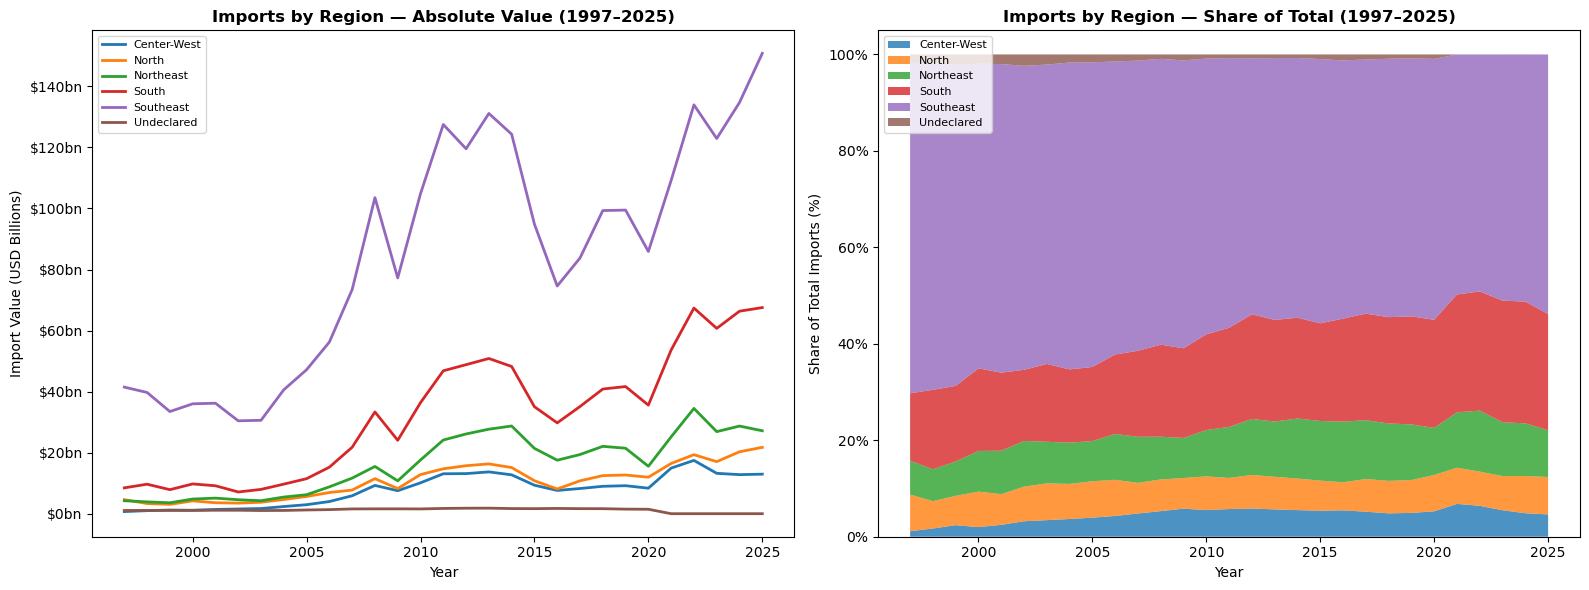


Regional import share — 1997 vs 2025
     Region  1997 (%)  1997 (USD bn)  2025 (%)  2025 (USD bn)  Change (pp)
  Southeast      68.5          41.47      53.8         150.82        -14.7
      South      14.0           8.47      24.1          67.53         10.1
  Northeast       7.0           4.25       9.7          27.17          2.7
      North       7.6           4.60       7.8          21.74          0.2
Center-West       1.1           0.69       4.6          12.96          3.5
 Undeclared       1.7           1.05       0.0           0.00         -1.7


In [110]:
query_region_imp = f"""
    SELECT i."CO_ANO" AS year,
           u.nome_regiao AS region,
           SUM(i."VL_FOB") AS imports_usd
    FROM imp i
    JOIN uf u ON i."SG_UF_NCM" = u.sigla
    WHERE i."CO_ANO" <= {MAX_YEAR}
    GROUP BY i."CO_ANO", u.nome_regiao
    ORDER BY i."CO_ANO"
"""

# Mapping dictionary (Portuguese -> English)
region_map = {
    'REGIAO NORDESTE'     : 'Northeast',
    'REGIAO NORTE'        : 'North',
    'REGIAO SUDESTE'      : 'Southeast',
    'REGIAO CENTRO OESTE' : 'Center-West',
    'REGIAO SUL'          : 'South',
    'REGIAO NAO DECLARADA': 'Undeclared'
}

# Regions/categories to exclude
exclude_regions = [
    'Não Declarada',
    'Exterior',
    'Consumo de Bordo',
    'Mercadoria Nacionalizada',
    'Reexportação',
    'Zona Não Declarada'
]

df_region_imp = pd.read_sql(query_region_imp, engine)

# Remove unwanted categories BEFORE mapping/pivot
df_region_imp = df_region_imp[~df_region_imp['region'].isin(exclude_regions)]

# Apply mapping
df_region_imp['region'] = df_region_imp['region'].map(region_map).fillna(df_region_imp['region'])

df_region_imp['imports_usd_bn'] = df_region_imp['imports_usd'] / 1e9
df_region_imp_pivot = df_region_imp.pivot(index='year', columns='region', values='imports_usd_bn').fillna(0)
df_region_imp_pct   = df_region_imp_pivot.div(df_region_imp_pivot.sum(axis=1), axis=0) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for region in df_region_imp_pivot.columns:
    ax1.plot(df_region_imp_pivot.index, df_region_imp_pivot[region], label=region, linewidth=2)

ax1.set_title(f"Imports by Region — Absolute Value (1997–{MAX_YEAR})", fontsize=12, fontweight='bold')
ax1.set_xlabel("Year")
ax1.set_ylabel("Import Value (USD Billions)")
ax1.legend(fontsize=8)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0fbn'))

ax2.stackplot(
    df_region_imp_pct.index,
    df_region_imp_pct.T,
    labels=df_region_imp_pct.columns,
    alpha=0.8
)

ax2.set_title(f"Imports by Region — Share of Total (1997–{MAX_YEAR})", fontsize=12, fontweight='bold')
ax2.set_xlabel("Year")
ax2.set_ylabel("Share of Total Imports (%)")
ax2.legend(loc='upper left', fontsize=8)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

plt.tight_layout()
plt.savefig('output_2_5b_region_imports.png', dpi=150)
plt.show()

start_year = df_region_imp_pct.index[0]
# Get absolute USD values for start and max year (already in billions)
usd_start = df_region_imp_pivot.loc[start_year].round(2)
usd_end   = df_region_imp_pivot.loc[MAX_YEAR].round(2)

summary_region_imp = pd.DataFrame({
    'Region'                      : df_region_imp_pct.columns,
    f'{start_year} (%)'           : df_region_imp_pct.loc[start_year].round(1).values,
    f'{start_year} (USD bn)'      : usd_start.values,
    f'{MAX_YEAR} (%)'             : df_region_imp_pct.loc[MAX_YEAR].round(1).values,
    f'{MAX_YEAR} (USD bn)'        : usd_end.values,
    'Change (pp)'                 : (df_region_imp_pct.loc[MAX_YEAR] - df_region_imp_pct.loc[start_year]).round(1).values
})

print(f"\nRegional import share — {start_year} vs {MAX_YEAR}")
print(summary_region_imp.sort_values(f'{MAX_YEAR} (%)', ascending=False).to_string(index=False))

#### Overview

In 1997, the Southeast accounted for 68.5% (\\$41.47bn) of Brazil's total imports. By 2025, that share had fallen to 53.8% (\\$150.82bn) — not because Southeast imports contracted in absolute terms, but because the South grew substantially faster. The result is a geographic rebalancing of Brazilian import demand toward the southern coast.

| Region      | 1997 (%) | 1997 (USD bn) | 2025 (%) | 2025 (USD bn) | Change (pp) |
|-------------|----------|---------------|----------|---------------|-------------|
| Southeast   | 68.5%    | \\$41.47bn      | 53.8%    | \\$150.82bn     | -14.7       |
| South       | 14.0%    | \\$8.47bn       | 24.1%    | \\$67.53bn      | +10.1       |
| Northeast   | 7.0%     | \\$4.25bn       | 9.7%     | \\$27.17bn      | +2.7        |
| North       | 7.6%     | \\$4.60bn       | 7.8%     | \\$21.74bn      | +0.2        |
| Center-West | 1.1%     | \\$0.69bn       | 4.6%     | \\$12.96bn      | +3.5        |

**South (+10.1pp)** recorded the largest shift on the import side — from \\$8.47bn (14.0%) to \\$67.53bn (24.1%), an approximately 8x increase compared to approximately 3.75x for the national total. Santa Catarina's \\$33.99bn import figure is the primary driver, consistent with the anomalous deficit identified in Sections 2.1 and 2.3. The absolute value chart confirms the timing: the South line is flat from 1997 to approximately 2015, then accelerates sharply and persistently. Product-level breakdown is deferred to Step 4.

**Southeast (-14.7pp)** remains the largest import region at \\$150.82bn (53.8%), but its share loss is the largest regional shift on the import side — nearly three times the magnitude of its export share loss (-5.1pp). Southeast imports grew from \\$41.47bn to $150.82bn in absolute terms, but growth slowed noticeably post-2015 as the South accelerated.

**Northeast (+2.7pp)** grew from \\$4.25bn to \\$27.17bn. **Center-West (+3.5pp)** grew from \\$0.69bn to \\$12.96bn. Product-level composition for both regions is unconfirmed and deferred to Step 4.

**North (+0.2pp)** held its import share virtually flat — \\$4.60bn (7.6%) to \\$21.74bn (7.8%) — despite its export share growing from 4.9% to 9.2% over the same period. This confirms that North's export growth is surplus-generating rather than import-dependent. Amazonas (\\$16.06bn imports) accounts for a substantial portion of the North total.

#### Export and Import Share Shifts Compared

| Region      | Export share Δ | Import share Δ |
|-------------|----------------|----------------|
| Southeast   | -5.1pp         | -14.7pp        |
| South       | -9.8pp         | +10.1pp        |
| Center-West | +12.3pp        | +3.5pp         |
| North       | +4.3pp         | +0.2pp         |
| Northeast   | -0.2pp         | +2.7pp         |

The South is the only region where export share declined while import share rose. The North and Center-West present the inverse: export share gains outpacing import share growth. The Southeast lost share on both sides.

> ⚠️ *Undeclared declining from 1.7% to effectively 0% on the import side — compared to 1.6% to 0.7% on the export side — suggests import origin recording improved more dramatically than export origin recording over the period.*
---
---

## 2.4 — Export Sector Structure: What Brazil's States and Regions Actually Sell

### 2.4.1 — Top 10 Export Sectors by State (SH2): Ranked Table with Share of State Total
For every state, the top 10 export sectors by SH2 classification ranked by value — each showing its share of that state's total exports.

In [111]:
top10_states_uf = df_state.head(10)['uf'].tolist()
top10_states_uf_str = ','.join([f"'{s}'" for s in top10_states_uf])

query_exp_sectors = f"""
    SELECT e."SG_UF_NCM" AS uf,
           u.nome_estado AS state,
           s.codigo_sh2,
           s.descricao_sh2_ing,
           SUM(e."VL_FOB") AS exports_usd
    FROM exp e
    JOIN uf u ON e."SG_UF_NCM" = u.sigla
    JOIN ncm n ON e."CO_NCM" = n.codigo_ncm
    JOIN ncm_sh s ON n.codigo_sh6 = s.codigo_sh6
    WHERE e."CO_ANO" = {MAX_YEAR}
    GROUP BY e."SG_UF_NCM", u.nome_estado, s.codigo_sh2, s.descricao_sh2_ing
    ORDER BY e."SG_UF_NCM", exports_usd DESC
"""

df_exp_sectors = pd.read_sql(query_exp_sectors, engine)
df_exp_sectors['exports_usd_bn'] = (df_exp_sectors['exports_usd'] / 1e9).round(2)

df_top10_sectors = (
    df_exp_sectors.groupby('state', group_keys=False)
    .apply(lambda x: x.nlargest(10, 'exports_usd'))
    .reset_index(drop=True)
)

print(f"Top 10 export sectors per state — SH2 classification ({MAX_YEAR})")
for state in df_top10_sectors['state'].unique():
    subset = df_top10_sectors[df_top10_sectors['state'] == state]
    total  = df_state[df_state['uf'] == subset['uf'].iloc[0]]['exports_usd_bn'].iloc[0]
    print(f"\n{state} — Total exports: ${total:.1f}bn")
    for _, row in subset.iterrows():
        share = (row['exports_usd'] / (total * 1e9) * 100)
        print(f"  SH{row['codigo_sh2']} {str(row['descricao_sh2_ing'])[:50]:<50} ${row['exports_usd_bn']:.2f}bn ({share:.1f}%)")

Top 10 export sectors per state — SH2 classification (2025)

Acre — Total exports: $0.1bn
  SH2 Meat and edible meat offal                         $0.05bn (47.5%)
  SH12 Oil seeds and oleaginous fruits; Grains, Seeds, ot $0.02bn (20.4%)
  SH8 Edible fruit and nuts; peel of citrus fruits or me $0.01bn (12.4%)
  SH1 Live animals                                       $0.01bn (5.1%)
  SH44 Wood and articles of wood; wood charcoal           $0.01bn (5.1%)
  SH5 Products of animal origin, not specified or includ $0.00bn (4.8%)
  SH72 Iron and steel                                     $0.00bn (1.2%)
  SH10 Cereals                                            $0.00bn (0.7%)
  SH23 Residues and waste from the food industries; other $0.00bn (0.4%)
  SH76 Aluminium and articles thereof                     $0.00bn (0.2%)

Alagoas — Total exports: $0.8bn
  SH17 Sugars and sugar confectionery                     $0.57bn (69.9%)
  SH26 Ores, slag and ash                                 $0.23bn (27.5%)


C:\Users\e_koh\AppData\Local\Temp\ipykernel_27852\2577196992.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(10, 'exports_usd'))


#### Overview

Brazil's 27 states exported a combined \\$348.8bn in 2025. Export activity is highly concentrated: São Paulo (\\$71.4bn), Rio de Janeiro (\\$49.0bn), and Minas Gerais (\\$45.8bn) alone account for 47.9% of national exports. At the other end, six states — Acre, Amapá, Paraíba, Roraima, Sergipe, and Distrito Federal — each exported under \\$0.5bn, collectively representing under 0.4% of the national total.

The state-level product data reveals four structurally distinct export profiles across Brazil's states.

---

#### Export Profile 1 — Soybean-Led Agricultural Commodity States

The most prevalent profile in the dataset. States in this group are defined by SH12 (oil seeds, principally soybeans) as the dominant export sector, typically complemented by SH2 (meat), SH10 (cereals), and SH23 (soy residues and animal feed).

| State | Total Exports | SH12 Share |
|---|---|---|
| Mato Grosso | \\$30.2bn | 43.6% |
| Piauí | \\$1.2bn | 82.8% |
| Goiás | \\$13.5bn | 38.7% |
| Mato Grosso do Sul | \\$10.8bn | 23.0% |
| Rondônia | \\$3.1bn | 32.7% |
| Tocantins | \\$3.0bn | 53.3% |
| Roraima | \\$0.2bn | 41.1% |

Mato Grosso is the archetype: \\$30.2bn in total exports with SH12 (\\$13.17bn), SH10 (\\$4.67bn), SH2 (\\$4.47bn), SH52 (\\$3.13bn), and SH23 (\\$2.95bn) accounting for 94.1% of state exports across five commodity sectors. Piauí is the most concentrated in the dataset — SH12 alone at 82.8% (\\$0.99bn) with no other sector above 3.6%.

This profile corresponds directly to the structural reversal documented in Section 2.12: the expansion of primary commodity exports from 27.7% to 58.2% of national exports between 1997 and 2025 is driven disproportionately by this group.

---

#### Export Profile 2 — Mineral Extraction States

Defined by SH26 (ores, slag and ash) as the primary or co-primary sector. These states sit on Brazil's principal mineral belts.

| State | Total Exports | Primary Mineral Sector | Share |
|---|---|---|---|
| Pará | \\$24.3bn | SH26 Ores | 64.6% |
| Minas Gerais | \\$45.8bn | SH26 Ores | 27.0% |
| Espírito Santo | \\$10.5bn | SH26 Ores | 28.2% |

Pará is the most concentrated mineral exporter — SH26 at \\$15.73bn (64.6%) with SH28 inorganic chemicals at \\$2.30bn (9.4%) as the secondary sector. Minas Gerais presents a more diversified mineral profile: SH26 (\\$12.37bn, 27.0%) combined with SH9 coffee (\\$11.29bn, 24.6%) and SH72 iron and steel (\\$4.67bn, 10.2%), making it the only state in this group with meaningful non-mineral export diversification. Espírito Santo's profile combines SH26 with SH9 coffee, SH72 iron and steel, and SH47 pulp.

---

#### Export Profile 3 — Petroleum-Dominant States

Defined by SH27 (mineral fuels and oils) as the dominant sector. This profile is limited to two states and one non-geographic category.

| State | Total Exports | SH27 Share |
|---|---|---|
| Rio de Janeiro | \\$49.0bn | 83.3% |
| Rio Grande do Norte | \\$1.1bn | 52.7% |
| Sergipe | \\$0.5bn | 61.9% |

Rio de Janeiro is the most concentrated single-sector state in the dataset — SH27 at \\$40.79bn (83.3%) with no other sector above 4.3%. This concentration is the primary reason Rio de Janeiro was identified as the structural outlier in the regression analysis (Section 2b.5): its export frequency profile is distorted by bulk petroleum shipment volumes that are structurally incomparable to other states.

---

#### Export Profile 4 — Industrialised and Diversified States

Defined by the presence of manufactured goods — vehicles (SH87), machinery (SH84), electrical equipment (SH85), aircraft (SH88) — among the top export sectors, with no single commodity sector above 50%.

| State | Total Exports | Distinguishing Sectors |
|---|---|---|
| São Paulo | \\$71.4bn | SH17 sugar, SH87 vehicles, SH84 machinery, SH88 aircraft |
| Paraná | \\$23.6bn | SH87 vehicles, SH84 machinery alongside SH12, SH2 |
| Rio Grande do Sul | \\$21.5bn | SH24 tobacco, SH87 vehicles, SH84 machinery alongside SH12, SH2 |
| Santa Catarina | \\$12.2bn | SH2 meat, SH84 machinery, SH85 electrical equipment |
| Amazonas | \\$0.9bn | SH87 vehicles, SH85 electrical equipment, SH84 machinery |
| Pernambuco | \\$2.5bn | SH87 vehicles (39.7%) |
| Ceará | \\$2.3bn | SH72 iron and steel (51.8%) |

São Paulo is the only state in the dataset that combines commodity scale (SH17 sugar at \\$8.47bn) with a diversified industrial base across vehicles, machinery, aircraft, and electrical equipment. Paraná and Rio Grande do Sul are hybrid states — commodity export volumes comparable to Center-West states combined with meaningful manufactured goods sectors. Santa Catarina's profile is notable: SH2 meat at 34.1% followed by machinery and electrical equipment, consistent with the industrial-agribusiness mix of its economy.

Amazonas is structurally anomalous within the North region — SH87 vehicles (\\$0.14bn) and SH85 electrical equipment (\\$0.06bn) in a region otherwise defined by commodities, a legacy of the Zona Franca de Manaus industrial policy. This is consistent with the value density outlier identified in Section 2b.6.

---

#### Cross-Cutting Observations

**SH12 is the single most widely distributed sector in the dataset.** It appears in the top 10 export sectors of 23 of 27 states. No other sector approaches this geographic penetration. SH2 (meat) appears in 20 states. Together, SH12 and SH2 are present as top-10 sectors in the majority of Brazilian states regardless of region or economic profile — reflecting the scale of Brazil's agribusiness footprint even in states where manufacturing or minerals dominate.

**SH72 (iron and steel) appears in 18 states** across all four profiles, including industrialised states (São Paulo, Paraná), commodity states (Goiás, Mato Grosso), and mineral states (Minas Gerais, Pará). Its presence reflects both domestic steel production capacity and the downstream processing of mineral extraction — it is not confined to a single export profile.

**Single-sector concentration above 50% is a risk indicator present in eight states:** Rio de Janeiro (83.3% SH27), Piauí (82.8% SH12), Pará (64.6% SH26), Sergipe (61.9% SH27), Rio Grande do Norte (52.7% SH27), Tocantins (53.3% SH12), Ceará (51.8% SH72), and Rondônia (50.3% SH2). For these states, export revenue is materially exposed to price cycles in a single global commodity market.

**The industrial base is geographically narrow.** Manufactured goods in meaningful volumes — vehicles, machinery, aircraft, electrical equipment — are concentrated in São Paulo, Paraná, Rio Grande do Sul, Santa Catarina, and Amazonas. Outside these five states, manufactured exports either do not appear in the top 10 or appear at marginal values. Brazil's export diversification challenge, documented at national level in Section 2.12, is a state-level concentration problem rather than a uniform national characteristic.

> ⚠️ *Ceará's top sector is SH72 iron and steel at 51.8% (\\$1.18bn). Given Ceará's 55.6% YoY export growth identified in Section 2.13, this concentration warrants NCM-level investigation to confirm whether this reflects CSP steel plant ramp-up volumes. Deferred to Step 4.*

> ⚠️ *Bahia's SH71 (natural or cultured pearls, precious or semi-precious stones) at \\$1.10bn (9.5%) was resolved as gold bullion in Section 2.7. The same SH71 entries appear in Goiás (\\$0.36bn), Maranhão (\\$0.25bn), Tocantins ($0.20bn), and Amazonas (\\$0.17bn) — NCM-level confirmation of composition is deferred to Step 4.*
---
---

### 2.4.2 — Brazil Annual Export Composition by Sector (1997–2025)
Annual stacked bar chart showing Brazil's total export value by SH2 sector from 1997 to 2025, revealing how the export product mix has shifted over time.

*Sectors below 0.1% share of total exports are excluded from the summary table. All sectors areincluded in the stacked bar chart.*

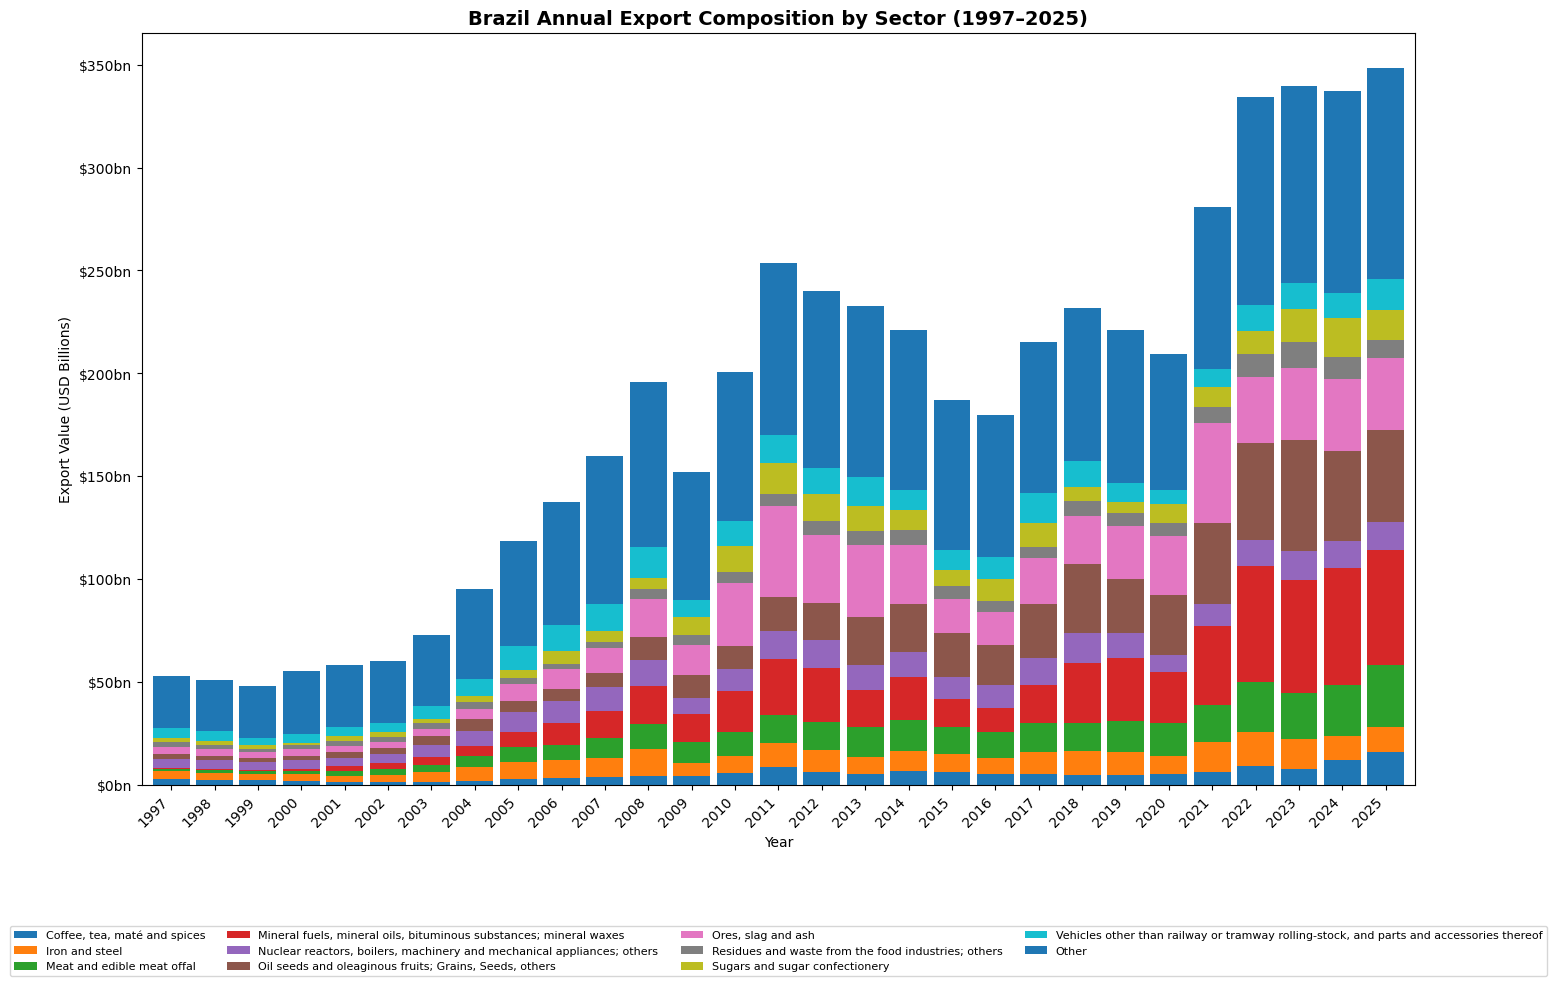


Brazil export composition by sector (2025) — Total: $348.3bn



Sector,Exports (USD bn),Share (%)
"Mineral fuels, mineral oils, bituminous substances; min",$55.96bn,16.1%
"Oil seeds and oleaginous fruits; Grains, Seeds, others",$44.67bn,12.8%
"Ores, slag and ash",$34.89bn,10.0%
Meat and edible meat offal,$29.98bn,8.6%
"Coffee, tea, maté and spices",$15.65bn,4.5%
"Vehicles other than railway or tramway rolling-stock, a",$15.08bn,4.3%
Sugars and sugar confectionery,$14.34bn,4.1%
"Nuclear reactors, boilers, machinery and mechanical app",$13.89bn,4.0%
Iron and steel,$12.35bn,3.5%
"Pulp of wood or of other fibrous cellulosic material, o",$10.17bn,2.9%


In [112]:
## Brazil annual export composition by SH2 sector (1997–MAX_YEAR)
query_brazil_exp_annual = f"""
    SELECT e."CO_ANO" AS year,
           s.descricao_sh2_ing AS sector,
           SUM(e."VL_FOB") AS exports_usd
    FROM exp e
    JOIN ncm n ON e."CO_NCM" = n.codigo_ncm
    JOIN ncm_sh s ON n.codigo_sh6 = s.codigo_sh6
    WHERE e."CO_ANO" <= {MAX_YEAR}
    GROUP BY e."CO_ANO", s.descricao_sh2_ing
    ORDER BY e."CO_ANO", exports_usd DESC
"""
df_brazil_exp_annual = pd.read_sql(query_brazil_exp_annual, engine)
df_brazil_exp_annual['exports_usd_bn'] = df_brazil_exp_annual['exports_usd'] / 1e9

## Identify top 10 sectors by total exports across all years — group rest as Other
top10_exp_sectors = (
    df_brazil_exp_annual.groupby('sector')['exports_usd']
    .sum().nlargest(10).index.tolist()
)
df_brazil_exp_annual['sector_group'] = df_brazil_exp_annual['sector'].apply(
    lambda x: x if x in top10_exp_sectors else 'Other'
)
df_brazil_exp_grouped = (
    df_brazil_exp_annual.groupby(['year', 'sector_group'])['exports_usd_bn']
    .sum().reset_index()
)
df_brazil_exp_pivot = df_brazil_exp_grouped.pivot(
    index='year', columns='sector_group', values='exports_usd_bn'
).fillna(0)

## Reorder columns so Other is last
cols_ordered = [c for c in df_brazil_exp_pivot.columns if c != 'Other'] + ['Other']
df_brazil_exp_pivot = df_brazil_exp_pivot[cols_ordered]

## ---- Chart ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 10))
df_brazil_exp_pivot.plot(kind='bar', stacked=True, ax=ax, width=0.85)
ax.set_title(f"Brazil Annual Export Composition by Sector (1997–{MAX_YEAR})",
             fontsize=14, fontweight='bold')
ax.set_xlabel("Year")
ax.set_ylabel("Export Value (USD Billions)")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0fbn'))
ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.18),
    ncol=4,
    fontsize=8,
    frameon=True
)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('output_2_6b_brazil_exp_annual_bar.png', dpi=150, bbox_inches='tight')
plt.show()


## ---- Summary table (MAX_YEAR only, filtered to >= 0.1%) ─────────────────────
df_exp_annual_display = (
    df_brazil_exp_annual[df_brazil_exp_annual['year'] == MAX_YEAR]
    .groupby('sector')['exports_usd_bn'].sum()
    .sort_values(ascending=False)
    .reset_index()
    .assign(share=lambda x: (x['exports_usd_bn'] / x['exports_usd_bn'].sum() * 100).round(1))
)

## Filter out sectors below 0.1% share
df_exp_annual_display = df_exp_annual_display[df_exp_annual_display['share'] >= 0.1]

df_exp_annual_display = (
    df_exp_annual_display
    .rename(columns={
        'sector'        : 'Sector',
        'exports_usd_bn': 'Exports (USD bn)',
        'share'         : 'Share (%)'
    })
    .reset_index(drop=True)
)
df_exp_annual_display['Sector']           = df_exp_annual_display['Sector'].str[:55]
df_exp_annual_display['Exports (USD bn)'] = df_exp_annual_display['Exports (USD bn)'].apply(lambda x: f'${x:.2f}bn')
df_exp_annual_display['Share (%)']        = df_exp_annual_display['Share (%)'].apply(lambda x: f'{x:.1f}%')

total = df_brazil_exp_annual[df_brazil_exp_annual['year'] == MAX_YEAR]['exports_usd_bn'].sum()
print(f"\nBrazil export composition by sector ({MAX_YEAR}) — Total: ${total:.1f}bn\n")
display(df_exp_annual_display.style
    .set_caption(f"Brazil export composition by sector ({MAX_YEAR})")
    .set_properties(**{'text-align': 'left'})
    .hide(axis='index'))

#### Overview

Brazil's total exports reached \\$348.3bn in 2025, up from approximately \\$53bn in 1997 — a 6.6x increase over 28 years. The chart reveals three structurally distinct periods: a gradual expansion from 1997 to 2011 (peak at approximately \\$256bn), a contraction and stagnation from 2011 to 2016, and a recovery phase from 2016 onward that reached a new peak in 2025. The sector composition shifted materially across the period.

#### 2025 Sector Composition

The top 10 sectors account for 70.8% of total exports (\\$246.7bn). The top 4 sectors are all primary or minimally processed commodities and account for \\$165.50bn (47.5%) combined.

| Sector | 2025 (\\$bn) | Share (%) |
|---|---|---|
| Mineral fuels and oils (SH27) | \\$55.96bn | 16.1% |
| Oil seeds and oleaginous fruits (SH12) | \\$44.67bn | 12.8% |
| Ores, slag and ash (SH26) | \\$34.89bn | 10.0% |
| Meat and edible meat offal (SH2) | \\$29.98bn | 8.6% |
| Coffee, tea, maté and spices (SH9) | \\$15.65bn | 4.5% |
| Vehicles (SH87) | \\$15.08bn | 4.3% |
| Sugars and sugar confectionery (SH17) | \\$14.34bn | 4.1% |
| Machinery (SH84) | \\$13.89bn | 4.0% |
| Iron and steel (SH72) | \\$12.35bn | 3.5% |
| Pulp of wood (SH47) | \\$10.17bn | 2.9% |

The first manufactured goods sector, vehicles (SH87), appears sixth at 4.3% — below four primary commodity sectors and coffee.

Below the top 10, 52 additional sectors contribute the remaining 29.2% (\\$101.6bn). No individual sector in this long tail exceeds 2.7% (cereals, \\$9.56bn). The data table confirms 94 active SH2 export chapters in 2025 — Brazil exports something from nearly every product category, but the top 10 account for 70.8% of total value and the bottom 50+ chapters collectively account for less than 5%.

##### Structural Transformation 1 — The Commodity Surge (2003–2011)

From approximately \\$50bn (1997–2002) to \\$256bn (2011) — a 5x increase in 9 years. The chart shows the bar growing dramatically taller while the relative proportions of the underlying sectors remain broadly similar. Oil seeds (SH12), ores (SH26), meat (SH2) and coffee (SH9) all expanded in absolute value simultaneously across this period.

##### Structural Transformation 2 — The Oil Emergence (Post-2015)

The SH27 (mineral fuels) segment remains relatively limited through 2014, before increasing significantly from 2016 onward. By the 2020–2025 period, it becomes the largest individual export segment. In 2025, SH27 reaches approximately \\$55.96 billion (16.1% of total exports), a position it does not appear to hold prior to around 2018.

This shift coincides with the [expansion of production in Brazil’s pre-salt oil fields](https://worldoil.com/magazine/2021/february-2021/features/regional-report-brazil/), suggesting a structural change in the composition of exports over the period.

##### Structural Transformation 3 — The Soybean Acceleration (Post-2020)

The SH12 (soybeans) segment shows a marked increase beginning in 2020, with the highest absolute export values observed between 2022 and 2025.

This expansion occurs alongside several external and domestic factors, including the [disruption of global agricultural supply chains following the Russia–Ukraine conflict (from 2022 onward)](https://www.oecd.org/content/dam/oecd/en/publications/reports/2022/06/oecd-fao-agricultural-outlook-2022-2031_e00c413c/f1b0b29c-en.pdf), [continued agricultural frontier expansion in the MATOPIBA region](https://www.embrapa.br/en/tema-matopiba), and sustained demand from China. These factors, discussed in Step 1 and Section 2.7, align temporally with the observed increase in soybean exports.

---

#### The Industrial Sectors

The industrial segments — vehicles (SH87), machinery (SH84), electrical equipment (SH85, \\$5.10bn, 1.5%), and aerospace (SH88, \\$4.89bn, 1.4%) — maintained broadly stable absolute values across the full period while the commodity base expanded beneath them.

Combined vehicles and machinery accounted for approximately 15–18% of exports in the late 1990s and early 2000s against 8.3% in 2025. The absolute values of these sectors grew modestly but their share declined as commodity sectors expanded at a faster rate.

> ⚠️ *The 15–18% vehicles and machinery share for 1997–2002 is estimated from the chart and has not been confirmed from the underlying data. A query isolating SH87 and SH84 share by year is needed to confirm this figure precisely.*

---

#### Contractions and Shocks

**2009** — All sectors contracted proportionally. The sector composition within the bar is effectively unchanged — the contraction compressed the entire export base without altering its structure.

**2014–2016** — The ores and iron and steel segments visibly shrank while the oil seeds and mineral fuels segments held more stable. This is consistent with the state-level finding in Section 2.1.3 that Pará and Minas Gerais — mineral extraction states — were more affected during this period than Centro-Oeste agricultural states.

**2020 (COVID-19)** — The 2020 bar shows minimal contraction relative to 2019 and the sector composition is effectively unchanged. This is consistent with the findings in Steps 1 and 2 that Brazil's goods trade was not materially disrupted at the aggregate level during the pandemic year.

---

#### The Post-2020 Surge

The bars for 2021–2025 are the tallest in the dataset. Three concurrent factors are visible in the chart:

1. The SH27 mineral fuels segment grows year-on-year from 2020 onward
2. The SH12 oil seeds segment reaches its largest absolute values in 2022–2023
3. The SH26 ores segment recovered from its 2015–2016 contraction

The 2022 bar shows the SH27, SH12 and SH26 segments all at or near peak values simultaneously. Whether this convergence reflects price effects, volume effects, or currency effects requires the volume vs. value decomposition in Section 2.15 and is not resolvable from the composition chart alone.

---

#### Structural Conclusion

Brazil's export composition became more commodity-concentrated between 1997 and 2025. The top 4 primary commodity sectors increased their combined share from an estimated 35–40% in 1997 to 47.5% in 2025, while vehicles and machinery declined from an estimated 15–18% to 8.3% over the same period.

> ⚠️ *The 1997 share estimates for primary commodities and industrial sectors are derived from visual inspection of the stacked bar chart and require query-level confirmation before they can be stated as precise figures in any published output.*

> ⚠️ *SH71 (natural or cultured pearls, precious or semi-precious stones) appears at \\$7.19bn (2.1%) — the 13th largest export sector nationally. As flagged in Section 2.4.1, the NCM-level composition of this category requires Step 4 investigation before the figure can be interpreted structurally.*

---
---

## 2.5 — Import Sector Structure: What Brazil's States and Regions Actually Buy

### 2.5.1 — Top 10 Import Sectors by State (SH2): Ranked Table with Share of State Total
For every state, the top 10 import sectors by SH2 classification ranked by value — each showing its share of that state total imports.

In [113]:
top10_imp_states_uf = df_state.nlargest(10, 'imports_usd_bn')['uf'].tolist()
top10_imp_states_uf_str = ','.join([f"'{s}'" for s in top10_imp_states_uf])

query_imp_sectors = f"""
    SELECT i."SG_UF_NCM" AS uf,
           u.nome_estado AS state,
           s.codigo_sh2,
           s.descricao_sh2_ing,
           SUM(i."VL_FOB") AS imports_usd
    FROM imp i
    JOIN uf u ON i."SG_UF_NCM" = u.sigla
    JOIN ncm n ON i."CO_NCM" = n.codigo_ncm
    JOIN ncm_sh s ON n.codigo_sh6 = s.codigo_sh6
    WHERE i."CO_ANO" = {MAX_YEAR}
    GROUP BY i."SG_UF_NCM", u.nome_estado, s.codigo_sh2, s.descricao_sh2_ing
    ORDER BY i."SG_UF_NCM", imports_usd DESC
"""

df_imp_sectors = pd.read_sql(query_imp_sectors, engine)
df_imp_sectors['imports_usd_bn'] = (df_imp_sectors['imports_usd'] / 1e9).round(2)

df_top10_imp_sectors = (
    df_imp_sectors.groupby('state', group_keys=False)
    .apply(lambda x: x.nlargest(10, 'imports_usd'))
    .reset_index(drop=True)
)

print(f"Top 10 import sectors per state — SH2 classification ({MAX_YEAR})")
for state in df_top10_imp_sectors['state'].unique():
    subset = df_top10_imp_sectors[df_top10_imp_sectors['state'] == state]
    total  = df_state[df_state['uf'] == subset['uf'].iloc[0]]['imports_usd_bn'].iloc[0]
    print(f"\n{state} — Total imports: ${total:.1f}bn")
    for _, row in subset.iterrows():
        share = (row['imports_usd'] / (total * 1e9) * 100)
        print(f"  SH{row['codigo_sh2']} {str(row['descricao_sh2_ing'])[:50]:<50} ${row['imports_usd_bn']:.2f}bn ({share:.1f}%)")

Top 10 import sectors per state — SH2 classification (2025)

Acre — Total imports: $0.0bn
  SH88 Aircraft, spacecraft, and parts thereof            $0.00bn (19.3%)
  SH84 Nuclear reactors, boilers, machinery and mechanica $0.00bn (9.4%)
  SH93 Arms and ammunition; parts and accessories thereof $0.00bn (7.9%)
  SH85 Electrical machinery and equipment and parts there $0.00bn (5.4%)
  SH90 Optical, photographic, cinematographic instruments $0.00bn (3.9%)
  SH40 Rubber and articles thereof                        $0.00bn (1.7%)
  SH32 Tanning or dyeing extracts; tannins and their deri $0.00bn (1.0%)
  SH28 Inorganic chemicals; organic or inorganic compound $0.00bn (0.6%)
  SH7 Edible vegetables and certain roots and tubers     $0.00bn (0.5%)
  SH44 Wood and articles of wood; wood charcoal           $0.00bn (0.5%)

Alagoas — Total imports: $1.1bn
  SH39 Plastics and articles thereof                      $0.12bn (10.4%)
  SH85 Electrical machinery and equipment and parts there $0.11bn (10.1%)

C:\Users\e_koh\AppData\Local\Temp\ipykernel_27852\2095680266.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(10, 'imports_usd'))
C:\Users\e_koh\AppData\Local\Temp\ipykernel_27852\2095680266.py:34: RuntimeWarning: divide by zero encountered in scalar divide
  share = (row['imports_usd'] / (total * 1e9) * 100)


#### Overview

Brazil's 27 states imported a combined \\$281.5bn in 2025. Import activity is even more concentrated than exports: São Paulo (\\$86.5bn), Santa Catarina (\\$34.0bn), and Rio de Janeiro (\\$32.2bn) account for 54.2% of national imports. At the other end, six states — Acre, Amapá, Roraima, Tocantins, Rio Grande do Norte, and Sergipe — each imported under \\$0.5bn, collectively representing under 0.5% of the national total.

The state-level import data reveals four structurally distinct import profiles.

---

#### Import Profile 1 — Fertiliser-Dependent Agricultural States

Defined by SH31 (fertilisers) as the dominant or co-dominant import sector. These are the same states that appear in Export Profile 1 — the agricultural commodity exporters whose surplus generation depends on imported agricultural inputs.

| State | Total Imports | SH31 Share | SH31 Value |
|---|---|---|---|
| Mato Grosso | \\$2.6bn | 61.7% | \\$1.62bn |
| Tocantins | \\$0.3bn | 51.0% | \\$0.18bn |
| Maranhão | \\$4.8bn | 25.0% | \\$1.19bn |
| Paraná | \\$20.1bn | 15.0% | \\$3.02bn |
| Rio Grande do Sul | \\$13.4bn | 19.4% | \\$2.59bn |
| Pará | \\$2.7bn | 24.4% | \\$0.67bn |
| Roraima | \\$0.1bn | 29.1% | \\$0.01bn |

Mato Grosso is the archetype: \\$1.62bn in fertiliser imports (61.7%) against \\$30.2bn in agricultural exports — a coverage ratio that confirms the export surplus is structurally dependent on imported inputs. Maranhão presents the starkest combined picture: SH27 mineral fuels at 66.0% (\\$3.14bn) combined with SH31 fertilisers at 25.0% (\\$1.19bn) account for 91.0% of total imports — a state whose entire import profile is defined by energy and agricultural production inputs.

The fertiliser dependency finding identified at national level in Section 2.12 is confirmed at state level: the agricultural surplus states are simultaneously the most fertiliser-import- dependent states in the dataset.

---

#### Import Profile 2 — Industrial Input States

Defined by SH84 (machinery) and SH85 (electrical equipment) as the dominant import sectors, reflecting manufacturing and industrial activity rather than commodity production.

| State | Total Imports | Primary Import Sectors |
|---|---|---|
| São Paulo | \\$86.5bn | SH84 \\$15.72bn (18.2%), SH85 \\$10.66bn (12.3%) |
| Santa Catarina | \\$34.0bn | SH84 \\$4.41bn (13.0%), SH85 \\$3.68bn (10.8%) |
| Minas Gerais | \\$18.3bn | SH84 \\$3.16bn (17.2%), SH85 \\$1.87bn (10.2%) |
| Paraná | \\$20.1bn | SH84 \\$3.07bn (15.2%), SH85 \\$1.50bn (7.4%) |
| Amazonas | \\$16.1bn | SH85 \\$7.06bn (44.0%), SH84 \\$2.23bn (13.9%) |

São Paulo's import profile mirrors its export diversification — machinery, electrical equipment, organic chemicals (\\$7.72bn), pharmaceuticals (\\$6.60bn), and precision instruments (\\$4.70bn) span six economic domains with no single sector above 18.2%. Amazonas is the outlier within this group: SH85 at 44.0% (\\$7.06bn) reflects the Zona Franca de Manaus industrial sector. This import profile is structurally distinct from São Paulo's diversified industrial sourcing.

Santa Catarina's import profile — SH84, SH85, SH39 plastics, SH72 iron and steel, SH74 copper — is consistent with a manufacturing and assembly economy. However, at \\$34.0bn total imports against \\$12.2bn total exports, the scale of Santa Catarina's import volume relative to its export base remains the most unresolved structural finding in the dataset. The import composition does not itself explain the deficit. Deferred to Step 4.

---

#### Import Profile 3 — Petroleum-Dominated States

Defined by SH27 (mineral fuels) as the dominant import sector. The states in this group are largely smaller economies without domestic refining capacity or with port-linked fuel distribution roles.

| State | Total Imports | SH27 Share | SH27 Value |
|---|---|---|---|
| Amapá | \\$0.3bn | 76.0% | \\$0.22bn |
| Maranhão | \\$4.8bn | 66.0% | \\$3.14bn |
| Paraíba | \\$1.0bn | 49.0% | \\$0.49bn |
| Sergipe | \\$0.4bn | 47.2% | \\$0.18bn |
| Bahia | \\$9.3bn | 43.8% | \\$4.08bn |
| Ceará | \\$2.6bn | 24.8% | \\$0.65bn |

Bahia's SH27 dominance (\\$4.08bn, 43.8%) combined with SH31 fertilisers (\\$0.98bn, 10.5%) and SH84 machinery (\\$0.67bn, 7.2%) reflects the Camaçari industrial complex's energy and chemical input requirements — the same complex that produces Bahia's diversified export profile in Section 2.4.1.

---

#### Import Profile 4 — Structurally Anomalous States

Three states present import profiles that do not fit the above categories and require specific explanation.

**Rio de Janeiro (\\$32.2bn)** — SH84 machinery dominates at 37.6% (\\$12.10bn), followed by SH27 mineral fuels (\\$6.19bn, 19.3%) and SH89 ships and floating structures (\\$2.46bn, 7.7%). This profile reflects offshore oil infrastructure: the machinery, vessels, and fuel imports are inputs to the petroleum extraction industry that generates Rio de Janeiro's \\$40.79bn in SH27 exports. Rio de Janeiro is simultaneously Brazil's largest petroleum exporter and a major importer of the capital equipment required to produce that petroleum.

**Distrito Federal (\\$2.3bn)** — SH30 pharmaceutical products at 82.5% (\\$1.86bn) is the most concentrated single-sector import profile in the dataset. This reflects the concentration of federal health procurement in Brasília rather than local industrial activity. No other sector exceeds 3.8%.

**Espírito Santo (\\$13.8bn)** — SH87 vehicles at 45.0% (\\$6.21bn) is anomalous for a state whose export profile is defined by ores, coffee and steel. Vehicle imports at this scale in a state without a major domestic vehicle market suggest a transshipment or re-export role through the ports of Vitória and Vila Velha. This hypothesis is unconfirmed. Deferred to Step 4.

---

#### Cross-Cutting Observations

**SH84 (machinery) appears in the top 10 of all 27 states.** It is the only sector with universal geographic presence on the import side — reflecting the dependence of every state economy on imported capital equipment regardless of economic profile.

**SH85 (electrical equipment) appears in the top 10 of 24 states.** Combined with SH84, these two sectors represent Brazil's broadest and most consistent import dependency — industrial capital goods sourced internationally across the entire country.

**SH31 (fertilisers) appears in the top 10 of 17 states**, concentrated in agricultural and frontier states. The national fertiliser import bill identified in Section 2.12 (\\$15.49bn) is distributed across these 17 states, with Paraná (\\$3.02bn), Rio Grande do Sul (\\$2.59bn), and Mato Grosso (\\$1.62bn) accounting for the largest volumes.

**SH27 (mineral fuels) appears in the top 10 of 22 states**, reflecting Brazil's continued dependence on imported petroleum products despite being a major crude oil exporter — a refining capacity gap that is visible at state level across every region.

**The import side is structurally more uniform than the export side.** On exports, five distinct profiles with meaningful product differentiation were identified. On imports, the majority of states draw from the same three or four sectors — machinery, electrical equipment, fuels, and fertilisers — with variation primarily in the weighting rather than the composition. This uniformity reflects Brazil's import structure being driven by industrial input requirements and energy dependency rather than by state-specific economic activity.

> ⚠️ *Espírito Santo's SH87 vehicle imports at \\$6.21bn (45.0%) cannot be explained by domestic demand alone. The transshipment hypothesis requires NCM-level and customs declaration analysis to confirm whether these vehicles are re-exported or retained domestically. Deferred to Step 4.*

---
---

## 2.5.2 — Brazil Annual Import Composition by Sector (1997–2025)
Annual stacked bar chart showing Brazil's total import value by SH2 sector from 1997 to 2025, revealing how the import product mix has shifted over time.

*Sectors below 0.1% share of total imports are excluded from the summary table. All sectors are included in the stacked bar chart.*

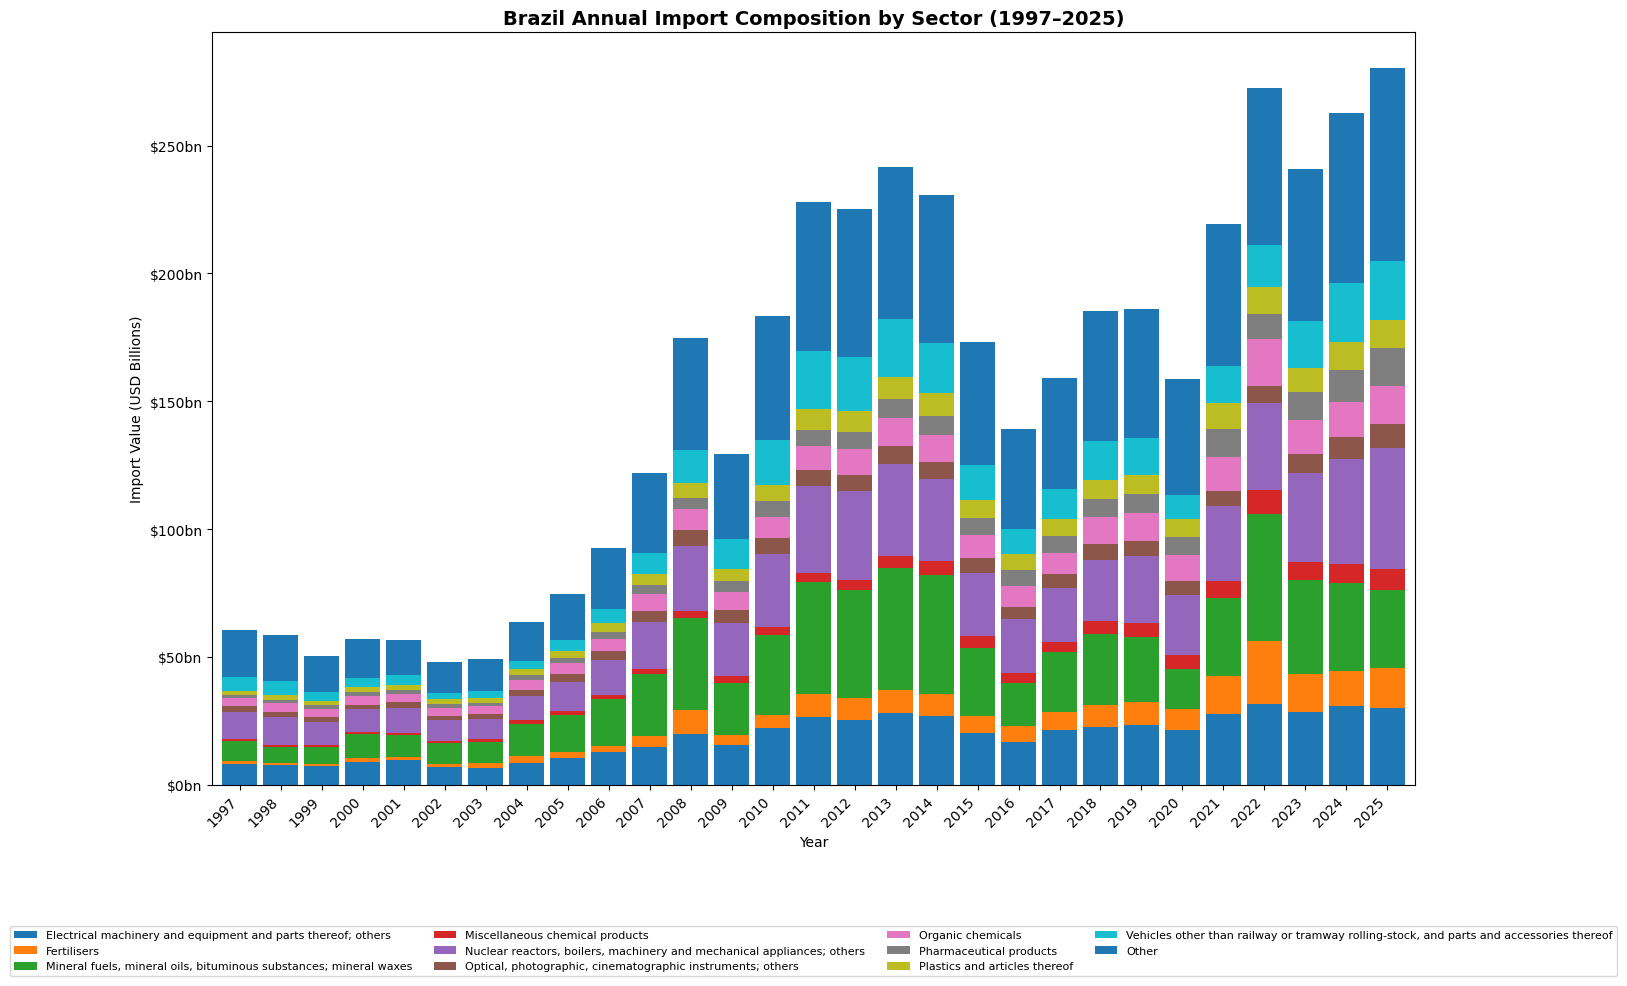


Brazil import composition by sector (2025) — Total: $280.2bn



Sector,Imports (USD bn),Share (%)
"Nuclear reactors, boilers, machinery and mechanical app",$47.03bn,16.8%
"Mineral fuels, mineral oils, bituminous substances; min",$30.53bn,10.9%
Electrical machinery and equipment and parts thereof; o,$30.13bn,10.8%
"Vehicles other than railway or tramway rolling-stock, a",$23.06bn,8.2%
Fertilisers,$15.49bn,5.5%
Organic chemicals,$14.97bn,5.3%
Pharmaceutical products,$14.54bn,5.2%
Plastics and articles thereof,$10.99bn,3.9%
"Optical, photographic, cinematographic instruments; oth",$9.55bn,3.4%
Miscellaneous chemical products,$8.47bn,3.0%


In [114]:
## Brazil annual import composition by SH2 sector (1997–MAX_YEAR)
query_brazil_imp_annual = f"""
    SELECT i."CO_ANO" AS year,
           s.descricao_sh2_ing AS sector,
           SUM(i."VL_FOB") AS imports_usd
    FROM imp i
    JOIN ncm n ON i."CO_NCM" = n.codigo_ncm
    JOIN ncm_sh s ON n.codigo_sh6 = s.codigo_sh6
    WHERE i."CO_ANO" <= {MAX_YEAR}
    GROUP BY i."CO_ANO", s.descricao_sh2_ing
    ORDER BY i."CO_ANO", imports_usd DESC
"""

### ____________ Graph - Brazil Annual Import Composition by Sector (All Years) _______________________

df_brazil_imp_annual = pd.read_sql(query_brazil_imp_annual, engine)
df_brazil_imp_annual['imports_usd_bn'] = df_brazil_imp_annual['imports_usd'] / 1e9

## Identify top 10 sectors by total imports across all years — group rest as Other
top10_imp_sectors = (
    df_brazil_imp_annual.groupby('sector')['imports_usd']
    .sum().nlargest(10).index.tolist()
)

df_brazil_imp_annual['sector_group'] = df_brazil_imp_annual['sector'].apply(
    lambda x: x if x in top10_imp_sectors else 'Other'
)

df_brazil_imp_grouped = (
    df_brazil_imp_annual.groupby(['year', 'sector_group'])['imports_usd_bn']
    .sum().reset_index()
)

df_brazil_imp_pivot = df_brazil_imp_grouped.pivot(
    index='year', columns='sector_group', values='imports_usd_bn'
).fillna(0)

## Reorder columns so Other is last
cols_ordered = [c for c in df_brazil_imp_pivot.columns if c != 'Other'] + ['Other']
df_brazil_imp_pivot = df_brazil_imp_pivot[cols_ordered]

## Plot
fig, ax = plt.subplots(figsize=(16, 10))
df_brazil_imp_pivot.plot(kind='bar', stacked=True, ax=ax, width=0.85)
ax.set_title(f"Brazil Annual Import Composition by Sector (1997–{MAX_YEAR})",
             fontsize=14, fontweight='bold')
ax.set_xlabel("Year")
ax.set_ylabel("Import Value (USD Billions)")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0fbn'))
ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.18),
    ncol=4,
    fontsize=8,
    frameon=True
)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('output_2_7b_brazil_imp_annual_bar.png', dpi=150, bbox_inches='tight')
plt.show()

###___________ Summary Table Brazil import composition by sector _________________
## Summary table for MAX_YEAR
df_imp_annual_display = (
    df_brazil_imp_annual[df_brazil_imp_annual['year'] == MAX_YEAR]
    .groupby('sector')['imports_usd_bn'].sum()
    .sort_values(ascending=False)
    .reset_index()
    .assign(share=lambda x: (x['imports_usd_bn'] / x['imports_usd_bn'].sum() * 100).round(1))
)

# Remove sectors with share < 0.1%
df_imp_annual_display = df_imp_annual_display[df_imp_annual_display['share'] >= 0.1]

# Formatting
df_imp_annual_display = (
    df_imp_annual_display
    .rename(columns={
        'sector'        : 'Sector',
        'imports_usd_bn': 'Imports (USD bn)',
        'share'         : 'Share (%)'
    })
    .reset_index(drop=True)
)

df_imp_annual_display['Sector'] = df_imp_annual_display['Sector'].str[:55]
df_imp_annual_display['Imports (USD bn)'] = df_imp_annual_display['Imports (USD bn)'].apply(
    lambda x: f'${x:.2f}bn'
)
df_imp_annual_display['Share (%)'] = df_imp_annual_display['Share (%)'].apply(
    lambda x: f'{x:.1f}%'
)

total = df_brazil_imp_annual[df_brazil_imp_annual['year'] == MAX_YEAR]['imports_usd_bn'].sum()

print(f"\nBrazil import composition by sector ({MAX_YEAR}) — Total: ${total:.1f}bn\n")

display(
    df_imp_annual_display.style
    .set_caption(f"Brazil import composition by sector ({MAX_YEAR})")
    .set_properties(**{'text-align': 'left'})
    .hide(axis='index')
)

#### Overview

Brazil's total imports reached \\$280.2bn in 2025, up from approximately \\$62bn in 1997 — a 4.5x increase over 28 years. The import chart follows a broadly similar trajectory to exports: expansion from 1997 to 2013 (peak at approximately \\$243bn), contraction from 2014 to 2016, and recovery from 2017 onward reaching a new peak in 2025. The import composition is structurally more stable than the export composition — the same three or four sectors dominate throughout the period with variation primarily in weighting rather than composition.

#### 2025 Sector Composition

The top 10 sectors account for 73.0% of total imports (\\$204.6bn). The top 3 sectors alone — machinery, mineral fuels, and electrical equipment — account for 38.5% (\\$107.7bn).

| Sector | 2025 (\\$bn) | Share (%) |
|---|---|---|
| Machinery (SH84) | \\$47.03bn | 16.8% |
| Mineral fuels and oils (SH27) | \\$30.53bn | 10.9% |
| Electrical machinery and equipment (SH85) | \\$30.13bn | 10.8% |
| Vehicles (SH87) | \\$23.06bn | 8.2% |
| Fertilisers (SH31) | \\$15.49bn | 5.5% |
| Organic chemicals (SH29) | \\$14.97bn | 5.3% |
| Pharmaceutical products (SH30) | \\$14.54bn | 5.2% |
| Plastics and articles thereof (SH39) | \\$10.99bn | 3.9% |
| Optical and photographic instruments (SH90) | \\$9.55bn | 3.4% |
| Miscellaneous chemical products (SH38) | \\$8.47bn | 3.0% |

The top 4 sectors — machinery, mineral fuels, electrical equipment, and vehicles — are all industrial capital goods or energy inputs. The first agricultural input sector, fertilisers (SH31), appears fifth at 5.5% (\\$15.49bn).

Below the top 10, 63 additional sectors contribute the remaining 27.0% (\\$75.6bn). No individual sector below the top 10 exceeds 1.9% (ships and floating structures, SH89, \\$5.42bn).

---

#### Export-Import Structural Contrast

Comparing Brazil's export and import top 4 directly:

| Export top 4 | \\$bn | Import top 4 | \\$bn |
|---|---|---|---|
| Mineral fuels (SH27) | \\$55.96bn | Machinery (SH84) | \\$47.03bn |
| Oil seeds (SH12) | \\$44.67bn | Mineral fuels (SH27) | \\$30.53bn |
| Ores (SH26) | \\$34.89bn | Electrical equipment (SH85) | \\$30.13bn |
| Meat (SH2) | \\$29.98bn | Vehicles (SH87) | \\$23.06bn |

Brazil's export top 4 are all primary commodities. Brazil's import top 4 are all industrial capital goods or energy. This structural contrast is the national-level expression of the commodity-vs-manufactured goods finding documented in Section 2.12.

#### Import Deficit by Strategic Sector

Six sectors where Brazil's imports materially exceed its exports:

| Sector | Exports | Imports | Net |
|---|---|---|---|
| Machinery (SH84) | \\$13.89bn | \\$47.03bn | -\\$33.14bn |
| Electrical equipment (SH85) | \\$5.10bn | \\$30.13bn | -\\$25.03bn |
| Fertilisers (SH31) | \\$0.32bn | \\$15.49bn | -\\$15.17bn |
| Organic chemicals (SH29) | \\$1.72bn | \\$14.97bn | -\\$13.25bn |
| Pharmaceuticals (SH30) | \\$1.27bn | \\$14.54bn | -\\$13.27bn |
| Vehicles (SH87) | \\$15.08bn | \\$23.06bn | -\\$7.98bn |

These six categories generate a combined import deficit of \\$107.77bn. Brazil's overall trade surplus is generated by overcoming this \\$107.77bn deficit in capital goods and industrial inputs through commodity exports.

---

#### Structural Transformation 1 — Capital Goods Dominance (1997–Present)

Machinery (SH84) and electrical equipment (SH85) form a consistent base across all 29 years. Their combined absolute value grew from approximately \\$10bn (1997) to approximately \\$77bn (2025) — a 7.7x increase — while holding broadly stable as a share of total imports. This reflects a capital goods import dependency that has persisted regardless of commodity price cycles or macroeconomic conditions.

#### Structural Transformation 2 — The 2003–2013 Import Expansion

Brazil's imports grew from approximately \\$50bn (2003) to approximately \\$240bn (2013) — a nearly 5x increase in a decade. The chart shows all segments growing simultaneously across this period. The Real appreciation from 2005 to 2014 made imports cheaper in domestic currency terms — the import expansion coincides directly with the [period of Real overvaluation documented in Brazilian macroeconomic literature](https://rosa.uniroma1.it/rosa04/psl_quarterly_review/article/view/17308). Vehicles (SH87) and petroleum (SH27) grew particularly visibly in this period.

> ⚠️ *The contribution of Real appreciation to the 2003–2013 import expansion is a standard macroeconomic inference but requires exchange rate data to quantify precisely. This is outside the scope of the current dataset.*

#### Structural Transformation 3 — The Mineral Fuels Position

Brazil simultaneously exports \\$55.96bn of mineral fuels (SH27) and imports \\$30.53bn — a net surplus of \\$25.43bn. The gross flows indicate that Brazil exports crude oil and imports refined petroleum products. The SH27 import segment is visible throughout all 29 years of the chart and grew in absolute terms post-2020 as global energy prices increased.

> ⚠️ *The crude export vs. refined product import split within SH27 requires NCM-level disaggregation to confirm and quantify. The \\$25.43bn net surplus figure conflates both flows and is not a clean measure of refining capacity deficit. Deferred to Step 4.*

#### Structural Transformation 4 — The Pharmaceutical Growth Trend

The pharmaceutical segment (SH30) grows from a small base in 1997 to \\$14.54bn (5.2%) in 2025. The growth is visible in the chart as a consistent year-on-year expansion across the full period, including during the 2014–2016 recession and the 2020 COVID contraction — making it the only top-10 import sector that did not contract during either downturn. At \\$14.54bn against \\$1.27bn in exports, the pharmaceutical import-to-export ratio is 11.5x.

---

#### Contractions and Shocks

**2009** — All segments contracted proportionally. The composition is effectively unchanged.

**2014–2016** — The contraction is more pronounced on the import side than on the export side. Vehicles, machinery, and electrical equipment segments all visibly shrank — consistent with domestic investment and consumer demand contraction. Pharmaceutical imports did not contract.

**2020 (COVID-19)** — The 2020 bar is visibly shorter than 2019, in contrast to the export chart where the 2020 bar barely dips. Consumer goods, capital goods, and vehicle imports fell as domestic demand contracted and mobility collapsed. Commodity exports continued — [China sustained soybean and iron ore purchases through 2020](https://www.spglobal.com/energy/en/news-research/latest-news/agriculture/042020-chinas-2019-2020-soybean-demand-to-remain-strong-despite-covid-19-african-swine-fever). This asymmetry between import contraction and export resilience is the mechanism by which Brazil maintained a positive trade balance through the pandemic year.

**2022 — The Fertiliser Spike**

The fertiliser segment (SH31) enlarges visibly in 2022, reflecting the global fertiliser supply disruption following the Russia-Ukraine conflict. The 2022 bar shows the fertiliser segment at its largest absolute value in the dataset. This supply shock simultaneously raised Brazilian agricultural input costs (fertiliser imports increased in price) and raised Brazilian agricultural export revenues (global food commodity prices surged). The net effect on the trade balance was positive in 2022, but the import cost increase is visible in the data.

---

#### Import and Export Chart Comparison

| Feature | Export chart | Import chart |
|---|---|---|
| Composition stability 1997–2025 | Low — commodity price cycles shift proportions | High — capital goods share consistent throughout |
| COVID-19 impact (2020) | Minimal — bars barely shorten | Visible — 2020 bar clearly shorter |
| Largest single segment (2025) | SH27 mineral fuels (16.1%) | SH84 machinery (16.8%) |
| Fastest growing segment post-2015 | SH27 petroleum (pre-salt ramp-up) | SH30 pharmaceuticals |
| Agricultural sector presence | Dominant — SH12, SH2, SH9 in top 5 | Minimal — SH31 fertilisers only in top 10 |

> ⚠️ *Fertilisers (SH31) at \\$15.49bn (5.5%) represent Brazil's most directly quantifiable agricultural supply chain dependency in this dataset. The 2022 price spike is visible in the chart. The origin country composition of fertiliser imports — and therefore the geopolitical concentration of this dependency — requires external trade partner data and is outside the scope of the current dataset.*

> ⚠️ *Vessels and floating structures (SH89) at \\$5.42bn are concentrated in Rio de Janeiro (\\$2.46bn) and São Paulo (\\$2.81bn), consistent with offshore oil infrastructure procurement. The NCM-level composition of this category — whether drill ships, FPSOs, support vessels or other marine structures — requires Step 4 investigation.*


---
---

## 2.6 — Product-Level Detail: Top 10 NCM Products by State and Region
Drilling below sector level to the specific NCM product codes — showing the top 10 individual products exported by each state and each region, with value and share of state or regional total.

In [115]:
## __________________________ TOP NCM BY STATE _________________________
query_ncm_state = f"""
    SELECT e."SG_UF_NCM" AS uf,
           u.nome_estado AS state,
           e."CO_NCM" AS ncm_code,
           n.nome_ncm_ing,
           SUM(e."VL_FOB") AS exports_usd
    FROM exp e
    JOIN uf u ON e."SG_UF_NCM" = u.sigla
    JOIN ncm n ON e."CO_NCM" = n.codigo_ncm
    WHERE e."CO_ANO" = {MAX_YEAR}
    GROUP BY e."SG_UF_NCM", u.nome_estado, e."CO_NCM", n.nome_ncm_ing
    ORDER BY e."SG_UF_NCM", exports_usd DESC
"""

df_ncm_state = pd.read_sql(query_ncm_state, engine)
df_ncm_state['exports_usd_bn'] = (df_ncm_state['exports_usd'] / 1e9).round(3)

df_top10_ncm_state = (
    df_ncm_state.groupby('state', group_keys=False)
    .apply(lambda x: x.nlargest(10, 'exports_usd'))
    .reset_index(drop=True)
)

print(f"Top 10 NCM products by state ({MAX_YEAR})")
for state in df_top10_ncm_state['state'].unique():
    subset = df_top10_ncm_state[df_top10_ncm_state['state'] == state]
    total  = df_state[df_state['uf'] == subset['uf'].iloc[0]]['exports_usd_bn'].iloc[0]
    print(f"\n{state} — Total exports: ${total:.1f}bn")
    for _, row in subset.iterrows():
        share = (row['exports_usd'] / (total * 1e9) * 100)
        print(f"  NCM {row['ncm_code']} {str(row['nome_ncm_ing'])[:50]:<50} ${row['exports_usd_bn']:.3f}bn ({share:.1f}%)")

## ______________________ TOP NCM BY REGION _______________________________
query_ncm_region = f"""
    SELECT u.nome_regiao AS region,
           e."CO_NCM" AS ncm_code,
           n.nome_ncm_ing,
           SUM(e."VL_FOB") AS exports_usd
    FROM exp e
    JOIN uf u ON e."SG_UF_NCM" = u.sigla
    JOIN ncm n ON e."CO_NCM" = n.codigo_ncm
    WHERE e."CO_ANO" = {MAX_YEAR}
    GROUP BY u.nome_regiao, e."CO_NCM", n.nome_ncm_ing
    ORDER BY u.nome_regiao, exports_usd DESC
"""

df_ncm_region = pd.read_sql(query_ncm_region, engine)
df_ncm_region['exports_usd_bn'] = (df_ncm_region['exports_usd'] / 1e9).round(3)

df_top10_ncm_region = (
    df_ncm_region.groupby('region', group_keys=False)
    .apply(lambda x: x.nlargest(10, 'exports_usd'))
    .reset_index(drop=True)
)

## Build region totals directly from the NCM query — same source, same region names
region_totals_raw = (
    df_ncm_region.groupby('region')['exports_usd'].sum()
)

print(f"\nTop 10 NCM products by region ({MAX_YEAR})")
for region in df_top10_ncm_region['region'].unique():
    subset = df_top10_ncm_region[df_top10_ncm_region['region'] == region]
    total  = region_totals_raw.get(region, 0)
    
    ## Apply region name map for display
    region_display = region_map.get(region, region)
    
    print(f"\n{region_display} — Total exports: ${total/1e9:.1f}bn")
    for _, row in subset.iterrows():
        share = (row['exports_usd'] / total * 100) if total > 0 else 0
        print(f"  NCM {row['ncm_code']} {str(row['nome_ncm_ing'])[:50]:<50} ${row['exports_usd_bn']:.3f}bn ({share:.1f}%)")

C:\Users\e_koh\AppData\Local\Temp\ipykernel_27852\984190713.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(10, 'exports_usd'))


Top 10 NCM products by state (2025)

Acre — Total exports: $0.1bn
  NCM 2023000 Frozen bovine meat, boneless                       $0.020bn (20.5%)
  NCM 12019000 Soybeans, whether or not crushed, except for sowin $0.020bn (20.4%)
  NCM 2032900 Other swine meat, frozen                           $0.014bn (13.7%)
  NCM 8012100 Fresh/dried, brazil nuts, in shell                 $0.009bn (9.4%)
  NCM 2013000 Fresh or chilled bovine meat, boneless             $0.007bn (7.1%)
  NCM 1022990 Other live catlle                                  $0.005bn (5.1%)
  NCM 5040090 Fresh, etc.bladders and stomach of anim.exc.fish   $0.004bn (3.8%)
  NCM 8012200 Fresh/dried, brazil nuts, shelled                  $0.003bn (3.0%)
  NCM 2062990 Other frozen edible bovine offal                   $0.003bn (2.7%)
  NCM 2031900 Other fresh or chilled meat of swine               $0.002bn (2.2%)

Alagoas — Total exports: $0.8bn
  NCM 17011400 Other cane sugar                                   $0.509bn (62.0%)
  NC

C:\Users\e_koh\AppData\Local\Temp\ipykernel_27852\984190713.py:53: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(10, 'exports_usd'))


#### Overview

NCM-level disaggregation resolves three open flags from Sections 2.4.1 and 2.4.2 and confirms the degree of single-product concentration that SH2 classification partially conceals. States where NCM adds no new information beyond SH2 — primarily the soybean-dominant agricultural states — are not repeated here.

---

#### Flags Resolved at NCM Level

**Gold bullion confirmed (SH71 flag — Sections 2.4.1 and 2.4.2)**

NCM 71081210 (gold bullion for non-monetary uses) appears in the top 10 of 8 states:

| State | Value | Share of state exports |
|---|---|---|
| Minas Gerais | \\$2.195bn | 4.8% |
| Bahia | \\$1.072bn | 9.2% |
| Pará | \\$0.624bn | 2.6% |
| Maranhão | \\$0.241bn | 4.8% |
| Mato Grosso | \\$0.329bn | 1.1% |
| Tocantins | \\$0.197bn | 6.5% |
| Rio Grande do Norte | \\$0.091bn | 8.1% |
| Amapá | \\$0.010bn | 6.9% |

The national SH71 figure of \\$7.19bn is gold bullion distributed across Brazil's mineral belt — not gemstones or jewellery. This flag is resolved.

**Ceará steel confirmed (SH72 flag — Section 2.4.1)**

NCM 72071200 (semi-finished steel billets, carbon <0.25%) at \\$0.735bn (32.2%) and NCM 72249000 (alloy steel semi-manufactured products) at \\$0.420bn (18.4%) together account for 50.6% of Ceará's exports. Both codes are upstream semi-finished products — billets and slabs — not finished steel goods. This flag is resolved.

**Pernambuco vehicles confirmed (Section 2.4.1)**

NCM 87032210 (passenger automobiles 1000–1500cc) at \\$0.505bn (19.9%) and NCM 87043190 (light commercial vehicles ≤5t) at \\$0.271bn (10.7%) together account for 30.6% of Pernambuco's exports. This flag is resolved.

---

#### Key State-Level Findings Where NCM Adds Analytical Value

**Rio de Janeiro** — NCM 27090010 (crude petroleum oils) at \\$38.815bn is 79.2% of total state exports — the highest single-NCM concentration of any state in the dataset. The remaining 9 top-10 NCM codes collectively contribute less than 12%.

**Minas Gerais** — Iron ore (NCM 26011100, \\$12.231bn, 26.7%) and green coffee beans (NCM 9011110, \\$11.263bn, 24.6%) sit at near-equal scale at the top — the only state in the dataset where two NCM codes each exceed \\$11bn. Ferro-niobium (NCM 72029300, \\$2.126bn, 4.6%) and gold bullion (NCM 71081210, \\$2.195bn, 4.8%) add two further distinct mineral products.

**Goiás** — Ferro-niobium (NCM 72029300, \\$0.424bn, 3.2%) and ferro-nickel (NCM 72026000, \\$0.410bn, 3.0%) appear alongside soybeans (\\$5.190bn, 38.5%) and frozen beef (\\$1.793bn, 13.3%). Both ferro-alloys are absent from Goiás's SH2 profile — they are only visible at NCM level.

**Pará** — Iron ore (NCM 26011100, \\$11.640bn, 47.8%), copper concentrates (NCM 26030090, \\$3.590bn, 14.8%) and calcined alumina (NCM 28182010, \\$1.988bn, 8.2%) together account for 70.8% of exports — confirming Pará as a multi-mineral rather than single-mineral extraction economy.

**Maranhão** — Calcined alumina (NCM 28182010, \\$1.389bn, 27.7%) is the second largest product after soybeans (\\$2.034bn, 40.5%). The alumina figure reflects mineral processing operations whose output is exported through port infrastructure — confirming Maranhão's dual role as both an agricultural exporter and a mineral processing gateway.

**Amazonas** — Beverage preparation bases (NCM 21069010, \\$0.210bn, 22.3%), gold bars (NCM 71081310, \\$0.158bn, 16.8%), ferro-niobium (NCM 72029300, \\$0.107bn, 11.4%) and motorcycles 250–500cc (NCM 87113000, \\$0.070bn, 7.5%) confirm a manufacturing and processing profile absent from every other Norte state at NCM level.

**São Paulo** — NCM 17011400 (other cane sugar, \\$7.061bn, 9.9%) is the largest single NCM code — larger than crude oil (\\$3.095bn), aircraft (\\$2.789bn) or frozen beef (\\$2.822bn). At SH2 level São Paulo's sugar share was 11.9% — at NCM level a single sugar code alone accounts for 9.9%.

**Espírito Santo** — Iron ore pellets (NCM 26011210, \\$2.600bn, 24.7%), semi-finished steel billets (NCM 72071200, \\$1.113bn, 10.6%) and crude oil (NCM 27090010, \\$0.963bn, 9.2%) alongside green coffee (NCM 9011110, \\$1.573bn, 15.0%) confirm a port-linked throughput profile processing goods originating from other states.

---

#### Regional NCM Summary

| Region | Total exports | Top NCM | Share | Manufactured goods in top 10 |
|---|---|---|---|---|
| Center-West | \\$54.7bn | Soybeans (NCM 12019000) | 37.4% | None |
| North | \\$31.9bn | Iron ore (NCM 26011100) | 36.5% | None |
| Northeast | \\$25.3bn | Soybeans (NCM 12019000) | 21.2% | Automobiles (2.0%) |
| Southeast | \\$176.7bn | Crude oil (NCM 27090010) | 24.3% | Aircraft (1.6%) |
| South | \\$57.4bn | Soybeans (NCM 12019000) | 15.3% | None |

Six of the South's top 10 NCM positions are meat or animal products — frozen pork (5.1%), chicken breast (3.3%), whole chicken (2.4%) and chicken thighs (1.9%) — confirming a processed agro-industrial profile distinct from the raw commodity extraction of the Center-West and North.

---

#### Cross-Cutting Observations

**NCM 12019000 (soybeans)** appears in the top 10 of 22 of 27 states. Only Rio de Janeiro, Ceará, Sergipe, Alagoas, and Acre do not have soybeans in their top 10 by value.

**NCM 71081210 (gold bullion)** appears in 8 states across four regions — the geographic spread confirms distributed gold extraction rather than concentration in a single area.

**NCM 72029300 (ferro-niobium)** appears in three states — Minas Gerais (\\$2.126bn), Goiás (\\$0.424bn), and Amazonas (\\$0.107bn) — combined \\$2.657bn. This is Brazil's largest strategic mineral export at NCM level that does not appear in the national SH2 top 10. Niobium is classified as a critical mineral by the EU and the US.

**Manufactured goods at NCM level appear in the top 10 of four states only** — São Paulo (aircraft), Paraná (automobiles), Pernambuco (automobiles), and Amazonas (motorcycles). No manufactured consumer or industrial good appears in any other state's top 10 NCM codes.

> ⚠️ *The full national ferro-niobium export value — including NCM codes beyond the state top 10 lists — requires a dedicated query to quantify precisely. The combined \\$2.657bn across three states is a lower bound. Deferred to Step 4.*
---
---

## 2.7 — China Dependency at State Level: Is the 28.7% National Average Uniform?
Step 1 showed China absorbs 28.7% of Brazil total exports. This section examines whether that dependency is uniform across all states or concentrated in specific ones — and what products each state sends to China.

### 2.7.1 — China Share of State Exports: Which States Are Most Exposed?
Horizontal bar chart ranking all states by the share of their exports destined for China — with the 28.7% national average as a reference line.

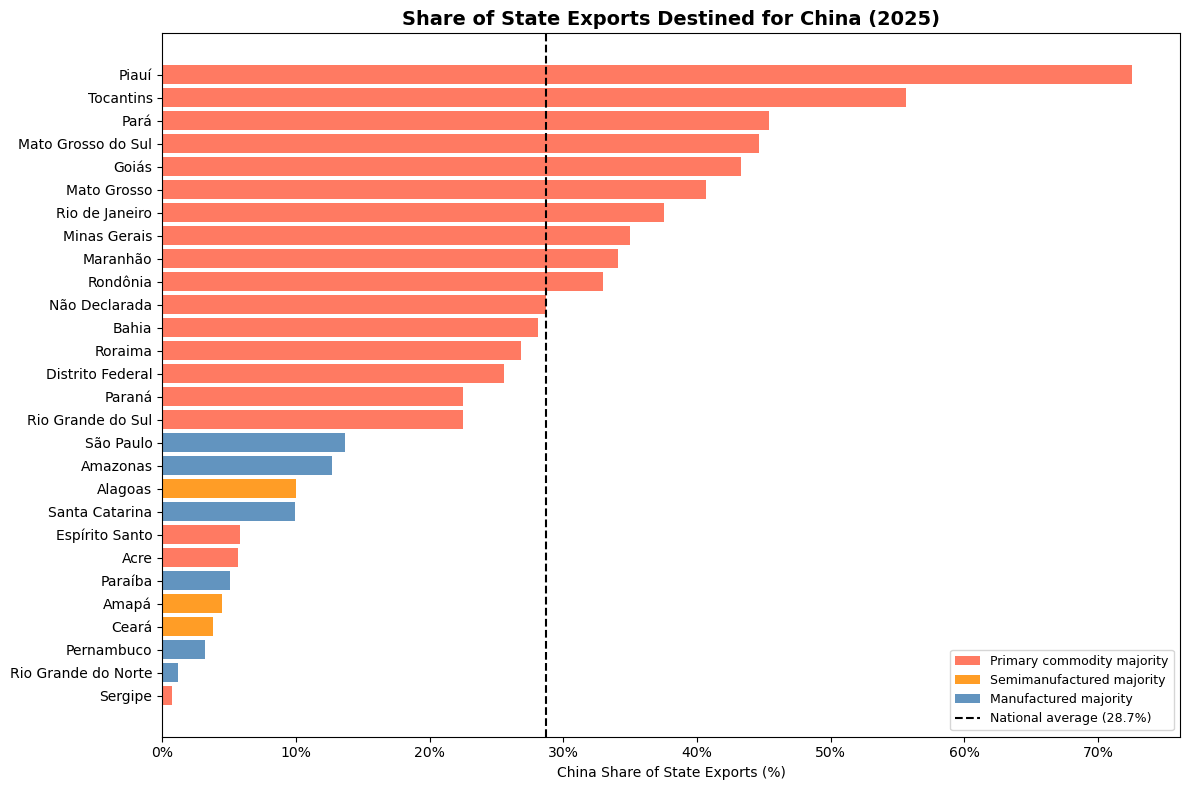

In [116]:
## ── Merge commodity classification into China share dataframe ─────────────────

## ── Diagnostic: check semimanufactured majority states ───────────────────────
df_class_check = df_fat_state_pivot[['uf', 'state', 'PRIMARY COMMODITIES', 
                                      'SEMIMANUFACTURED', 'MANUFACTURED']].copy()

def classify_state_full(row):
    primary      = row['PRIMARY COMMODITIES']
    semi         = row['SEMIMANUFACTURED']
    manufactured = row['MANUFACTURED']
    dominant     = max(primary, semi, manufactured)
    if dominant == primary:
        return 'commodity'
    elif dominant == semi:
        return 'semimanufactured'
    else:
        return 'industrial'

df_class_check['export_type'] = df_class_check.apply(classify_state_full, axis=1)

## ── Classification including semimanufactured ─────────────────────────────────
df_class = df_fat_state_pivot[['uf', 'PRIMARY COMMODITIES',
                                'SEMIMANUFACTURED', 'MANUFACTURED']].copy()
df_class['export_type'] = df_class.apply(classify_state_full, axis=1)

## Merge classification into China share plot dataframe
df_china_plot = df_china_share.sort_values('china_share_%', ascending=True)
df_china_plot = df_china_plot.merge(df_class[['uf', 'export_type']], on='uf', how='left')

## Colours consistent with cell 2.10
color_map = {
    'commodity':        'tomato',
    'semimanufactured': 'darkorange',
    'industrial':       'steelblue',
}
bar_colors = df_china_plot['export_type'].map(color_map).fillna('lightgrey')

## ── Plot ──────────────────────────────────────────────────────────────────────
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(df_china_plot['state'], df_china_plot['china_share_%'],
        color=bar_colors, alpha=0.85)

ax.axvline(x=28.7, color='black', linestyle='--', linewidth=1.5)

legend_elements = [
    Patch(facecolor='tomato',     alpha=0.85, label='Primary commodity majority'),
    Patch(facecolor='darkorange', alpha=0.85, label='Semimanufactured majority'),
    Patch(facecolor='steelblue',  alpha=0.85, label='Manufactured majority'),
    plt.Line2D([0], [0], color='black', linestyle='--', linewidth=1.5,
               label='National average (28.7%)'),
]
ax.legend(handles=legend_elements, fontsize=9)

ax.set_title(f"Share of State Exports Destined for China ({MAX_YEAR})",
             fontsize=14, fontweight='bold')
ax.set_xlabel("China Share of State Exports (%)")
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

plt.tight_layout()
plt.savefig('output_2_9_china_dependency.png', dpi=150)
plt.show()

#### Overview

China absorbs 28.7% of Brazil's national exports — but this average conceals a range from 0.7% (Sergipe) to 72.5% (Piauí) across the 27 states. Ten states are above the national average and 17 are below it. The states above the average are almost exclusively commodity interior states — mineral extraction and agricultural frontier states whose export baskets are structurally aligned with Chinese import demand. The states below the average are predominantly industrialised or coastal states with more diversified destination markets.

Every state above the 28.7% national average is classified as a primary commodity exporter. The separation is exact — no semimanufactured or manufactured majority state exceeds the national average China share. The commodity interior states — Piauí (72.5%), Tocantins (55.6%), Pará (45.4%), Mato Grosso do Sul (44.6%), Goiás (43.3%), Mato Grosso (40.7%) — send between 40% and 73% of their exports to a single destination market.
The three semimanufactured majority states — Alagoas (61.8% semimanufactured), Ceará (58.7%), and Amapá (60.2%) — occupy the lower half of the China share ranking at 10.5%, 3.8%, and 4.6% respectively. Their below-average China dependency is structurally consistent with their product profiles: semimanufactured goods, including steel billets and processed intermediates, access a broader set of destination markets than primary commodities but do not reach the full destination diversification of manufactured goods exporters. Ceará's position is particularly notable given its 55.6% year-on-year export growth in 2025, confirmed at NCM level as semi-finished steel billets — a state whose rapid export expansion is occurring entirely outside the China demand channel.

The manufactured majority states — São Paulo (13.7%), Amazonas (13.1%), Santa Catarina (9.8%), Pernambuco (3.2%), Paraíba (4.5%), and Rio Grande do Sul (22.6%) — cluster at the lower end of the China share ranking. Their export revenues are distributed across North America, Europe, Latin America, and Asia, with no single buyer accounting for a dominant share.

The full commodity-industrial classification for all 27 states — including the 1997 to 2025 structural shift from 56.0% manufactured to 28.7% — is covered in Section 2.10.

---

#### States Above the National Average (28.7%)

| State | To China (\\$bn) | Total Exports (\\$bn) | China Share |
|---|---|---|---|
| Piauí | \\$0.87bn | \\$1.20bn | 72.5% |
| Tocantins | \\$1.70bn | \\$3.05bn | 55.6% |
| Pará | \\$11.04bn | \\$24.34bn | 45.4% |
| Mato Grosso do Sul | \\$4.80bn | \\$10.75bn | 44.6% |
| Goiás | \\$5.83bn | \\$13.47bn | 43.3% |
| Mato Grosso | \\$12.29bn | \\$30.19bn | 40.7% |
| Rio de Janeiro | \\$18.38bn | \\$48.98bn | 37.5% |
| Minas Gerais | \\$16.06bn | \\$45.83bn | 35.0% |
| Maranhão | \\$1.71bn | \\$5.02bn | 34.1% |
| Rondônia | \\$1.02bn | \\$3.09bn | 33.0% |

**Piauí (72.5%)** — nearly three quarters of Piauí's exports go to China, almost entirely soybeans (83.4% of its soybean exports directed to China, confirmed in Section 2.7.2). Piauí has one product and one dominant buyer.

**Tocantins (55.6%)** — soybeans (78.0% China-directed) and beef (62.8% China-directed) dominate. Two agricultural commodities, one dominant buyer.

**Pará (45.4%)** — iron ore (57.3% China-directed, \\$9.01bn) defines the relationship. Pará accounts for 45.1% of Brazil's national ore exports, making it the single largest state contributor to Brazil's China iron ore trade.

**Mato Grosso do Sul (44.6%)** — pulp (56.0% China-directed, \\$1.74bn) and soybeans (84.9% China-directed, \\$2.10bn) together account for 80.0% of China-bound exports — a more diversified China profile than most agricultural states in the dataset.

**Goiás (43.3%)** — soybeans (84.6% China-directed) and beef (26.5% China-directed) dominate China-bound exports. Ferro-niobium does not appear in Goiás's top 3 exports to China (Section 2.7.2), indicating that Brazil's strategic niobium exports are routed primarily to non-Chinese destinations.

**Mato Grosso (40.7%)** — despite being Brazil's largest soybean exporter (29.5% of national total), Mato Grosso's China share (40.7%) is lower than Piauí (72.5%) or Tocantins (55.6%) because its larger and more diversified export base — cotton, maize and beef alongside soybeans — distributes destination exposure across more markets.

**Rio de Janeiro (37.5%)** — crude oil accounts for 94.5% of China-bound exports (\\$17.37bn). At \\$18.38bn total to China, Rio de Janeiro is the largest absolute state-level China export flow in the dataset.

**Minas Gerais (35.0%)** — iron ore (80.4% China-directed, \\$9.94bn) dominates, with soybeans (85.2% China-directed) and iron and steel (22.7% China-directed) secondary. Minas Gerais and Pará together account for 80.6% of Brazil's national ore exports and both route the majority of that ore to China.

**Maranhão (34.1%)** — despite having alumina (\\$1.389bn) and pulp (\\$0.710bn) in its total export mix, China-bound exports are dominated by soybeans (82.8% China-directed). The alumina and pulp sectors route to non-Chinese destinations — a divergence not visible at the state total level.

**Rondônia (33.0%)** — beef (45.7% China-directed) and soybeans (25.2% China-directed) account for the majority of China-bound exports.

---

#### States Below the National Average (28.7%)

| State | To China (\\$bn) | Total Exports (\\$bn) | China Share |
|---|---|---|---|
| Bahia | \\$3.27bn | \\$11.63bn | 28.1% |
| Roraima | \\$0.06bn | \\$0.24bn | 26.8% |
| Distrito Federal | \\$0.08bn | \\$0.32bn | 25.6% |
| Rio Grande do Sul | \\$4.84bn | \\$21.53bn | 22.5% |
| Paraná | \\$5.32bn | \\$23.65bn | 22.5% |
| São Paulo | \\$9.78bn | \\$71.39bn | 13.7% |
| Amazonas | \\$0.12bn | \\$0.94bn | 12.7% |
| Alagoas | \\$0.08bn | \\$0.82bn | 10.0% |
| Santa Catarina | \\$1.20bn | \\$12.20bn | 9.9% |
| Espírito Santo | \\$0.61bn | \\$10.51bn | 5.8% |
| Acre | \\$0.01bn | \\$0.10bn | 5.7% |
| Paraíba | \\$0.01bn | \\$0.18bn | 5.1% |
| Amapá | \\$0.01bn | \\$0.14bn | 4.5% |
| Ceará | \\$0.09bn | \\$2.28bn | 3.8% |
| Pernambuco | \\$0.08bn | \\$2.54bn | 3.2% |
| Rio Grande do Norte | \\$0.01bn | \\$1.13bn | 1.2% |
| Sergipe | \\$0.00bn | \\$0.45bn | 0.7% |

**Bahia (28.1%)** — the most diversified China-bound export profile among states. Soybeans (79.3% China-directed), pulp (60.4% China-directed) and ores (51.1% China-directed) — three distinct sectors contributing to the China relationship rather than a single commodity.

**Rio Grande do Sul (22.5%) and Paraná (22.5%)** —  are both below the national average. Rio Grande do Sul's tobacco dominance (89.9% of national exports, only 18.2% China-directed) structurally anchors its overall China share below the national average.

**São Paulo (13.7%)** — the largest exporter in the dataset directs the lowest China share among large exporters. Even within its China relationship, petroleum (\\$2.42bn) and beef (\\$2.05bn) dominate over vehicles, aerospace or machinery — confirming that China sources commodities rather than industrial goods even from Brazil's most industrialised state.

**Santa Catarina (9.9%)** — only 9.7% of its meat exports (its largest sector) go to China (Section 2.7.2), structurally anchoring the state below the national average.

**Espírito Santo (5.8%)** — the lowest China share among large exporters despite iron ore and pulp being major export sectors. As documented in Section 2.7.2, Espírito Santo routes below-average China shares in both ore (9.6%) and pulp (17.5%) — a market routing pattern that diverges from every comparable state and remains unconfirmed at destination level.

---

#### The Product Structure of China-Bound Exports

Across all states, China-bound exports are concentrated in three product categories:

1. **Soybeans** — present in the China relationship of 15+ states
2. **Iron ore** — concentrated in Minas Gerais and Pará
3. **Crude oil** — concentrated in Rio de Janeiro

China does not appear as a significant buyer of Brazil's industrial goods, aerospace products, vehicles or processed foods in any state's top China export sectors. Even in São Paulo — where vehicles, machinery and aircraft dominate total exports — China-bound exports are led by petroleum and beef. The China trade relationship is a primary commodity relationship at state level across the entire dataset.

---

#### Structural Observations

**The above/below average split maps directly onto the commodity vs industrial state typology from Section 2.4.1.** Every soybean-dominant and mineral extraction state is above the national average. Every industrialised or diversified state is below it — with Bahia (28.1%) as the only near-average state combining both profiles.

**The three largest absolute China export values — Rio de Janeiro (\\$18.38bn), Minas Gerais (\\$16.06bn) and Mato Grosso (\\$12.29bn) — together account for \\$46.73bn sent to China**, representing 46.6% of Brazil's total China exports from three states.

**São Paulo's below-average China share (13.7%) from a \\$71.39bn export base produces \\$9.78bn in absolute China exports — the fourth largest state value.** The combination of large export base and below-average China share gives São Paulo a structurally different risk profile: high absolute exposure but lower proportional dependency.

> ⚠️ *Goiás's ferro-niobium (\\$0.424bn) does not appear in its top 3 exports to China, indicating that Brazil's niobium exports route primarily to non-Chinese destinations. A partner-level query at NCM 72029300 is required to confirm the destination market distribution of Brazil's strategic niobium exports. Deferred to Step 4.*

> ⚠️ *Espírito Santo's China share of 5.8% is the lowest of any large exporter and diverges from every comparable mineral and port logistics state. The destination market composition of Espírito Santo's ore, pulp and stone exports requires a partner-level query to confirm. Deferred to Step 4.*
---
---

### 2.7.2 — What Each State Sends to China: Export Composition by SH2 Sector
Stacked horizontal bar chart showing the product composition of each state exports to China by SH2 sector — revealing whether China dependency is driven by the same products across states or reflects different sectoral profiles.

In [117]:
## Query national total exports by sector (all states, all destinations)
query_national_sector_total = f"""
    SELECT s.descricao_sh2_ing AS sector,
           SUM(e."VL_FOB") AS national_exports_usd
    FROM exp e
    JOIN ncm n ON e."CO_NCM" = n.codigo_ncm
    JOIN ncm_sh s ON n.codigo_sh6 = s.codigo_sh6
    WHERE e."CO_ANO" = {MAX_YEAR}
    GROUP BY s.descricao_sh2_ing
"""
df_national_sector_total = pd.read_sql(query_national_sector_total, engine)

## Query total exports by state AND sector (all destinations)
query_state_sector_total = f"""
    SELECT u.nome_estado AS state,
           s.descricao_sh2_ing AS sector,
           SUM(e."VL_FOB") AS total_exports_usd
    FROM exp e
    JOIN uf u ON e."SG_UF_NCM" = u.sigla
    JOIN ncm n ON e."CO_NCM" = n.codigo_ncm
    JOIN ncm_sh s ON n.codigo_sh6 = s.codigo_sh6
    WHERE e."CO_ANO" = {MAX_YEAR}
    GROUP BY u.nome_estado, s.descricao_sh2_ing
"""
df_state_sector_total = pd.read_sql(query_state_sector_total, engine)

## Rebuild df_china_sh2 if not in session scope
## This is the same query as in cell 2.7.2 — china exports by state and SH2 sector
query_china_state_sh2 = f"""
    SELECT e."SG_UF_NCM" AS uf,
           u.nome_estado AS state,
           s.descricao_sh2_ing AS sector,
           SUM(e."VL_FOB") AS exports_usd
    FROM exp e
    JOIN uf u ON e."SG_UF_NCM" = u.sigla
    JOIN ncm n ON e."CO_NCM" = n.codigo_ncm
    JOIN ncm_sh s ON n.codigo_sh6 = s.codigo_sh6
    WHERE e."CO_ANO" = {MAX_YEAR}
    AND e."CO_PAIS" = {china_code}
    GROUP BY e."SG_UF_NCM", u.nome_estado, s.descricao_sh2_ing
    ORDER BY u.nome_estado, exports_usd DESC
"""
df_china_sh2 = pd.read_sql(query_china_state_sh2, engine)
df_china_sh2['exports_usd_bn'] = df_china_sh2['exports_usd'] / 1e9


## Build df_top3_china fresh from df_china_sh2
df_top3_china = (
    df_china_sh2.groupby(['state', 'sector'], group_keys=False)
    .apply(lambda x: x.nlargest(1, 'exports_usd'))
    .groupby('state', group_keys=False)
    .apply(lambda x: x.nlargest(3, 'exports_usd'))
    .reset_index(drop=True)
)

## Merge state+sector total (denominator for % to China)
df_top3_china = df_top3_china.merge(
    df_state_sector_total[['state', 'sector', 'total_exports_usd']],
    on=['state', 'sector'],
    how='left'
)

## Merge national sector total (denominator for % of national)
df_top3_china = df_top3_china.merge(
    df_national_sector_total[['sector', 'national_exports_usd']],
    on='sector',
    how='left'
)

## Computed columns
df_top3_china['exports_usd_bn']       = (df_top3_china['exports_usd'] / 1e9).round(2)
df_top3_china['china_sector_share_%'] = (
    df_top3_china['exports_usd'] / df_top3_china['total_exports_usd'] * 100
).round(1)
df_top3_china['state_sector_share_%'] = (
    df_top3_china['total_exports_usd'] / df_top3_china['national_exports_usd'] * 100
).round(1)

## Check for unexpected NaNs after merges
nan_check = df_top3_china[
    df_top3_china['china_sector_share_%'].isna() |
    df_top3_china['state_sector_share_%'].isna()
]
if not nan_check.empty:
    print(f"Warning: {len(nan_check)} rows with NaN after merge — check sector name alignment")
    print(nan_check[['state', 'sector']].to_string())

## Sort states by total China exports descending for print order
state_order = (
    df_china_share.sort_values('exports_to_china_bn', ascending=False)['state'].tolist()
)

## Print
print(f"\nTop 3 sectors exported to China by state ({MAX_YEAR})")
print(f"Columns: To China ($bn) | % of sector sent to China | "
      f"% of national sector exports from this state\n")

for state in state_order:
    subset         = df_top3_china[df_top3_china['state'] == state]
    china_row      = df_china_share[df_china_share['state'] == state]
    if subset.empty or china_row.empty:
        continue
    total_to_china = china_row['exports_to_china_bn'].iloc[0]
    print(f"\n{state} — Total to China: ${total_to_china:.2f}bn")
    print(f"  {'Sector':<50} {'To China':>10} "
          f"{'% to China':>12} {'% of National':>15}")
    print(f"  {'-'*50} {'-'*10} {'-'*12} {'-'*15}")
    for _, row in subset.iterrows():
        print(f"  {str(row['sector'])[:50]:<50} "
              f"${row['exports_usd_bn']:.2f}bn  "
              f"{row['china_sector_share_%']:>10.1f}%"
              f"{row['state_sector_share_%']:>14.1f}%")


Top 3 sectors exported to China by state (2025)
Columns: To China ($bn) | % of sector sent to China | % of national sector exports from this state


Rio de Janeiro — Total to China: $18.38bn
  Sector                                               To China   % to China   % of National
  -------------------------------------------------- ---------- ------------ ---------------
  Mineral fuels, mineral oils, bituminous substances $17.37bn        42.6%          72.9%
  Ores, slag and ash                                 $0.92bn        59.8%           4.4%
  Nuclear reactors, boilers, machinery and mechanica $0.06bn         3.1%          13.3%

Minas Gerais — Total to China: $16.06bn
  Sector                                               To China   % to China   % of National
  -------------------------------------------------- ---------- ------------ ---------------
  Ores, slag and ash                                 $9.94bn        80.4%          35.5%
  Oil seeds and oleaginous fruits; Gra

C:\Users\e_koh\AppData\Local\Temp\ipykernel_27852\2793443487.py:50: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(1, 'exports_usd'))
C:\Users\e_koh\AppData\Local\Temp\ipykernel_27852\2793443487.py:52: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(3, 'exports_usd'))


#### Overview

The sector-level breakdown of China exports reveals that Brazil's trade relationship with China is almost entirely defined by three product categories — iron ore, soybeans, and crude oil — and that the states supplying these products send the majority of their output in each category to a single destination. The two columns below measure distinct dimensions of this dependency: the share of each sector's state exports directed to China, and the state's contribution to Brazil's national sector export total.

---

#### Iron Ore — Minas Gerais and Pará Supply China with the Majority of Their Ore

| State | To China | % of sector to China | % of national sector |
|---|---|---|---|
| Minas Gerais | \\$9.94bn | 80.4% | 35.5% |
| Pará | \\$9.01bn | 57.3% | 45.1% |

Minas Gerais and Pará together account for 80.6% of Brazil's national iron ore exports and direct 80.4% and 57.3% of their respective ore exports to China. Espírito Santo, despite contributing 8.5% of national ore exports, directs only 9.6% to China — a structurally distinct market routing that diverges from every comparable mineral state and is unconfirmed at destination level.

---

#### Soybeans — Near-Universal China Dependency Across All Exporting States

| State | To China | % of sector to China | % of national sector |
|---|---|---|---|
| Mato Grosso | \\$9.10bn | 69.1% | 29.5% |
| Goiás | \\$4.41bn | 84.6% | 11.7% |
| Paraná | \\$4.19bn | 90.3% | 10.4% |
| Rio Grande do Sul | \\$3.36bn | 95.4% | 7.9% |
| Minas Gerais | \\$2.35bn | 85.2% | 6.2% |
| Bahia | \\$1.84bn | 79.3% | 5.2% |
| Mato Grosso do Sul | \\$2.10bn | 84.9% | 5.5% |
| São Paulo | \\$1.62bn | 72.0% | 5.0% |
| Maranhão | \\$1.69bn | 82.8% | 4.6% |
| Tocantins | \\$1.27bn | 78.0% | 3.6% |

Rio Grande do Sul directs 95.4% of its soybean exports to China — the highest single-sector China dependency of any major exporting state in the dataset. Paraná at 90.3% and Goiás at 84.6% follow. No major soybean-exporting state routes less than 69% of its soybean exports to China. The national soybean export base has no material alternative to the Chinese market at the state level.

Maranhão's total export mix includes alumina (\\$1.389bn) and pulp (\\$0.710bn), but neither sector routes materially to China — its China relationship is confined to soybeans (82.8% China-directed).

---

#### Crude Oil — Rio de Janeiro Routes 42.6% to China at \\$17.37bn

Rio de Janeiro exports \\$17.37bn in mineral fuels to China (42.6% of its sector total), accounting for 72.9% of Brazil's national mineral fuels exports to all destinations. São Paulo adds \\$2.42bn (31.0% of its sector total, 13.9% of national). China is the largest single destination for Brazilian crude oil but at 42.6% the petroleum dependency is lower than the ore and soybean dependencies — reflecting a more liquid global crude oil market with multiple viable buyers.

---

#### Meat — Selective China Dependency by State

| State | To China | % of sector to China | % of national sector |
|---|---|---|---|
| Pará | \\$0.92bn | 75.5% | 4.1% |
| Tocantins | \\$0.41bn | 62.8% | 2.2% |
| Mato Grosso | \\$2.25bn | 50.4% | 14.9% |
| São Paulo | \\$2.05bn | 54.8% | 12.5% |
| Rondônia | \\$0.71bn | 45.7% | 5.2% |

Santa Catarina, despite being Brazil's largest pork exporter (34.1% of state exports at SH2 level), directs only 9.7% of its meat exports to China — the lowest China dependency among major meat-exporting states. Paraná similarly at 10.4%. Both states route the majority of their meat exports to other markets. The states with the highest meat-to-China dependency — Pará (75.5%) and Tocantins (62.8%) — are smaller exporters in absolute terms.

---

#### Pulp — Mato Grosso do Sul Routes 56.0% to China

| State | To China | % of sector to China | % of national sector |
|---|---|---|---|
| Mato Grosso do Sul | \\$1.74bn | 56.0% | 30.6% |
| Bahia | \\$0.81bn | 60.4% | 13.2% |
| Paraná | \\$0.19bn | 32.6% | 5.6% |
| Rio Grande do Sul | \\$0.28bn | 30.5% | 8.9% |
| Espírito Santo | \\$0.15bn | 17.5% | 8.5% |

Mato Grosso do Sul contributes 30.6% of Brazil's national pulp exports and directs 56.0% to China. Bahia at 60.4% and 13.2% national share presents a similar profile. Espírito Santo routes only 17.5% of its pulp to China despite contributing 8.5% of national pulp exports — consistent with its below-average China routing pattern across all sectors documented in Section 2.7.1.

---

#### Tobacco — Rio Grande do Sul Supplies 89.9% of National Exports but Routes Only 18.2% to China

Rio Grande do Sul accounts for 89.9% of Brazil's national tobacco exports — a near-monopoly position at state level. Only 18.2% of its tobacco exports go to China — one of the few major Brazilian export sectors not primarily oriented toward the Chinese market. The destination market composition of Rio Grande do Sul tobacco exports requires a partner-level query to confirm.

---

#### States with No Material China Dependency

Ceará (\\$0.09bn total to China), Sergipe (\\$0.00bn), Paraíba (\\$0.01bn), and Rio Grande do Norte (\\$0.01bn) have no material export relationship with China at current volumes. Their top sectors directed to China — salt, fish, essential oils, organic chemicals — reflect marginal flows rather than structural trade relationships.

---

#### Cross-Cutting Observations

**The % of sector to China column reveals that China dependency operates at product level, not state level.** Santa Catarina directs 87.3% of its soybean exports to China but only 9.7% of its meat exports. Minas Gerais directs 85.2% of its soybeans and 80.4% of its ore to China but only 22.7% of its iron and steel. The dependency is commodity-specific and varies materially within the same state.

**China does not appear as a significant buyer of Brazil's industrial goods in any state's top China export sectors.** Even in São Paulo — where vehicles, machinery and aircraft dominate total exports — China-bound exports are led by petroleum (\\$2.42bn) and beef (\\$2.05bn). The China trade relationship is a primary commodity relationship at state and sector level across the entire dataset.

**Cotton is a structurally distinct case.** Mato Grosso directs only 13.9% of its cotton to China despite accounting for 62.0% of Brazil's national cotton exports. The destination market composition of Brazilian cotton requires a partner-level query to identify where the remaining 86.1% is routed.

**Ferro-niobium does not appear in any state's top China export sectors.** Goiás (\\$0.424bn) and Minas Gerais (\\$2.126bn) are the two primary niobium exporters but ferro-niobium does not appear in either state's top 3 China-bound sectors — indicating that Brazil's strategic niobium exports route primarily to non-Chinese destinations.

**The % of national sector column identifies where supply chain concentration risk is highest.** For iron ore: Pará (45.1%) and Minas Gerais (35.5%) together account for 80.6% of national ore exports. For tobacco: Rio Grande do Sul alone accounts for 89.9%. These are the sectors where a state-level disruption would have a direct national export impact.

> ⚠️ *Espírito Santo routes only 9.6% of its ore exports and 17.5% of its pulp exports to China despite contributing 8.5% of national exports in both sectors. This market routing divergence from the national pattern is consistent across multiple sectors and requires destination-market analysis to confirm whether Espírito Santo serves systematically different end markets. Deferred to Step 4.*

> ⚠️ *Ferro-niobium (NCM 72029300) combined \\$2.657bn across three states does not appear in China-bound top sectors for any state. The destination market distribution of Brazil's niobium exports requires a dedicated partner-level query at NCM level. Deferred to Step 4.*

> ⚠️ *Mato Grosso routes only 13.9% of its cotton exports to China despite accounting for 62.0% of Brazil's national cotton export base. The destination market composition of Brazilian cotton exports requires a separate partner-level query to identify where the remaining 86.1% is directed.*

---
---

## 2.8 — State Trade Hub Profiles: Export and Import Fingerprint for Each State
A structured profile for each of the top 10 states combining trade volume, balance, dominant export and import sectors, and top trading partners — providing a concise fingerprint of each state trade identity.

***Note**: State trade hub profiles are presented for the top 10 states by export value, accounting for \$303.21bn (87.06%) of Brazil's total 2025 exports. States below this threshold are excluded as their individual profiles do not add analytical value beyond what is already documented in the sector and regional analyses in Sections 2.3–2.6.*

In [118]:
## Top export partner per state — no UF filter, apply to all states
query_state_partner_exp = f"""
    SELECT e."SG_UF_NCM" AS uf,
           p.nome_pais_ing AS top_export_partner,
           SUM(e."VL_FOB") AS partner_exports
    FROM exp e
    JOIN pais p ON e."CO_PAIS" = p.codigo_pais
    WHERE e."CO_ANO" = {MAX_YEAR}
    GROUP BY e."SG_UF_NCM", p.nome_pais_ing
    ORDER BY e."SG_UF_NCM", partner_exports DESC
"""

## Top import partner per state — no UF filter, apply to all states
query_state_partner_imp = f"""
    SELECT i."SG_UF_NCM" AS uf,
           p.nome_pais_ing AS top_import_partner,
           SUM(i."VL_FOB") AS partner_imports
    FROM imp i
    JOIN pais p ON i."CO_PAIS" = p.codigo_pais
    WHERE i."CO_ANO" = {MAX_YEAR}
    GROUP BY i."SG_UF_NCM", p.nome_pais_ing
    ORDER BY i."SG_UF_NCM", partner_imports DESC
"""

df_sp_exp = pd.read_sql(query_state_partner_exp, engine)
df_sp_imp = pd.read_sql(query_state_partner_imp, engine)

## Keep only top partner per state
top_exp_partner = (
    df_sp_exp.sort_values('partner_exports', ascending=False)
    .groupby('uf').first().reset_index()[['uf', 'top_export_partner']]
)
top_imp_partner = (
    df_sp_imp.sort_values('partner_imports', ascending=False)
    .groupby('uf').first().reset_index()[['uf', 'top_import_partner']]
)

## Top export sector per state (from df_exp_sectors)
top_exp_sector = (
    df_exp_sectors.groupby('uf', group_keys=False)
    .apply(lambda x: x.nlargest(1, 'exports_usd'))
    .reset_index(drop=True)[['uf', 'descricao_sh2_ing']]
    .rename(columns={'descricao_sh2_ing': 'top_export_sector'})
)

## Top import sector per state (from df_imp_sectors)
top_imp_sector = (
    df_imp_sectors.groupby('uf', group_keys=False)
    .apply(lambda x: x.nlargest(1, 'imports_usd'))
    .reset_index(drop=True)[['uf', 'descricao_sh2_ing']]
    .rename(columns={'descricao_sh2_ing': 'top_import_sector'})
)

## Assemble hub profile — use head(10) to match stated scope
df_hub = (
    df_state.head(10)[['uf', 'state', 'region',
                        'exports_usd_bn', 'imports_usd_bn', 'balance_usd_bn']]
)
df_hub = df_hub.merge(top_exp_partner, on='uf', how='left')
df_hub = df_hub.merge(top_imp_partner, on='uf', how='left')
df_hub = df_hub.merge(top_exp_sector,  on='uf', how='left')
df_hub = df_hub.merge(top_imp_sector,  on='uf', how='left')

## Print profiles
print(f"State Trade Hub Profiles ({MAX_YEAR})")
print("=" * 70)
for _, row in df_hub.iterrows():
    print(f"\n  {row['state']} ({row['uf']}) — {row['region']}")
    print(f"  {'─' * 50}")
    print(f"  Exports:              ${row['exports_usd_bn']:.2f}bn")
    print(f"  Imports:              ${row['imports_usd_bn']:.2f}bn")
    print(f"  Trade Balance:        ${row['balance_usd_bn']:.2f}bn  "
          f"({'SURPLUS' if row['balance_usd_bn'] > 0 else 'DEFICIT'})")
    print(f"  Top Export Sector:    {row['top_export_sector']}")
    print(f"  Top Import Sector:    {row['top_import_sector']}")
    print(f"  Top Export Partner:   {row['top_export_partner']}")
    print(f"  Top Import Partner:   {row['top_import_partner']}")
print("\n" + "=" * 70)

State Trade Hub Profiles (2025)

  São Paulo (SP) — Southeast
  ──────────────────────────────────────────────────
  Exports:              $71.39bn
  Imports:              $86.50bn
  Trade Balance:        $-15.11bn  (DEFICIT)
  Top Export Sector:    Sugars and sugar confectionery
  Top Import Sector:    Nuclear reactors, boilers, machinery and mechanical appliances; others
  Top Export Partner:   United States
  Top Import Partner:   China

  Rio de Janeiro (RJ) — Southeast
  ──────────────────────────────────────────────────
  Exports:              $48.98bn
  Imports:              $32.17bn
  Trade Balance:        $16.80bn  (SURPLUS)
  Top Export Sector:    Mineral fuels, mineral oils, bituminous substances; mineral waxes
  Top Import Sector:    Nuclear reactors, boilers, machinery and mechanical appliances; others
  Top Export Partner:   China
  Top Import Partner:   United States

  Minas Gerais (MG) — Southeast
  ──────────────────────────────────────────────────
  Exports:         

C:\Users\e_koh\AppData\Local\Temp\ipykernel_27852\863215494.py:41: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(1, 'exports_usd'))
C:\Users\e_koh\AppData\Local\Temp\ipykernel_27852\863215494.py:49: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(1, 'imports_usd'))


#### Overview

The state trade hub profiles combine export value, import value, trade balance, top sector and top partner into a single fingerprint for each state. The 2025 data confirms the dual economy finding from Section 2.1: a small number of commodity-exporting surplus states finance the import dependency of a larger group of industrial and coastal deficit states. Two states — São Paulo and Santa Catarina — run material deficits despite being among Brazil's largest exporters.

---

#### Surplus States — Commodity Export Base

**Mato Grosso (\\$27.57bn surplus)** and **Minas Gerais (\\$27.50bn surplus)** are the largest surplus generators in the dataset. Both export to China as their top partner while importing from China — Mato Grosso importing fertilisers (its top import sector) directly from its largest export customer. The same bilateral relationship finances both sides of Mato Grosso's trade account.

**Pará (\\$21.59bn surplus)** exports ores to China but imports mineral fuels from the United States — the only major surplus state whose top import partner is not China.

**Rio de Janeiro (\\$16.80bn surplus)** is the only large surplus state whose top export sector is petroleum. Its top export partner is China and top import partner is the United States — consistent with exporting crude oil to China while importing the capital equipment (machinery at 37.6% of imports) required for offshore oil extraction from US suppliers.

**Rio Grande do Sul (\\$8.15bn surplus)** is the only state whose top import partner is Argentina — reflecting cross-border automotive and agricultural supply chain integration with Mercosur rather than a China-dominated import profile.

**Goiás (\\$8.11bn surplus)** presents an unusual combination: top export partner China, top import sector pharmaceuticals (\\$1.94bn, 36.3% of imports). Goiás is a soybean exporter whose largest import requirement is pharmaceutical products — a profile more consistent with a domestic consumption-driven import base than an agricultural input dependency.

**Paraná (\\$3.50bn surplus)** and **Bahia (\\$2.32bn surplus)** are the smallest surplus states among the large exporters. Paraná's top import partner is China despite having a diversified agro-industrial export base — machinery and fertiliser imports from China offset a portion of its export revenues. Bahia's top import partner is the United States, with mineral fuels as its largest import sector.

---

#### Deficit States — Industrial and Coastal Import Dependency

**Santa Catarina (-\\$21.80bn deficit)** is the largest state trade deficit in the dataset — \\$33.99bn in imports against \\$12.20bn in exports. Its top export partner is the United States (meat) while its top import partner is China (machinery and electrical equipment). The scale of the deficit relative to export base remains the most unresolved finding in the dataset. Deferred to Step 4.

**São Paulo (-\\$15.11bn deficit)** is structurally distinct from Santa Catarina. Despite being Brazil's largest exporter (\\$71.39bn), São Paulo runs a deficit because its import base (\\$86.50bn) reflects the capital goods, chemicals, and pharmaceutical inputs required by its diversified industrial economy. Its top export partner is the United States — the only large state where the US rather than China is the primary export destination — and its top import partner is China. São Paulo is the clearest expression of Brazil's commodity-for-capital-goods exchange at state level: it exports sugar, meat and petroleum to multiple markets while importing machinery and industrial inputs primarily from China.

---

#### Partner Observations

**China is the top export partner for 7 of the 10 profiled states.** The United States is the top export partner for São Paulo and Santa Catarina — both states whose export profiles are led by manufactured goods and meat rather than bulk commodities. This confirms at partner level that China buys Brazil's commodities and the United States buys a broader mix including processed goods and industrial products.

**China is the top import partner for 5 of the 10 profiled states.** The United States is the top import partner for Rio de Janeiro and Pará — both states with significant petroleum and mining activity importing capital equipment — and Bahia. Argentina is the top import partner only for Rio Grande do Sul.

**Minas Gerais is the only state where China is both the top export and top import partner.** It exports iron ore and soybeans to China and imports machinery and industrial inputs from China — a fully bilateral China dependency on both sides of the trade account.

> ⚠️ *Goiás importing \\$1.94bn in pharmaceuticals (36.3% of total imports) as its largest import sector is inconsistent with an agricultural commodity state profile. The NCM-level composition of Goiás pharmaceutical imports requires Step 4 investigation to confirm whether this reflects domestic consumption, distribution hub activity, or a data classification issue.*
---
---

## 2.9 — Regional Trade Hub Profiles: What Each Macro-Region Specialises In
Aggregating the state profiles to the regional level — summarising what each of Brazil five macro-regions specialises in for both exports and imports, and identifying the key trade relationships that define each region.

***Note**: profiles are constructed from state-level trade data aggregated to region. They reflect the sum of state export and import flows and do not capture intra-regional trade.*

In [119]:
# ── Top export sector per region ─────────────────────────────────────────────
query_region_exp_sector = f"""
    SELECT u.nome_regiao AS region,
           s.descricao_sh2_ing AS top_export_sector,
           SUM(e."VL_FOB") AS exports_usd
    FROM exp e
    JOIN uf u ON e."SG_UF_NCM" = u.sigla
    JOIN ncm n ON e."CO_NCM" = n.codigo_ncm
    JOIN ncm_sh s ON n.codigo_sh6 = s.codigo_sh6
    WHERE e."CO_ANO" = {MAX_YEAR}
    AND u.nome_regiao NOT IN (
        'REGIAO NAO DECLARADA',
        'CONSUMO DE BORDO',
        'MERCADORIA NACIONALIZADA',
        'REEXPORTACAO'
    )
    GROUP BY u.nome_regiao, s.descricao_sh2_ing
    ORDER BY u.nome_regiao, exports_usd DESC
"""
# ── Top import sector per region ─────────────────────────────────────────────
query_region_imp_sector = f"""
    SELECT u.nome_regiao AS region,
           s.descricao_sh2_ing AS top_import_sector,
           SUM(i."VL_FOB") AS imports_usd
    FROM imp i
    JOIN uf u ON i."SG_UF_NCM" = u.sigla
    JOIN ncm n ON i."CO_NCM" = n.codigo_ncm
    JOIN ncm_sh s ON n.codigo_sh6 = s.codigo_sh6
    WHERE i."CO_ANO" = {MAX_YEAR}
    AND u.nome_regiao NOT IN (
        'REGIAO NAO DECLARADA',
        'CONSUMO DE BORDO',
        'MERCADORIA NACIONALIZADA',
        'REEXPORTACAO'
    )
    GROUP BY u.nome_regiao, s.descricao_sh2_ing
    ORDER BY u.nome_regiao, imports_usd DESC
"""
# ── Top export partner per region ────────────────────────────────────────────
query_region_exp_partner = f"""
    SELECT u.nome_regiao AS region,
           p.nome_pais_ing AS top_export_partner,
           SUM(e."VL_FOB") AS exports_usd
    FROM exp e
    JOIN uf u ON e."SG_UF_NCM" = u.sigla
    JOIN pais p ON e."CO_PAIS" = p.codigo_pais
    WHERE e."CO_ANO" = {MAX_YEAR}
    AND u.nome_regiao NOT IN (
        'REGIAO NAO DECLARADA',
        'CONSUMO DE BORDO',
        'MERCADORIA NACIONALIZADA',
        'REEXPORTACAO'
    )
    GROUP BY u.nome_regiao, p.nome_pais_ing
    ORDER BY u.nome_regiao, exports_usd DESC
"""
# ── Top import partner per region ────────────────────────────────────────────
query_region_imp_partner = f"""
    SELECT u.nome_regiao AS region,
           p.nome_pais_ing AS top_import_partner,
           SUM(i."VL_FOB") AS imports_usd
    FROM imp i
    JOIN uf u ON i."SG_UF_NCM" = u.sigla
    JOIN pais p ON i."CO_PAIS" = p.codigo_pais
    WHERE i."CO_ANO" = {MAX_YEAR}
    AND u.nome_regiao NOT IN (
        'REGIAO NAO DECLARADA',
        'CONSUMO DE BORDO',
        'MERCADORIA NACIONALIZADA',
        'REEXPORTACAO'
    )
    GROUP BY u.nome_regiao, p.nome_pais_ing
    ORDER BY u.nome_regiao, imports_usd DESC
"""

df_reg_exp_sec  = pd.read_sql(query_region_exp_sector,  engine)
df_reg_imp_sec  = pd.read_sql(query_region_imp_sector,  engine)
df_reg_exp_part = pd.read_sql(query_region_exp_partner, engine)
df_reg_imp_part = pd.read_sql(query_region_imp_partner, engine)

# ── Select top 1 per region ───────────────────────────────────────────────────
top_reg_exp_sec  = (df_reg_exp_sec
                    .sort_values('exports_usd', ascending=False)
                    .groupby('region', sort=False)
                    .head(1)[['region', 'top_export_sector']])

top_reg_imp_sec  = (df_reg_imp_sec
                    .sort_values('imports_usd', ascending=False)
                    .groupby('region', sort=False)
                    .head(1)[['region', 'top_import_sector']])

top_reg_exp_part = (df_reg_exp_part
                    .sort_values('exports_usd', ascending=False)
                    .groupby('region', sort=False)
                    .head(1)[['region', 'top_export_partner']])

top_reg_imp_part = (df_reg_imp_part
                    .sort_values('imports_usd', ascending=False)
                    .groupby('region', sort=False)
                    .head(1)[['region', 'top_import_partner']])

# ── Translate region names to English before merging ─────────────────────────
region_name_map = {
    'REGIAO NORDESTE'        : 'Northeast',
    'REGIAO NORTE'           : 'North',
    'REGIAO SUDESTE'         : 'Southeast',
    'REGIAO CENTRO OESTE'    : 'Center-West',
    'REGIAO SUL'             : 'South',
    'REGIAO NAO DECLARADA'   : None,
    'CONSUMO DE BORDO'       : None,
    'MERCADORIA NACIONALIZADA': None,
    'REEXPORTACAO'           : None,
}

top_reg_exp_sec['region']  = top_reg_exp_sec['region'].map(region_name_map)
top_reg_imp_sec['region']  = top_reg_imp_sec['region'].map(region_name_map)
top_reg_exp_part['region'] = top_reg_exp_part['region'].map(region_name_map)
top_reg_imp_part['region'] = top_reg_imp_part['region'].map(region_name_map)

# ── Regional totals ───────────────────────────────────────────────────────────
df_region_totals = (
    df_state[~df_state['region'].isin([
        'Undeclared', 
        'REGIAO NAO DECLARADA',
        'CONSUMO DE BORDO',
        'MERCADORIA NACIONALIZADA',
        'REEXPORTACAO'
    ])]
    .groupby('region')
    .agg(exports_usd_bn=('exports_usd_bn', 'sum'),
         imports_usd_bn=('imports_usd_bn', 'sum'),
         balance_usd_bn=('balance_usd_bn', 'sum'))
    .reset_index()
)
# ── Merge ─────────────────────────────────────────────────────────────────────
df_region_hub = df_region_totals.copy()
df_region_hub = df_region_hub.merge(top_reg_exp_sec,  on='region', how='left')
df_region_hub = df_region_hub.merge(top_reg_imp_sec,  on='region', how='left')
df_region_hub = df_region_hub.merge(top_reg_exp_part, on='region', how='left')
df_region_hub = df_region_hub.merge(top_reg_imp_part, on='region', how='left')

# ── Print ─────────────────────────────────────────────────────────────────────
print(f"Regional Trade Hub Profiles ({MAX_YEAR})")
print("=" * 70)
for _, row in df_region_hub.sort_values('exports_usd_bn', ascending=False).iterrows():
    print(f"\n  {row['region']}")
    print(f"  {'─' * 50}")
    print(f"  Exports:              ${row['exports_usd_bn']:.2f}bn")
    print(f"  Imports:              ${row['imports_usd_bn']:.2f}bn")
    print(f"  Trade Balance:        ${row['balance_usd_bn']:.2f}bn  "
          f"({'SURPLUS' if row['balance_usd_bn'] > 0 else 'DEFICIT'})")
    print(f"  Top Export Sector:    {row['top_export_sector']}")
    print(f"  Top Import Sector:    {row['top_import_sector']}")
    print(f"  Top Export Partner:   {row['top_export_partner']}")
    print(f"  Top Import Partner:   {row['top_import_partner']}")
print("\n" + "=" * 70)

Regional Trade Hub Profiles (2025)

  Southeast
  ──────────────────────────────────────────────────
  Exports:              $176.71bn
  Imports:              $150.81bn
  Trade Balance:        $25.89bn  (SURPLUS)
  Top Export Sector:    Mineral fuels, mineral oils, bituminous substances; mineral waxes
  Top Import Sector:    Nuclear reactors, boilers, machinery and mechanical appliances; others
  Top Export Partner:   China
  Top Import Partner:   China

  South
  ──────────────────────────────────────────────────
  Exports:              $57.38bn
  Imports:              $67.52bn
  Trade Balance:        $-10.15bn  (DEFICIT)
  Top Export Sector:    Meat and edible meat offal
  Top Import Sector:    Nuclear reactors, boilers, machinery and mechanical appliances; others
  Top Export Partner:   China
  Top Import Partner:   China

  Center-West
  ──────────────────────────────────────────────────
  Exports:              $54.73bn
  Imports:              $12.95bn
  Trade Balance:        $41.7

#### Overview

At regional level the trade structure confirms the dual economy finding from Section 2.3: Center-West and North generate large surpluses through commodity exports while the South and Northeast run deficits. The Southeast remains the dominant region on both sides of the trade account. China is the top export partner for all five regions — and the top import partner for four of the five.

| Region | Exports | Imports | Balance |
|---|---|---|---|
| Southeast | \\$176.71bn | \\$150.81bn | +\\$25.89bn |
| South | \\$57.38bn | \\$67.52bn | -\\$10.15bn |
| Center-West | \\$54.73bn | \\$12.95bn | +\\$41.78bn |
| North | \\$31.90bn | \\$21.75bn | +\\$10.16bn |
| Northeast | \\$25.25bn | \\$27.18bn | -\\$1.92bn |

---

#### Center-West — Largest Surplus at \\$41.78bn

The largest regional surplus in the dataset despite being the third largest export region. Soybeans dominate exports, fertilisers dominate imports — the agricultural surplus is generated on a narrow commodity base with a direct input dependency. China is both the top export and top import partner. The pharmaceutical products import observation from Section 2.8 (Goiás) surfaces at regional level as the top import sector — requiring
NCM-level confirmation in Step 4.

#### North — Surplus of \\$10.16bn on a Mineral Extraction Base

Ores and slag dominate exports with China as the top export resource. The top import sector is electrical machinery — driven by Amazonas (Zona Franca) rather than by mineral extraction input requirements. China is both the top export and import partner, consistent with the iron ore and manufacturing component flows documented in Sections 2.5.1 and 2.7.1.

#### Southeast — Surplus of \\$25.89bn but Structurally Distinct

The largest region on both sides of the trade account. Mineral fuels (petroleum) lead exports and machinery leads imports — the same crude-for-capital-goods exchange documented at state level for Rio de Janeiro in Section 2.8. China is both the top export and import partner at regional level, though São Paulo's top export partner is the United States (Section 2.8) — the regional aggregate is pulled toward China by Rio de Janeiro's \\$18.38bn crude oil flow.

#### South — Only Large Region in Deficit at -\\$10.15bn

Meat leads exports and machinery leads imports. China is the top export and import partner despite Santa Catarina's top export partner being the United States (Section 2.8) — Rio Grande do Sul and Paraná's China-directed soybean flows dominate the regional export aggregate. The -\\$10.15bn deficit is driven entirely by Santa Catarina's -\\$21.80bn state deficit, which offsets the surpluses of Paraná (+\\$3.50bn) and Rio Grande do Sul (+\\$8.15bn). Without Santa Catarina the South region would be in surplus.

#### Northeast — Marginal Deficit of -\\$1.92bn with a Distinct Import Partner

The only region whose top import partner is the United States rather than China. Soybeans lead exports (driven by MATOPIBA expansion in Piauí and Maranhão) and mineral fuels lead imports — the latter reflecting petroleum product imports through Nordeste ports rather than industrial capital goods. The United States as top import partner is consistent with petroleum product and machinery sourcing patterns for the region's oil and industrial activity.

---

#### Cross-Cutting Observations

**China is the top export partner for all five regions** — the only universal partner finding in the dataset. No region has diversified its export destination base away from China as its primary buyer.

**China is the top import partner for four of five regions.** The Northeast is the sole exception — its import profile is oriented toward the United States, reflecting energy and industrial input sourcing distinct from the capital goods and electronics imports that make China the dominant import partner elsewhere.

**The South deficit is a Santa Catarina effect.** Removing Santa Catarina's -\\$21.80bn deficit from the South regional total produces a regional surplus of approximately +\\$11.65bn — transforming the South from deficit to the second largest surplus region. This single state drives the entire regional trade position.

**Machinery (SH84) is the top import sector for three of five regions** — Southeast, South and Center-West. This confirms at regional level the national finding from Section 2.5.2: Brazil's import dependency on industrial capital goods is consistent across its most economically active regions regardless of their export profile.

> ⚠️ *Center-West top import sector is pharmaceutical products rather than fertilisers at regional level — driven by Goiás (\\$1.94bn, 36.3% of state imports). This is inconsistent with an agricultural commodity region profile and requires NCM-level investigation in Step 4 to confirm whether this reflects domestic consumption, distribution activity, or a classification issue.*

---
---

## 2.10 — Commodities vs Processed Products
Classifying Brazilian exports into primary commodities, semi-manufactured, and manufactured goods — examined at state, regional, and national level to quantify how Brazil's export composition has shifted from 1997 to 2025.

### 2.10.1 Commodities vs Processed Products by State and Region
Export composition breakdown by product type for each state and macro-region — identifying which states export primarily raw commodities and which have a meaningful manufactured goods share.

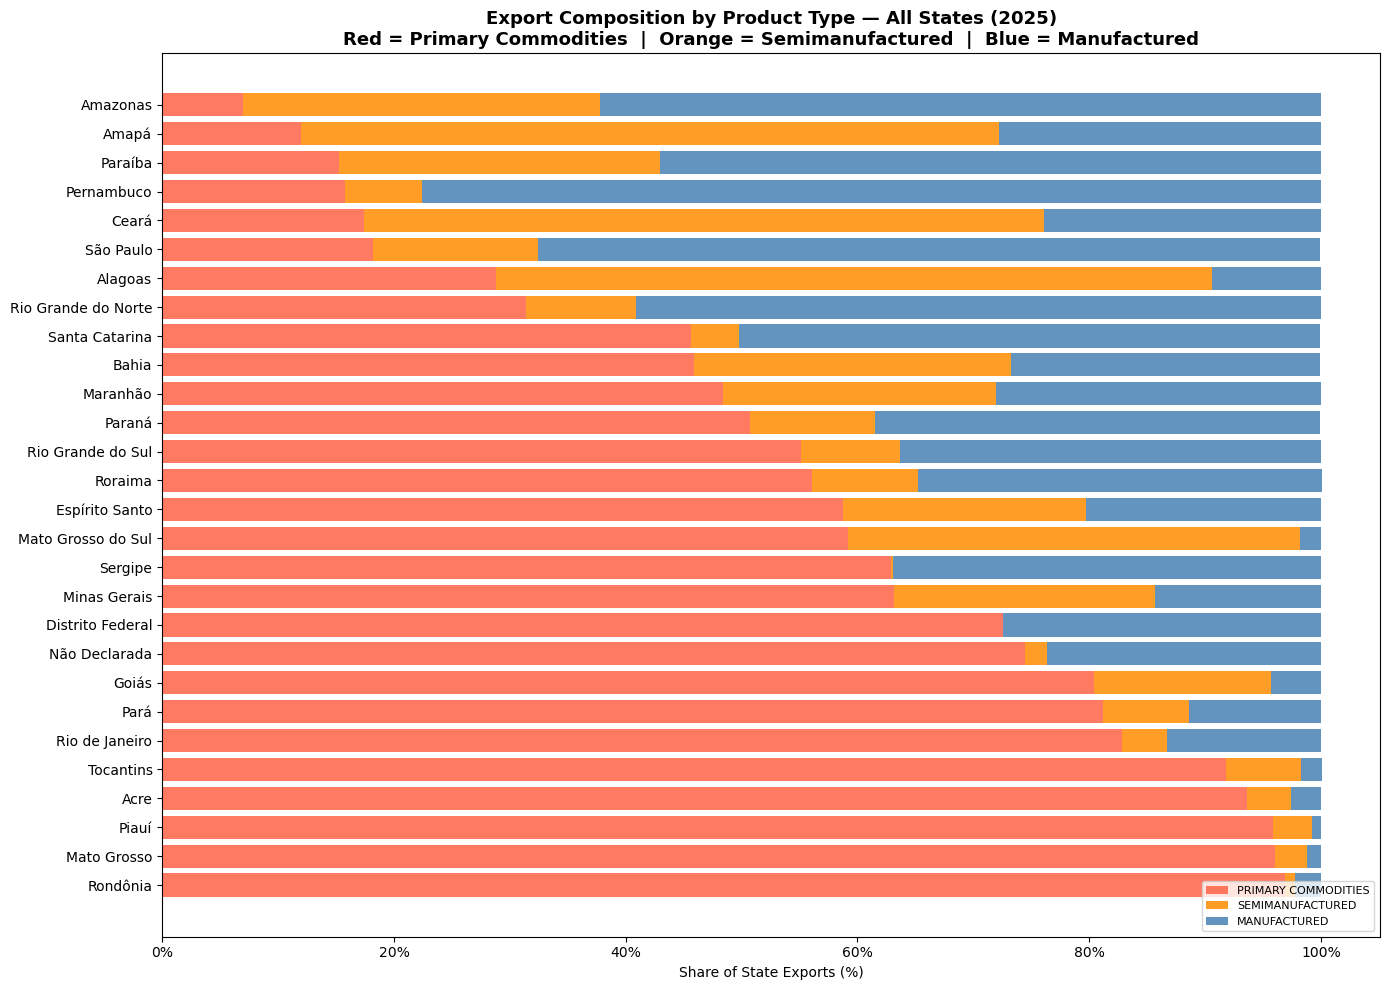

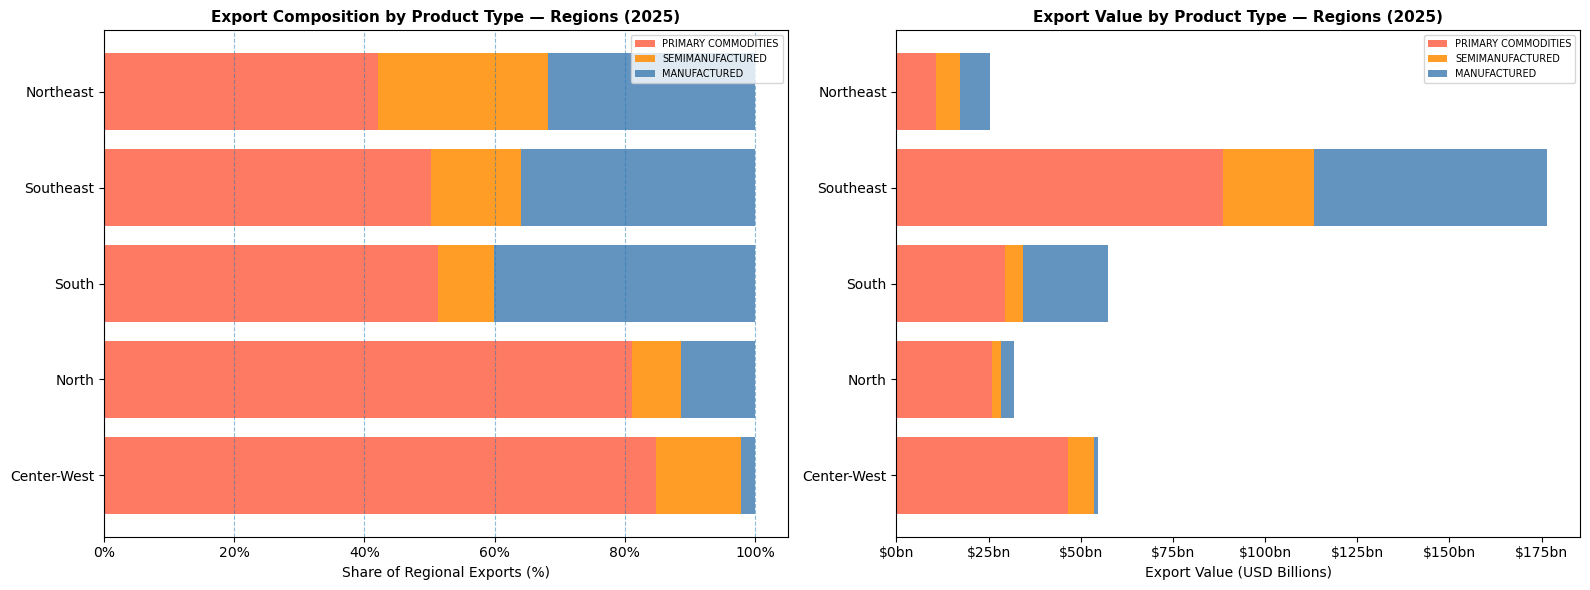

In [120]:
# ── Label mapping ─────────────────────────────────────────────────────────────
category_labels = {
    'PRODUTOS BASICOS':           'PRIMARY COMMODITIES',
    'PRODUTOS SEMIMANUFATURADOS': 'SEMIMANUFACTURED',
    'PRODUTOS MANUFATURADOS':     'MANUFACTURED',
    'TRANSACOES ESPECIAIS':       'TRANSACOES ESPECIAIS',  # keep or rename as needed
}

## ---- Brazil national totals by category ----
query_fat_national = f"""
    SELECT f.categoria_detalhada AS category,
           SUM(e."VL_FOB") AS exports_usd
    FROM exp e
    JOIN ncm n ON e."CO_NCM" = n.codigo_ncm
    JOIN ncm_fat_agreg f ON n.codigo_grupo_agregado = f.codigo_fat_agreg
    WHERE e."CO_ANO" = {MAX_YEAR}
    AND f.codigo_fat_agreg IN (1, 2, 3, 4)
    GROUP BY f.categoria_detalhada
    ORDER BY exports_usd DESC
"""

df_fat_national = pd.read_sql(query_fat_national, engine)
df_fat_national['category'] = df_fat_national['category'].map(category_labels).fillna(df_fat_national['category'])
df_fat_national['exports_usd_bn'] = (df_fat_national['exports_usd'] / 1e9).round(2)
df_fat_national['share_%'] = (
    df_fat_national['exports_usd'] / df_fat_national['exports_usd'].sum() * 100
).round(1)

## ---- By state ----
query_fat_state = f"""
    SELECT e."SG_UF_NCM" AS uf,
           u.nome_estado AS state,
           u.nome_regiao AS region,
           f.categoria_detalhada AS category,
           SUM(e."VL_FOB") AS exports_usd
    FROM exp e
    JOIN uf u ON e."SG_UF_NCM" = u.sigla
    JOIN ncm n ON e."CO_NCM" = n.codigo_ncm
    JOIN ncm_fat_agreg f ON n.codigo_grupo_agregado = f.codigo_fat_agreg
    WHERE e."CO_ANO" = {MAX_YEAR}
    AND f.codigo_fat_agreg IN (1, 2, 3, 4)
    GROUP BY e."SG_UF_NCM", u.nome_estado, u.nome_regiao, f.categoria_detalhada
    ORDER BY e."SG_UF_NCM", exports_usd DESC
"""

df_fat_state = pd.read_sql(query_fat_state, engine)
df_fat_state['category'] = df_fat_state['category'].map(category_labels).fillna(df_fat_state['category'])
df_fat_state['region']   = df_fat_state['region'].map(region_name_map).fillna(df_fat_state['region'])
df_fat_state['exports_usd_bn'] = (df_fat_state['exports_usd'] / 1e9).round(3)

## State totals for share calculation
state_totals = df_fat_state.groupby('uf')['exports_usd'].sum().rename('state_total')
df_fat_state = df_fat_state.join(state_totals, on='uf')
df_fat_state['share_%'] = (df_fat_state['exports_usd'] / df_fat_state['state_total'] * 100).round(1)

## Pivot: rows=states, columns=categories
df_fat_state_pivot = df_fat_state.pivot_table(
    index=['uf', 'state', 'region'],
    columns='category',
    values='share_%',
    aggfunc='sum'
).fillna(0).reset_index()

## Sort by PRIMARY COMMODITIES share descending
if 'PRIMARY COMMODITIES' in df_fat_state_pivot.columns:
    df_fat_state_pivot = df_fat_state_pivot.sort_values('PRIMARY COMMODITIES', ascending=False)

## ---- Stacked bar chart by state ----
categories  = ['PRIMARY COMMODITIES', 'SEMIMANUFACTURED', 'MANUFACTURED', 'TRANSACOES ESPECIAIS']
cat_colors  = ['tomato', 'darkorange', 'steelblue', 'lightgray']
cat_present = [c for c in categories if c in df_fat_state_pivot.columns]

fig, ax = plt.subplots(figsize=(14, 10))
bottom = np.zeros(len(df_fat_state_pivot))
for cat, color in zip(cat_present, cat_colors[:len(cat_present)]):
    ax.barh(df_fat_state_pivot['state'], df_fat_state_pivot[cat],
            left=bottom, label=cat, color=color, alpha=0.85)
    bottom += df_fat_state_pivot[cat].values

ax.set_title(f'Export Composition by Product Type — All States ({MAX_YEAR})\n'
             f'Red = Primary Commodities  |  Orange = Semimanufactured  |  Blue = Manufactured',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Share of State Exports (%)')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig('output_2_14_commodity_vs_processed_state.png', dpi=150)
plt.show()

## ---- By region ----
query_fat_region = f"""
    SELECT u.nome_regiao AS region,
           f.categoria_detalhada AS category,
           SUM(e."VL_FOB") AS exports_usd
    FROM exp e
    JOIN uf u ON e."SG_UF_NCM" = u.sigla
    JOIN ncm n ON e."CO_NCM" = n.codigo_ncm
    JOIN ncm_fat_agreg f ON n.codigo_grupo_agregado = f.codigo_fat_agreg
    WHERE e."CO_ANO" = {MAX_YEAR}
    AND f.codigo_fat_agreg IN (1, 2, 3, 4)
    GROUP BY u.nome_regiao, f.categoria_detalhada
    ORDER BY u.nome_regiao, exports_usd DESC
"""

df_fat_region = pd.read_sql(query_fat_region, engine)
df_fat_region['category'] = df_fat_region['category'].map(category_labels).fillna(df_fat_region['category'])
df_fat_region['exports_usd_bn'] = (df_fat_region['exports_usd'] / 1e9).round(2)

region_totals = df_fat_region.groupby('region')['exports_usd'].sum().rename('region_total')
df_fat_region = df_fat_region.join(region_totals, on='region')
df_fat_region['share_%'] = (df_fat_region['exports_usd'] / df_fat_region['region_total'] * 100).round(1)

## ensure region column is mapped to English before pivoting
df_fat_region['region'] = df_fat_region['region'].map(lambda x: region_name_map.get(x, x))

## drop non-geographic rows
df_fat_region = df_fat_region[~df_fat_region['region'].isin([
    'REGIAO NAO DECLARADA',
    'CONSUMO DE BORDO',
    'MERCADORIA NACIONALIZADA',
    'REEXPORTACAO',
    'Undeclared'
])]

df_fat_region_pivot = df_fat_region.pivot_table(
    index='region', columns='category', values='share_%', aggfunc='sum'
).fillna(0)

if 'PRIMARY COMMODITIES' in df_fat_region_pivot.columns:
    df_fat_region_pivot = df_fat_region_pivot.sort_values('PRIMARY COMMODITIES', ascending=False)

df_fat_region_pivot = df_fat_region.pivot_table(
    index='region', columns='category', values='share_%', aggfunc='sum'
).fillna(0)
if 'PRIMARY COMMODITIES' in df_fat_region_pivot.columns:
    df_fat_region_pivot = df_fat_region_pivot.sort_values('PRIMARY COMMODITIES', ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

## Regional percentage share
bottom = np.zeros(len(df_fat_region_pivot))
for cat, color in zip(cat_present, cat_colors[:len(cat_present)]):
    if cat in df_fat_region_pivot.columns:
        ax1.barh(df_fat_region_pivot.index, df_fat_region_pivot[cat],
                 left=bottom, label=cat, color=color, alpha=0.85)
        bottom += df_fat_region_pivot[cat].values

# Add 20% vertical reference lines
for x in np.arange(0, 101, 20):
    ax1.axvline(x=x, linestyle='--', linewidth=0.8, alpha=0.5)

ax1.set_title(f'Export Composition by Product Type — Regions ({MAX_YEAR})',
              fontsize=11, fontweight='bold')
ax1.set_xlabel('Share of Regional Exports (%)')
ax1.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax1.legend(fontsize=7)

## Regional absolute value
df_fat_region_abs = df_fat_region.pivot_table(
    index='region', columns='category', values='exports_usd_bn', aggfunc='sum'
).fillna(0)
if 'PRIMARY COMMODITIES' in df_fat_region_abs.columns:
    df_fat_region_abs = df_fat_region_abs.reindex(df_fat_region_pivot.index)
bottom2 = np.zeros(len(df_fat_region_abs))
for cat, color in zip(cat_present, cat_colors[:len(cat_present)]):
    if cat in df_fat_region_abs.columns:
        ax2.barh(df_fat_region_abs.index, df_fat_region_abs[cat],
                 left=bottom2, label=cat, color=color, alpha=0.85)
        bottom2 += df_fat_region_abs[cat].values
ax2.set_title(f'Export Value by Product Type — Regions ({MAX_YEAR})',
              fontsize=11, fontweight='bold')
ax2.set_xlabel('Export Value (USD Billions)')
ax2.xaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0fbn'))
ax2.legend(fontsize=7)

plt.tight_layout()
plt.savefig('output_2_14b_commodity_vs_processed_region.png', dpi=150)
plt.show()

#### Overview

Brazil's 2025 export composition is dominated by primary commodities at 58.2% (\\$202.71bn), with manufactured goods at 28.7% (\\$99.79bn) and semimanufactured at 13.1% (\\$45.65bn). The structural reversal from 1997 — when manufactured goods accounted for 56.0% — is documented in Section 2.10.2.

---

#### State-Level Composition

The state chart reveals a clear geographic split between commodity-dominant and manufactured-goods states that maps directly onto the export profiles in Section 2.4.1.

**Manufactured goods above 50% of state exports:** Amazonas, Amapá, Paraíba, Pernambuco, Ceará, and São Paulo are the only states where manufactured goods (blue) account for more than half of total exports. Of these, only São Paulo and Pernambuco have material export scale — the others are small-volume states where a single manufactured category dominates a limited base.

**Semimanufactured goods dominant:** Alagoas, Rio Grande do Norte, Maranhão, Espírito Santo, and Minas Gerais show significant semimanufactured (orange) shares. Minas Gerais is the most analytically significant — its large semimanufactured share reflects iron ore pellets and ferro-alloys (semimanufactured mineral products) rather than industrial processing.

**Primary commodities above 80% of state exports:** Rondônia, Mato Grosso, Piauí, Acre, Tocantins, and Rio de Janeiro all show primary commodity shares above 80%. Rio de Janeiro's position in this group reflects crude oil classification as a primary commodity — it is not an agricultural frontier state.

---

#### Regional Composition

The regional percentage chart confirms the commodity interior vs industrial coast finding at aggregate level:

**Center-West** — the most commodity-concentrated regional profile. Primary commodities account for approximately 95% of regional exports with a negligible manufactured goods share — consistent with the soybean and beef NCM profile confirmed in Section 2.6.

**North** — primary commodities above 85%, with a small semimanufactured share reflecting alumina and ferro-alloy processing. Manufactured goods are marginal — confined to Amazonas Zona Franca volumes which are small relative to Pará's mineral extraction base.

**Northeast** — the most balanced regional profile outside the Southeast, with manufactured goods accounting for approximately 25–30% of regional exports. Ceará's semi-finished steel and Pernambuco's vehicle exports drive this share.

**South** — approximately 50% primary commodities, with a meaningful manufactured goods share driven by São Paulo-adjacent agro-industrial processing in Paraná and Rio Grande do Sul, and Santa Catarina's machinery and electrical equipment exports.

**Southeast** — the only region with a manufactured goods share approaching or exceeding primary commodities in percentage terms. However the absolute value chart is essential context: Southeast's \\$176.71bn total means even its commodity share in absolute terms (approximately \\$70–80bn) exceeds the entire export base of every other region except the South.

#### Absolute Value Context

The right-hand regional chart shows that the Southeast's manufactured goods absolute value (approximately \\$60–70bn) exceeds the entire export base of the Center-West (\\$54.73bn) and North (\\$31.90bn). The South's manufactured goods absolute value is comparable to the entire Northeast export base (\\$25.25bn). Brazil's manufactured export capacity is geographically concentrated in the Southeast and to a lesser extent the South — every other region's manufactured goods contribution is marginal in absolute terms.

> ⚠️ *Amazonas appears as a high manufactured-goods state in the percentage chart but its total export base is only \\$0.94bn — its manufactured share reflects the Zona Franca product mix on a small absolute base rather than industrial scale comparable to São Paulo or Paraná.*

### 2.10.2 Commodities vs Processed Products National Level Comparison
National-level time series showing the shift in export composition from 1997 to 2025 across the three product categories.

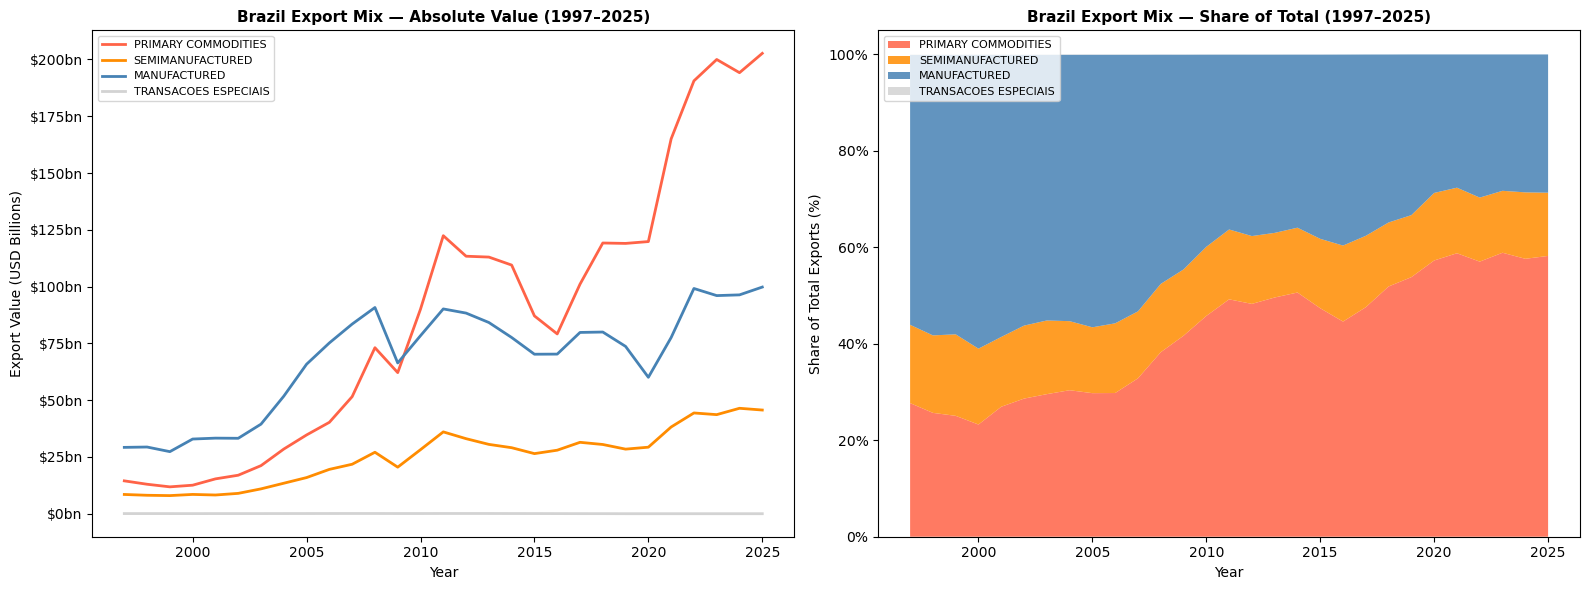

Category,1997 (%),2025 (%),Change (pp)
MANUFACTURED,56.000000,28.700000,-27.300000
PRIMARY COMMODITIES,27.700000,58.200000,30.500000
SEMIMANUFACTURED,16.200000,13.100000,-3.100000
TRANSACOES ESPECIAIS,0.100000,0.000000,-0.100000


In [121]:
## Step 1 — pre-aggregate by year and NCM code in SQL (no joins — reduces 131M rows first)
query_fat_agg = f"""
    SELECT "CO_ANO" AS year,
           "CO_NCM" AS ncm_code,
           SUM("VL_FOB") AS exports_usd
    FROM exp
    WHERE "CO_ANO" <= {MAX_YEAR}
    GROUP BY "CO_ANO", "CO_NCM"
"""
df_fat_agg = pd.read_sql(query_fat_agg, engine)

## Step 2 — load classification mapping separately (tiny tables, instant)
df_ncm_map = pd.read_sql("""
    SELECT n.codigo_ncm, f.categoria_detalhada
    FROM ncm n
    JOIN ncm_fat_agreg f ON n.codigo_grupo_agregado = f.codigo_fat_agreg
    WHERE f.codigo_fat_agreg IN (1, 2, 3, 4)
""", engine)

## Apply label mapping immediately after loading
category_labels = {
    'PRODUTOS BASICOS':           'PRIMARY COMMODITIES',
    'PRODUTOS SEMIMANUFATURADOS': 'SEMIMANUFACTURED',
    'PRODUTOS MANUFATURADOS':     'MANUFACTURED',
    'TRANSACOES ESPECIAIS':       'TRANSACOES ESPECIAIS',
}
df_ncm_map['categoria_detalhada'] = (
    df_ncm_map['categoria_detalhada'].map(category_labels).fillna(df_ncm_map['categoria_detalhada'])
)

## Step 3 — merge and aggregate in Python
df_fat_time = (
    df_fat_agg
    .merge(df_ncm_map, left_on='ncm_code', right_on='codigo_ncm', how='inner')
    .groupby(['year', 'categoria_detalhada'])['exports_usd']
    .sum()
    .reset_index()
    .rename(columns={'categoria_detalhada': 'category'})
)
df_fat_time['exports_usd_bn'] = df_fat_time['exports_usd'] / 1e9

## Step 4 — pivot and percentage
df_fat_time_pivot = df_fat_time.pivot(
    index='year', columns='category', values='exports_usd_bn'
).fillna(0)
df_fat_time_pct = df_fat_time_pivot.div(df_fat_time_pivot.sum(axis=1), axis=0) * 100

## Step 5 — charts
categories  = ['PRIMARY COMMODITIES', 'SEMIMANUFACTURED', 'MANUFACTURED', 'TRANSACOES ESPECIAIS']
cat_colors  = ['tomato', 'darkorange', 'steelblue', 'lightgray']
cat_present = [c for c in categories if c in df_fat_time_pivot.columns]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

## Absolute
for cat, color in zip(cat_present, cat_colors[:len(cat_present)]):
    if cat in df_fat_time_pivot.columns:
        ax1.plot(df_fat_time_pivot.index, df_fat_time_pivot[cat],
                 label=cat, color=color, linewidth=2)
ax1.set_title(f'Brazil Export Mix — Absolute Value (1997–{MAX_YEAR})',
              fontsize=11, fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Export Value (USD Billions)')
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0fbn'))
ax1.legend(fontsize=8)

## Percentage share
ax2.stackplot(df_fat_time_pct.index,
              [df_fat_time_pct[c] for c in cat_present if c in df_fat_time_pct.columns],
              labels=cat_present,
              colors=cat_colors[:len(cat_present)], alpha=0.85)
ax2.set_title(f'Brazil Export Mix — Share of Total (1997–{MAX_YEAR})',
              fontsize=11, fontweight='bold')
ax2.set_xlabel('Year')
ax2.set_ylabel('Share of Total Exports (%)')
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax2.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('output_2_14c_commodity_vs_processed_time.png', dpi=150)
plt.show()

## Step 6 — summary table
start = df_fat_time_pct.index[0]
summary_time = pd.DataFrame({
    'Category'        : df_fat_time_pct.columns,
    f'{start} (%)'    : df_fat_time_pct.loc[start].round(1).values,
    f'{MAX_YEAR} (%)' : df_fat_time_pct.loc[MAX_YEAR].round(1).values,
    'Change (pp)'     : (df_fat_time_pct.loc[MAX_YEAR] - df_fat_time_pct.loc[start]).round(1).values
})
display(summary_time.style
    .set_caption(f"National export mix shift — {start} vs {MAX_YEAR}")
    .set_properties(**{'text-align': 'left'})
    .hide(axis='index'))

#### Overview

Between 1997 and 2025, Brazil's export structure underwent a complete compositional reversal. Manufactured goods fell from 56.0% to 28.7% of total exports (−27.3pp), while primary commodities rose from 27.7% to 58.2% (+30.5pp). Semimanufactured goods declined modestly from 16.2% to 13.1% (−3.1pp).

The two categories did not drift — they exchanged positions. In 1997, manufactured goods were the majority; in 2025, primary commodities hold that majority by a wider margin. This is not a gradual shift at the margin but a structural reorientation of what Brazil sells to the world.

---

#### Business Implications

**Commodity price exposure.** A 58.2% primary commodity share means Brazil's aggregate export revenue is directly exposed to global commodity cycles — particularly soy, iron ore, crude oil, and beef. A sustained downturn in any two of these simultaneously would produce a material decline in national export value with limited offset from the manufactured segment.

**Value-added erosion.** Manufactured goods typically command higher and more stable margins than raw commodities. The 27.3pp decline in manufactured share represents a reduction in the value Brazil captures per unit of natural resource. 

> ⚠️ *Further investigation is necessary to identify if the processing and industrial margin is increasingly captured by importing countries rather than retained domestically.*

**China demand as the structural driver.** The commodity share expansion coincides with China's industrialisation cycle and its demand for raw material inputs. As confirmed in Section 2.7, most Brazilian state's top export partner is China, and no state's China-bound exports contain manufactured goods in meaningful volume. Brazil's structural shift is in part a response to, and now a dependency on, a single demand source for its dominant export category.

**Fertiliser import dependency as the hidden cost.** Brazil's agricultural surplus — the engine of the commodity expansion — is built on $15.49bn in annual fertiliser imports (Section 2.5). The primary commodity dominance is not self-sustaining: it requires a continuous import base to maintain output, compressing the effective trade surplus generated by the commodity sector.

**Semimanufactured stabilisation.** The semimanufactured decline (−3.1pp) is modest relative to the manufactured collapse. This category — iron ore pellets, alumina, sugar, soy oil, leather — represents partial processing that retains some value-added margin. Its relative stability suggests Brazil has maintained some intermediate processing capacity even as finished goods manufacturing declined.

> ⚠️ *The mechanism driving the post-1997 manufactured goods decline — whether exchange rate dynamics, Chinese import competition, deindustrialisation policy, or demand-side commodity pull — is not identifiable from trade flow data alone and is flagged for external validation.*

### 2.10.3 Commodities vs Processed Overview
Summary of the structural findings across state, regional, and national levels.

In [122]:
# ── State pivot ───────────────────────────────────────────────────────────────
df_state_disp = df_fat_state_pivot.copy().reset_index()

id_cols  = ['uf', 'state', 'region']
pct_cols = [c for c in df_state_disp.columns if c not in id_cols]

## coerce to numeric in case columns are stored as strings, then round
df_state_disp[pct_cols] = df_state_disp[pct_cols].apply(pd.to_numeric, errors='coerce').round(2)

display(
    df_state_disp.style
    .format({col: '{:.2f}%' for col in pct_cols})
    .set_caption(f"Export composition by product type — all states ({MAX_YEAR})")
    .set_properties(**{'text-align': 'left'})
    .hide(axis='index')
)

# ── Region pivot ──────────────────────────────────────────────────────────────
df_reg = df_fat_region_pivot.copy()

## debug: print index values before filtering to confirm exact strings
print("Index values:", df_reg.index.tolist())

df_reg = df_reg[~df_reg.index.isin([
    'REGIAO NAO DECLARADA',
    'CONSUMO DE BORDO',
    'MERCADORIA NACIONALIZADA',
    'REEXPORTACAO'
])]

## map index to English — unmapped values kept as-is instead of becoming NaN
df_reg.index = df_reg.index.map(lambda x: region_name_map.get(x, x))

df_reg = df_reg.reset_index().rename(columns={'index': 'region'})

col_map = {
    'PRIMARY COMMODITIES': 'Primary (%)',
    'MANUFACTURED'       : 'Manufactured (%)',
    'SEMIMANUFACTURED'   : 'Semi-Manufactured (%)',
}
df_reg = df_reg.rename(columns=col_map)

## explicitly identify numeric columns — exclude region column by name
pct_cols_reg = ['Manufactured (%)', 'Primary (%)', 'Semi-Manufactured (%)']

## coerce to numeric before formatting
df_reg[pct_cols_reg] = df_reg[pct_cols_reg].apply(pd.to_numeric, errors='coerce').round(2)

display(
    df_reg.style
    .format({col: '{:.2f}%' for col in pct_cols_reg})
    .set_caption(f"Export composition by product type — regions ({MAX_YEAR})")
    .set_properties(**{'text-align': 'left'})
    .hide(axis='index')
)

index,uf,state,region,MANUFACTURED,PRIMARY COMMODITIES,SEMIMANUFACTURED
21.00%,RO,Rondônia,North,2.20%,96.90%,0.90%
12.00%,MT,Mato Grosso,Center-West,1.20%,96.00%,2.80%
17.00%,PI,Piauí,Northeast,0.80%,95.90%,3.30%
0.00%,AC,Acre,North,2.60%,93.60%,3.80%
27.00%,TO,Tocantins,North,1.80%,91.80%,6.50%
19.00%,RJ,Rio de Janeiro,Southeast,13.30%,82.80%,3.90%
14.00%,PA,Pará,North,11.40%,81.20%,7.40%
8.00%,GO,Goiás,Center-West,4.30%,80.40%,15.30%
13.00%,ND,Não Declarada,REGIAO NAO DECLARADA,23.60%,74.50%,1.90%
6.00%,DF,Distrito Federal,Center-West,27.40%,72.60%,0.00%


Index values: ['Center-West', 'North', 'South', 'Southeast', 'Northeast']


region,Manufactured (%),Primary (%),Semi-Manufactured (%)
Center-West,2.20%,84.80%,13.00%
North,11.30%,81.10%,7.60%
South,40.10%,51.30%,8.60%
Southeast,35.90%,50.20%,13.90%
Northeast,31.80%,42.10%,26.10%


#### Overview

The state, regional, and national data together form a consistent picture. Brazil's export structure in 2025 is commodity-dominant at every level of aggregation, with manufactured goods concentrated in a small number of states that account for a disproportionate share of national export value.

---

#### Geographic Polarisation

At state level, the commodity-manufactured split is not a spectrum — it is a binary. Rondônia (96.9% primary), Mato Grosso (96.0%), and Piauí (95.9%) are effectively single-category exporters. At the other end, Pernambuco (77.6% manufactured), São Paulo (67.5%), and Amazonas (62.2%) are the only states where manufactured goods constitute a clear majority — and of these, only São Paulo operates at scale ($60bn+ export base).

Santa Catarina (50.1% manufactured) is the only state outside the Southeast where manufactured goods are the plurality category at meaningful export volume.

The regional aggregates confirm the split without softening it. Center-West (84.8% primary) and North (81.1% primary) are commodity regions with negligible manufactured output. The South (40.1% manufactured) and Southeast (35.9%) retain industrial capacity but their primary commodity share — 51.3% and 50.2% respectively — means commodities  are now the plurality category even in Brazil's industrial heartland.

The Northeast presents the most internally differentiated regional profile: Pernambuco and Paraíba at 77.6% and 57.0% manufactured respectively sit alongside Piauí at 95.9% primary. The regional average (31.8% manufactured, 42.1% primary) obscures a structural divide between the industrialising coastal Northeast and the commodity interior.

---

#### Business Implications

**Supplier vs processor positioning.** Brazil's national export profile is that of a raw material supplier rather than a finished goods exporter. The 58.2% primary commodity share means the majority of Brazil's export revenue is generated before any industrial transformation occurs. For companies evaluating Brazil as a manufacturing base for export, this structural context is relevant: the domestic industrial ecosystem is concentrated in São Paulo, with limited depth elsewhere.

**State-level entry point selection.** The commodity-manufactured polarisation has direct implications for market entry strategy. States above 80% primary commodity concentration (MT, RO, PI, AC, TO, RJ, PA, GO) have export economies oriented toward bulk logistics, port infrastructure, and commodity trading — not manufacturing supply chains. Companies seeking industrial partners, contract manufacturers, or value-added processing capacity should focus on SP, SC, PE, CE, and to a lesser extent PR and RS.

**The semimanufactured opportunity.** The semimanufactured category — 13.1% nationally, but reaching 61.8% in Alagoas (sugar derivatives), 60.2% in Amapá (manganese processing), and 58.7% in Ceará (steel billets) — represents partial processing that retains value within Brazil. These states are not commodity exporters in the raw sense: they are early-stage industrial processors. For investors in downstream manufacturing, semimanufactured-dominant states may offer lower input costs than fully industrialised states while providing a more developed logistics and processing base than pure commodity states.

**Minas Gerais as a structural outlier.** With 22.5% semimanufactured and 14.3% manufactured against a 63.2% primary base, Minas Gerais combines large-scale commodity extraction (iron ore) with meaningful mineral processing (iron ore pellets, ferro-alloys, ferro-niobium) and some industrial output. Its export profile is more vertically integrated than any other commodity-dominant state — relevant context for companies in metals, mining services, or heavy industrial inputs.

**Rio de Janeiro's commodity classification.** Rio de Janeiro's 82.8% primary commodity share reflects crude oil, not agricultural commodities. This distinction matters for business analysis: RJ's commodity exposure is to energy markets and oil production cycles, not to agricultural price cycles or Chinese food demand. Its trade profile is structurally different from MT or PA despite appearing in the same primary commodity tier.

> ⚠️ *The Northeast semimanufactured share (26.1% regional average) is disproportionately driven by Alagoas (sugar derivatives) and Ceará (steel billets). The regional figure should not be interpreted as broad-based processing capacity — it reflects two state-level industrial concentrations on a small aggregate base.*

---
---

## 2.11 — Unit Price (USD/kg) by State: Distinguishing Commodity vs Value-Added Exporters
Export value divided by weight (KG_LIQUIDO) gives a unit price proxy. High USD/kg indicates value-added industrial goods; low USD/kg indicates bulk commodities. Each state is benchmarked against the national average via a relative price index.

The Price Index expresses each state's export unit price as a ratio relative to the national average, scaled to 100. A value of 100 means the state's export unit price equals the national average of $0.40/kg. A value of 200 means the state exports at twice the national average; a value of 50 means at half. It allows direct comparison of relative value density across states regardless of their absolute unit price or export volume.

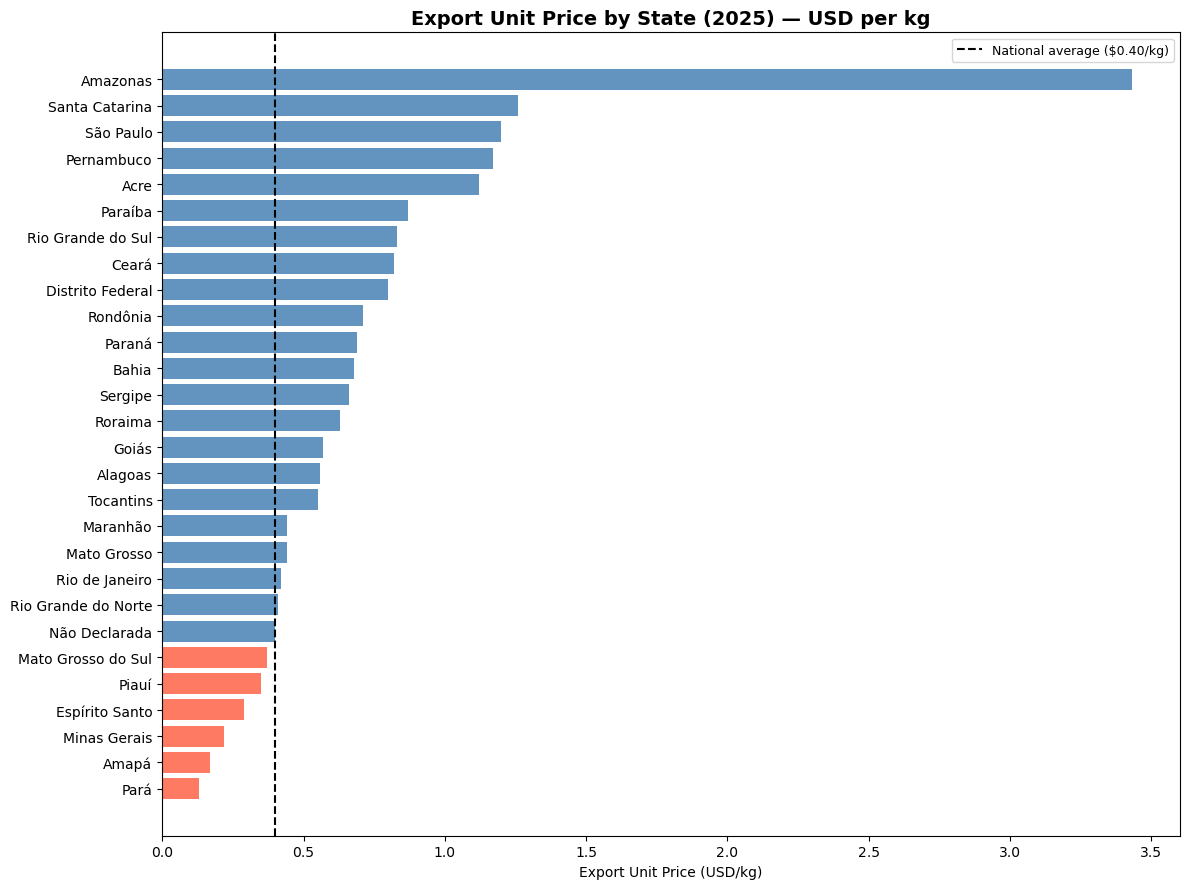


National average export unit price (2025): $0.40/kg



State,Exports (USD bn),Unit Price (USD/kg),Price Index (National = 100)
Amazonas,$0.94bn,$3.43,857.5
Santa Catarina,$12.19bn,$1.26,315.0
São Paulo,$71.29bn,$1.20,300.0
Pernambuco,$2.54bn,$1.17,292.5
Acre,$0.10bn,$1.12,280.0
Paraíba,$0.18bn,$0.87,217.5
Rio Grande do Sul,$21.53bn,$0.83,207.5
Ceará,$2.28bn,$0.82,205.0
Distrito Federal,$0.32bn,$0.80,200.0
Rondônia,$3.09bn,$0.71,177.5


In [123]:
## KG_LIQUIDO column — adjust name if error occurs
query_unit_price = f"""
    SELECT e.\"SG_UF_NCM\" AS uf,
           u.nome_estado AS state,
           SUM(e.\"VL_FOB\") AS exports_usd,
           SUM(e.\"KG_LIQUIDO\") AS total_kg
    FROM exp e
    JOIN uf u ON e.\"SG_UF_NCM\" = u.sigla
    WHERE e.\"CO_ANO\" = {MAX_YEAR}
    AND e.\"KG_LIQUIDO\" > 0
    GROUP BY e.\"SG_UF_NCM\", u.nome_estado
    ORDER BY exports_usd DESC
"""

df_unit = pd.read_sql(query_unit_price, engine)
df_unit['usd_per_kg']     = (df_unit['exports_usd'] / df_unit['total_kg']).round(2)
df_unit['exports_usd_bn'] = (df_unit['exports_usd'] / 1e9).round(2)

## National average unit price
national_usd_per_kg = (df_unit['exports_usd'].sum() / df_unit['total_kg'].sum()).round(2)

## Relative price index vs national average
df_unit['relative_price_index'] = (df_unit['usd_per_kg'] / national_usd_per_kg * 100).round(1)

df_unit_plot = df_unit.sort_values('usd_per_kg', ascending=True)
colors = ['steelblue' if x >= national_usd_per_kg else 'tomato' for x in df_unit_plot['usd_per_kg']]

fig, ax = plt.subplots(figsize=(12, 9))
ax.barh(df_unit_plot['state'], df_unit_plot['usd_per_kg'], color=colors, alpha=0.85)
ax.axvline(x=national_usd_per_kg, color='black', linestyle='--', linewidth=1.5,
           label=f'National average (${national_usd_per_kg:.2f}/kg)')
ax.set_title(f'Export Unit Price by State ({MAX_YEAR}) — USD per kg', fontsize=14, fontweight='bold')
ax.set_xlabel('Export Unit Price (USD/kg)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('output_2_17_unit_price.png', dpi=150)
plt.show()

print(f'\nNational average export unit price ({MAX_YEAR}): ${national_usd_per_kg:.2f}/kg\n')

df_unit_display = (
    df_unit[['state', 'exports_usd_bn', 'usd_per_kg', 'relative_price_index']]
    .sort_values('usd_per_kg', ascending=False)
    .copy()
)

df_unit_display = df_unit_display.rename(columns={
    'state'                : 'State',
    'exports_usd_bn'       : 'Exports (USD bn)',
    'usd_per_kg'           : 'Unit Price (USD/kg)',
    'relative_price_index' : 'Price Index (National = 100)',
})

df_unit_display['Exports (USD bn)']             = df_unit_display['Exports (USD bn)'].apply(lambda x: f'${x:.2f}bn')
df_unit_display['Unit Price (USD/kg)']          = df_unit_display['Unit Price (USD/kg)'].apply(lambda x: f'${x:.2f}')
df_unit_display['Price Index (National = 100)'] = df_unit_display['Price Index (National = 100)'].apply(lambda x: f'{x:.1f}')

display(
    df_unit_display.style
    .set_caption(f'Export Unit Price by State ({MAX_YEAR}) — National Average: ${national_usd_per_kg:.2f}/kg')
    .set_properties(**{'text-align': 'left'})
    .hide(axis='index')
)


#### Overview

The national average export unit price in 2025 is \\$0.40/kg. The range across states runs from \\$0.13/kg (Pará) to \\$3.43/kg (Amazonas) — a 26x spread. Twenty-two of the 28 states sit above the national average, but the states below it include Minas Gerais (\\$45.82bn) and Pará (\\$24.34bn) — two of Brazil's largest exporters by value. The national average is therefore pulled down by high-volume, low unit-price mineral exporters rather than being representative of a typical state's export mix.

---

**Amazonas (\\$3.43/kg, index 857.5)** is the extreme high-value outlier at 8.6x the national average on a \\$0.94bn export base. Its unit price reflects the Zona Franca de Manaus manufactured goods mix (electronics, motorcycles) rather than industrial scale comparable to São Paulo or Paraná. As noted in Section 2b.8, Amazonas is anomalous relative to its shipment size profile.

**Santa Catarina (\\$1.26/kg), São Paulo (\\$1.20/kg), and Pernambuco (\\$1.17/kg)** form Brazil's value-added export tier — all three sitting approximately 3x above the national average. Santa Catarina (\\$12.19bn) and São Paulo (\\$71.29bn) are the only large-volume states above \\$1.00/kg, confirming that value-added content translates into measurable price per kilogram at scale. Pernambuco's unit price is consistent with its 77.6% manufactured goods share — the highest of any state (Section 2.10).

**Acre (\\$1.12/kg, index 280.0)** achieves a high unit price on a negligible export base (\\$0.10bn). This reflects niche product concentration rather than industrial development at scale and should not be read alongside the SP/SC/PE figures.

**Rio Grande do Sul (\\$0.83/kg) and Ceará (\\$0.82/kg)** both sit above the national average, consistent with their diversified export profiles identified in Section 2.10.

**Rio de Janeiro (\\$0.42/kg, index 105.0)** sits marginally above the national average despite being Brazil's second largest exporter at $48.93bn — its near-average unit price is not consistent with a manufactured goods profile and should be read alongside its 82.8% primary commodity share of crude oil (Section 2.10).

**Mato Grosso (\\$0.44/kg) and Maranhão (\\$0.44/kg)** both sit at the national average despite being commodity-dominant exporters — their unit prices are higher than the mineral states below the average, consistent with the different weight and price characteristics of agricultural commodities relative to bulk minerals.

**Espírito Santo (\\$0.29/kg, index 72.5) and Minas Gerais (\\$0.22/kg, index 55.0)** are pulled below average by iron ore — a high-volume, low unit-price mineral. Minas Gerais at $45.82bn is the second largest exporter by value in this table yet records the second lowest unit price, illustrating that export value and unit price are independent dimensions.

**Pará (\\$0.13/kg, index 32.5)** records the lowest value density in Brazil. [Iron ore and copper concentrates are among the heaviest and lowest unit-price commodities in global trade](https://unctad.org/system/files/official-document/rmt2024ch1_en.pdf) — Pará's position at the bottom of this ranking is a direct function of its mineral export composition.

> ⚠️ *Unit price is a function of both product mix and weight composition. States with a high share of dense, low-value bulk minerals will mechanically record low USD/kg figures. Direct price comparisons across states with different commodity profiles should be made with this constraint in mind.*

---
---

## 2.12 — Volume vs Value Decomposition: Is State Export Growth Driven by Price or Volume?
Splitting export growth into volume (kg) and price (USD/kg) components — commodity-dependent states typically show volume-driven growth while industrial states show price-driven growth. This decomposition identifies the quality and sustainability of each state's export expansion.

This decomposition covers 2025 only. A single year cannot distinguish a cyclical fluctuation from a structural trend — a state showing volume-driven growth with price decline may be experiencing a one-year commodity price dip, or a multi-year deterioration in unit economics. Step 5 will extend this analysis across the full 1997–2025 period, producing a time series of volume and price contributions per state. This will determine whether the 2025 patterns are consistent with each state's historical profile or anomalous relative to it, and whether the volume-dominant pattern visible in 2025 is a post-2015 structural feature — which would connect directly to the regression weakening identified in Section 2b.

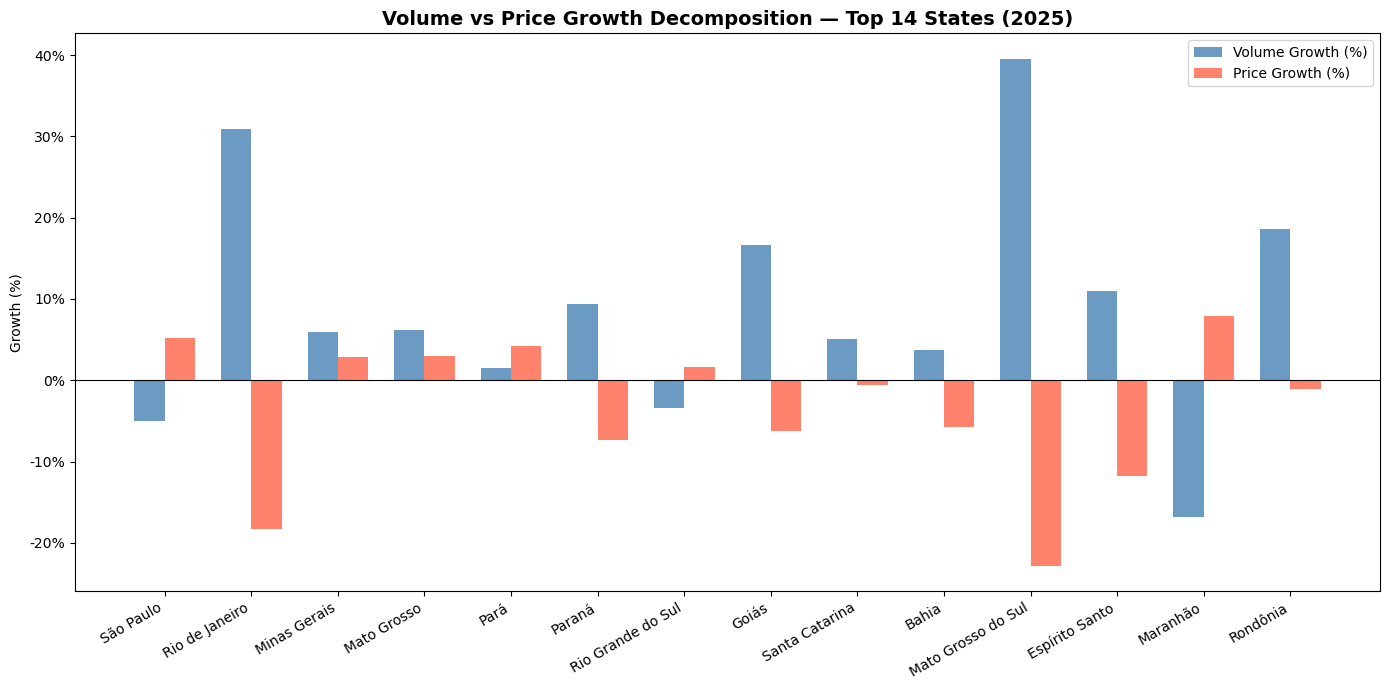

State,Export Value Growth (%),Volume Growth (%),Price Growth (%)
Ceará,+55.5%,+112.4%,-26.8%
Tocantins,+21.7%,+18.7%,+2.5%
Rondônia,+17.3%,+18.6%,-1.1%
Pernambuco,+16.8%,+11.1%,+5.1%
Acre,+13.9%,-0.1%,+14.1%
Goiás,+9.4%,+16.7%,-6.2%
Mato Grosso,+9.3%,+6.2%,+3.0%
Minas Gerais,+9.0%,+6.0%,+2.9%
Paraíba,+8.0%,+12.8%,-4.3%
Mato Grosso do Sul,+7.7%,+39.5%,-22.8%


In [124]:
query_vol_val = f"""
    SELECT e.\"CO_ANO\" AS year,
           e.\"SG_UF_NCM\" AS uf,
           SUM(e.\"VL_FOB\") AS exports_usd,
           SUM(e.\"KG_LIQUIDO\") AS total_kg
    FROM exp e
    WHERE e.\"CO_ANO\" <= {MAX_YEAR}
    AND e.\"KG_LIQUIDO\" > 0
    GROUP BY e.\"CO_ANO\", e.\"SG_UF_NCM\"
    ORDER BY e.\"SG_UF_NCM\", year
"""
df_vv = pd.read_sql(query_vol_val, engine)
df_vv = df_vv.merge(df_state[['uf', 'state']], on='uf', how='left')
df_vv['usd_per_kg'] = df_vv['exports_usd'] / df_vv['total_kg']

## YoY changes
df_vv['delta_value_%']  = df_vv.groupby('uf')['exports_usd'].pct_change() * 100
df_vv['delta_volume_%'] = df_vv.groupby('uf')['total_kg'].pct_change() * 100
df_vv['delta_price_%']  = df_vv.groupby('uf')['usd_per_kg'].pct_change() * 100

## Exclude undeclared for both chart and table
EXCLUDE_STATES = ['Não Declarada']

## Chart — top 14 states
top14_states = df_state.head(14)['state'].tolist()

df_vv_chart = df_vv[
    (df_vv['year'] == MAX_YEAR) &
    (df_vv['state'].isin(top14_states)) &
    (~df_vv['state'].isin(EXCLUDE_STATES))
][['state', 'delta_volume_%', 'delta_price_%']].dropna().set_index('state')

## preserve df_state ordering for chart
df_vv_chart = df_vv_chart.reindex(
    [s for s in top14_states if s in df_vv_chart.index]
)

x     = np.arange(len(df_vv_chart))
width = 0.35
fig, ax = plt.subplots(figsize=(14, 7))
ax.bar(x - width/2, df_vv_chart['delta_volume_%'], width, label='Volume Growth (%)', color='steelblue', alpha=0.8)
ax.bar(x + width/2, df_vv_chart['delta_price_%'],  width, label='Price Growth (%)',  color='tomato',    alpha=0.8)
ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_title(f'Volume vs Price Growth Decomposition — Top 14 States ({MAX_YEAR})', fontsize=14, fontweight='bold')
ax.set_ylabel('Growth (%)')
ax.set_xticks(x)
ax.set_xticklabels(df_vv_chart.index, rotation=30, ha='right')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('output_2_18_vol_val_decomp.png', dpi=150)
plt.show()

## Table — all states except undeclared
df_vv_latest = df_vv[
    (df_vv['year'] == MAX_YEAR) &
    (~df_vv['state'].isin(EXCLUDE_STATES))
][['state', 'delta_value_%', 'delta_volume_%', 'delta_price_%']].round(1)

## sort by export value growth descending
df_vv_latest = df_vv_latest.sort_values('delta_value_%', ascending=False)

df_vv_display = df_vv_latest.rename(columns={
    'state'          : 'State',
    'delta_value_%'  : 'Export Value Growth (%)',
    'delta_volume_%' : 'Volume Growth (%)',
    'delta_price_%'  : 'Price Growth (%)',
}).copy()

df_vv_display['Export Value Growth (%)'] = df_vv_display['Export Value Growth (%)'].apply(lambda x: f'{x:+.1f}%')
df_vv_display['Volume Growth (%)']       = df_vv_display['Volume Growth (%)'].apply(lambda x: f'{x:+.1f}%')
df_vv_display['Price Growth (%)']        = df_vv_display['Price Growth (%)'].apply(lambda x: f'{x:+.1f}%')

display(
    df_vv_display.style
    .set_caption(f'Volume vs Value Decomposition — All States ({MAX_YEAR})')
    .set_properties(**{'text-align': 'left'})
    .hide(axis='index')
)

#### Overview

Export value growth can be decomposed into two components: volume growth (more kg shipped) and price growth (higher USD/kg). The two do not always move together — a state can grow export value through volume expansion while receiving less per kg, or maintain value through price gains while shipping less.

The dominant pattern in 2025 is volume-driven growth with price decline — the majority of growing states shipped more but received less per kg. Pure price-driven growth is rare: only Acre (+14.1% price, flat volume) fits this profile cleanly at state level.

**Ceará (+112.4% volume, −26.8% price)** is the most extreme case — value growth driven entirely by a volume surge with a sharp unit price decline. Consistent with steel billet exports from CSP Pecém.
> ⚠️ *NCM-level confirmation required; deferred to Step 4.*

**Rio de Janeiro (+30.9% volume, −18.3% price)** is the most dramatic decomposition among large exporters — value growth driven entirely by volume, with a significant unit price decline.

**Amazonas (−23.3% volume, +26.2% price)** is the only state where price growth materially cushioned a volume contraction, producing a moderate net value decline.

---

#### Decomposition Pattern Summary

| Growth type | States |
|---|---|
| Volume-driven (vol dominates, price negative) | Ceará, Rio de Janeiro, Mato Grosso do Sul, Sergipe, Paraná, Goiás |
| Price-driven (price dominates, volume flat or negative) | Acre, São Paulo |
| Dual growth (both positive) | Minas Gerais, Mato Grosso, Tocantins, Pará |
| Volume growth offsetting price decline | Bahia, Espírito Santo |
| Dual decline (both negative) | Rio Grande do Sul, Piauí, Roraima |
| Volume decline offset by price gain | Amazonas, Maranhão |

Each row groups states by the combination of volume and price movement that produced their 2025 value result. A state can grow export value by shipping more (volume-driven), by receiving more per kg (price-driven), or through both moving together (dual growth). Where volume and price move in opposite directions, the larger component determines the net value outcome.

> ⚠️ *The decomposition is arithmetic — volume × price = value. It identifies the direction and relative magnitude of each component but does not explain the underlying drivers. Mechanism claims require NCM-level or external data.*
---
---

## 2.13 — Market Concentration: Top 3 Destination Share and HHI Diversification Index by State
What share of each state's exports goes to its top 3 destination countries? The Herfindahl-Hirschman Index (HHI) quantifies market concentration — a high HHI indicates dependence on few countries; a low HHI indicates diversified export markets.

Market concentration is measured by two complementary metrics. The Top 3 Share is the percentage of a state's total exports absorbed by its three largest destination markets. The HHI (Herfindahl-Hirschman Index) measures concentration across all destination markets, where 0 indicates exports distributed equally across many markets and 1 indicates a single destination. The two metrics are related but not identical: a state can have a moderate Top 3 Share but a high HHI if one partner dominates within that group.

***Note**: The following graphs are sorted by descending HHI, maintaining the state order acorss both graphs*

C:\Users\e_koh\AppData\Local\Temp\ipykernel_27852\776812552.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_top3 = df_dest.groupby('uf').apply(top3_summary).reset_index()


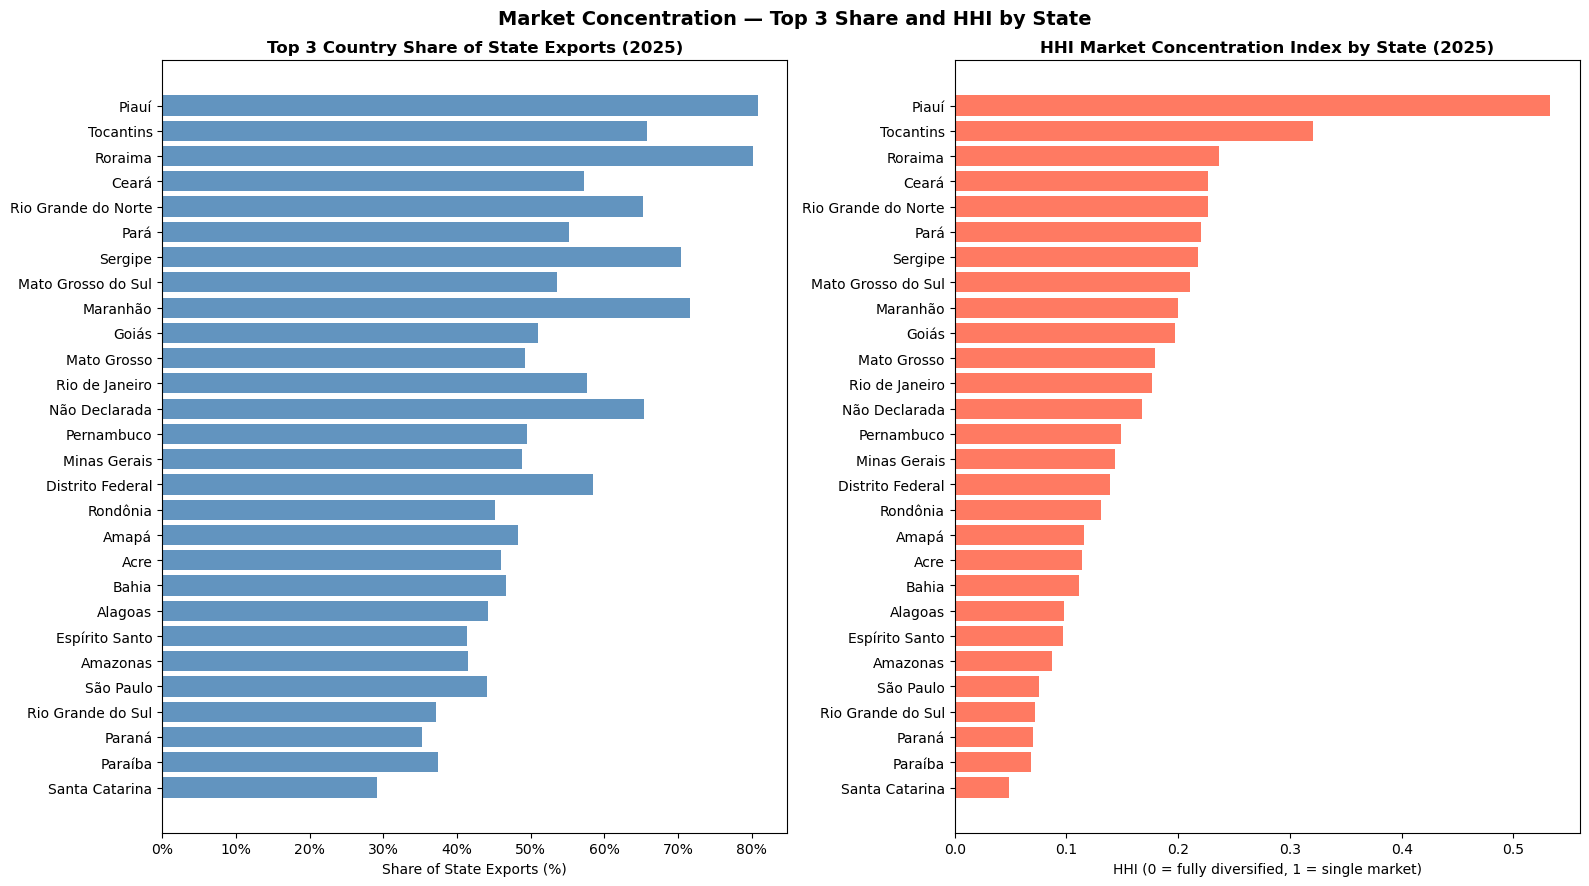

State,1st Partner,2nd Partner,3rd Partner,Top 3 Share (%),HHI
Piauí,China,Spain,Thailand,80.8%,0.5329
Roraima,Venezuela,China,Guyana,80.2%,0.2363
Maranhão,China,Canada,United States,71.6%,0.1995
Sergipe,United States,Netherlands,Spain,70.4%,0.2181
Tocantins,China,Spain,Canada,65.8%,0.3204
Não Declarada,China,United States,Netherlands,65.4%,0.1675
Rio Grande do Norte,Panama,Netherlands,Canada,65.2%,0.2268
Distrito Federal,China,Saudi Arabia,Brazil,58.4%,0.1386
Rio de Janeiro,China,United States,Spain,57.6%,0.1768
Ceará,United States,Mexico,Italy,57.2%,0.2270


In [125]:
query_top3_dest = f"""
    SELECT e."SG_UF_NCM" AS uf,
           p.nome_pais_ing AS country,
           SUM(e."VL_FOB") AS exports_usd
    FROM exp e
    JOIN pais p ON e."CO_PAIS" = p.codigo_pais
    WHERE e."CO_ANO" = {MAX_YEAR}
    GROUP BY e."SG_UF_NCM", p.nome_pais_ing
    ORDER BY e."SG_UF_NCM", exports_usd DESC
"""
df_dest = pd.read_sql(query_top3_dest, engine)

## Total exports per state
state_totals = df_dest.groupby('uf')['exports_usd'].sum().rename('total_exports')
df_dest = df_dest.join(state_totals, on='uf')
df_dest['share'] = df_dest['exports_usd'] / df_dest['total_exports']

## Top 3 share per state
def top3_summary(group):
    top = group.nlargest(3, 'exports_usd')
    countries = top['country'].tolist()
    while len(countries) < 3:
        countries.append('')
    return pd.Series({
        'top3_share_%' : round(top['share'].sum() * 100, 1),
        'top1'         : countries[0],
        'top2'         : countries[1],
        'top3'         : countries[2],
        'hhi'          : round((group['share'] ** 2).sum(), 4)
    })

df_top3 = df_dest.groupby('uf').apply(top3_summary).reset_index()
df_top3 = df_top3.merge(df_state[['uf', 'state', 'region']], on='uf', how='left')

## Sort both charts by HHI descending — identical state order across both panels
df_top3_plot = df_top3.sort_values('hhi', ascending=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 9))

## Left — Top 3 Share (same state order as HHI chart)
ax1.barh(df_top3_plot['state'], df_top3_plot['top3_share_%'],
         color='steelblue', alpha=0.85)
ax1.set_title(f'Top 3 Country Share of State Exports ({MAX_YEAR})',
              fontsize=12, fontweight='bold')
ax1.set_xlabel('Share of State Exports (%)')
ax1.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

## Right — HHI (same state order)
ax2.barh(df_top3_plot['state'], df_top3_plot['hhi'],
         color='tomato', alpha=0.85)
ax2.set_title(f'HHI Market Concentration Index by State ({MAX_YEAR})',
              fontsize=12, fontweight='bold')
ax2.set_xlabel('HHI (0 = fully diversified, 1 = single market)')

plt.suptitle('Market Concentration — Top 3 Share and HHI by State',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('output_2_19_market_concentration.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary table
df_top3_display = (
    df_top3[['state', 'top1', 'top2', 'top3', 'top3_share_%', 'hhi']]
    .sort_values('top3_share_%', ascending=False)
    .copy()
    .rename(columns={
        'state'       : 'State',
        'top1'        : '1st Partner',
        'top2'        : '2nd Partner',
        'top3'        : '3rd Partner',
        'top3_share_%': 'Top 3 Share (%)',
        'hhi'         : 'HHI',
    })
)
df_top3_display['Top 3 Share (%)'] = df_top3_display['Top 3 Share (%)'].apply(
    lambda x: f'{x:.1f}%'
)
df_top3_display['HHI'] = df_top3_display['HHI'].apply(lambda x: f'{x:.4f}')

display(
    df_top3_display.style
    .set_caption(
        f'Market Concentration — Top 3 Partner Share and HHI by State ({MAX_YEAR})'
    )
    .set_properties(**{'text-align': 'left'})
    .hide(axis='index')
)

#### Overview
The HHI and product complexity are inversely correlated. The five lowest HHI states — Santa Catarina (0.0488), Paraná (0.0697), Paraíba (0.0684), Rio Grande do Sul (0.0718), São Paulo (0.0755) — are all states with manufactured goods or diversified agro-industrial export profiles. The five highest HHI states — Piauí (0.5329), Tocantins (0.3204), Roraima (0.2363), Ceará (0.2270), Sergipe (0.2181) — are all either single-commodity states or small-volume states. This is a direct quantitative confirmation of the product-market diversification link: states that export a narrow product range also export to a narrow market range.

#### Concentration Risk — High HHI States

**Piauí (Top 3: 80.8%, HHI: 0.5329)** is the most concentrated export market in Brazil on both measures. An HHI of 0.5329 — almost double the next highest state — reflects near-single-market dependency. Combined with a primary commodity export share above 95% (Section 2.10), Piauí's export revenue is exposed to both commodity price cycles and single-partner demand simultaneously.

**Tocantins (Top 3: 65.8%, HHI: 0.3204)** is the second most concentrated state by HHI despite ranking fifth by Top 3 Share — indicating that within its top 3, China holds a disproportionate share relative to Spain and Canada.

**Roraima (Top 3: 80.2%, HHI: 0.2363)** has the second highest Top 3 Share but a materially lower HHI than Piauí, reflecting a more even distribution across Venezuela, China, and Guyana rather than single-partner dominance.

---

#### Diversification — Low HHI States

**Santa Catarina (Top 3: 29.2%, HHI: 0.0488)** and **Paraná (Top 3: 35.3%, HHI: 0.0697)** are two of the most diversified states on both measures. Santa Catarina's low HHI indicates that its large import deficit (Section 2.1.2) is not matched by export market concentration risk.

**São Paulo (Top 3: 44.1%, HHI: 0.0755)** is the most diversified large exporter by HHI. The United States is its first partner rather than China — the only large state where China is not the primary export destination — consistent with the Section 2.16 finding that the United States as first partner is concentrated in states with manufactured goods profiles rather than commodity exporters.

---

#### State-Specific Observations

**Ceará (Top 3: 57.2%, HHI: 0.2270)** — the United States is its first export partner and Italy appears in its top three, consistent with semi-finished steel billet exports (confirmed in Section 2.6) routing to European markets rather than the China-dominant commodity profile of other Northeast states.

**Espírito Santo (Top 3: 41.3%, HHI: 0.0972)** — China does not appear until third position, behind the United States and Singapore, confirming the routing divergence flagged in Sections 2.7.1 and 2.7.2.

**Pernambuco (Top 3: 49.5%, HHI: 0.1490)** — Argentina is its first export partner, consistent with vehicle exports routing to Mercosul markets confirmed in Section 2.6.

---

#### China as First Partner

China is the first export partner for 18 of 27 states. The 11 states where China is not the primary destination are: Roraima (Venezuela), Sergipe (United States), Rio Grande do Norte (Panama), Ceará (United States), Amapá (Japan), Acre (Peru), São Paulo (United States), Amazonas (Germany), Espírito Santo (United States), Paraíba (United States), and Alagoas (Canada). The United States as first partner is concentrated in states with manufactured goods, niche agricultural, or petroleum product profiles — not in commodity exporters.

> ⚠️ *Espírito Santo's routing to the United States and Singapore rather than China across ore, pulp and stone exports requires a partner-level query to confirm end markets. Deferred to Step 4.*

> ⚠️ *Rio Grande do Norte's first export partner is Panama — a transit hub rather than an end market. Final destination requires NCM-level partner analysis. Deferred to Step 4.*
---
---

## 2.14 — How Trade-Self-Sufficient Is Each State?
The coverage ratio (exports / imports) measures how much of a state's import bill is covered by its export revenues. A ratio above 1.0 indicates a net surplus state — exports exceed imports. A ratio below 1.0 indicates a net deficit state — imports exceed exports. This complements the trade balance analysis in 2.1.

### 2.14.1 — Coverage Ratio by State
Coverage ratio for every state ranked from most to least self-sufficient — identifying which states run structural trade surpluses and which are import-dependent.

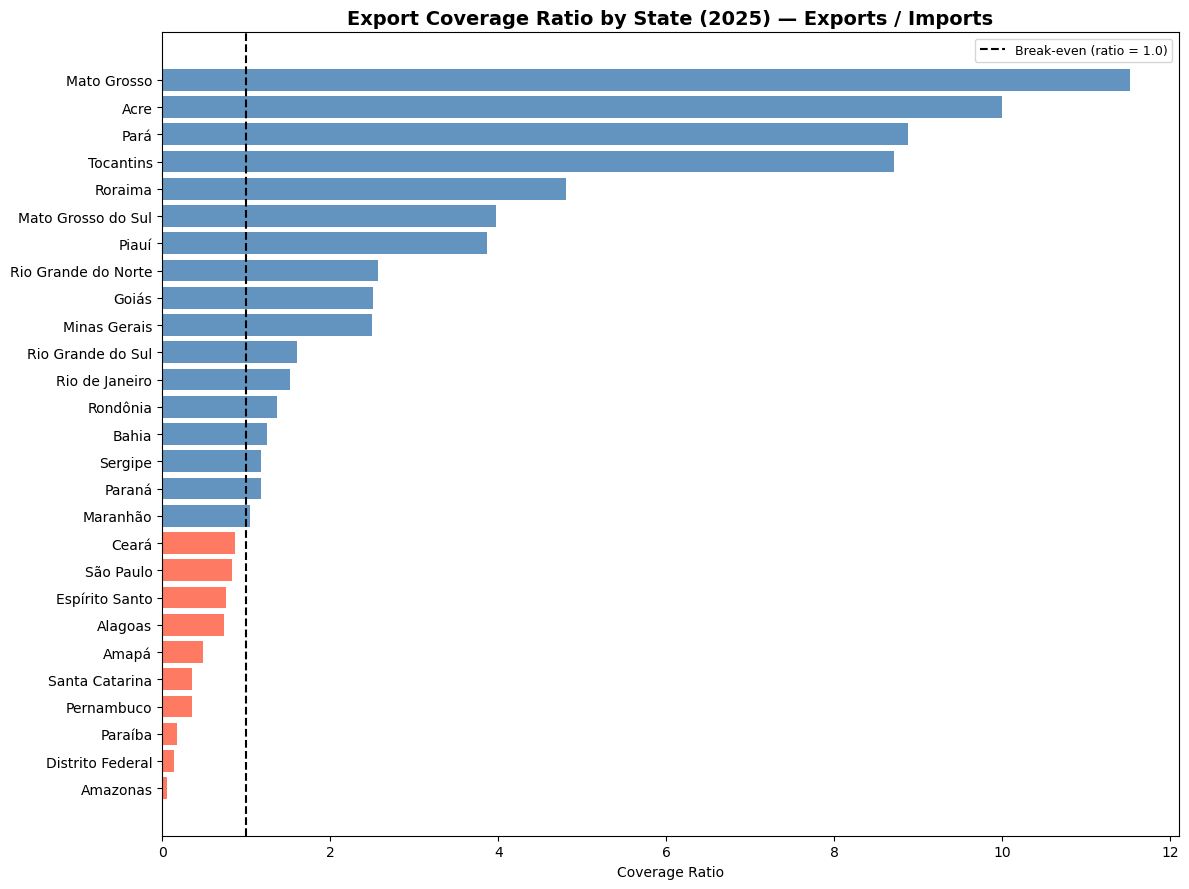

State,Region,Exports (USD bn),Imports (USD bn),Coverage Ratio
Mato Grosso,Center-West,$30.19bn,$2.62bn,11.52x
Acre,North,$0.10bn,$0.01bn,10.00x
Pará,North,$24.34bn,$2.74bn,8.88x
Tocantins,North,$3.05bn,$0.35bn,8.71x
Roraima,North,$0.24bn,$0.05bn,4.80x
Mato Grosso do Sul,Center-West,$10.75bn,$2.71bn,3.97x
Piauí,Northeast,$1.20bn,$0.31bn,3.87x
Rio Grande do Norte,Northeast,$1.13bn,$0.44bn,2.57x
Goiás,Center-West,$13.47bn,$5.36bn,2.51x
Minas Gerais,Southeast,$45.83bn,$18.33bn,2.50x


In [126]:
## Uses df_state from 2.1
df_coverage = df_state[['state', 'region', 'uf', 'exports_usd_bn', 'imports_usd_bn']].copy()
df_coverage = df_coverage[df_coverage['imports_usd_bn'] > 0]
df_coverage['coverage_ratio'] = (df_coverage['exports_usd_bn'] / df_coverage['imports_usd_bn']).round(2)

df_cov_plot = df_coverage.sort_values('coverage_ratio', ascending=True)
colors = ['steelblue' if x >= 1.0 else 'tomato' for x in df_cov_plot['coverage_ratio']]

fig, ax = plt.subplots(figsize=(12, 9))
ax.barh(df_cov_plot['state'], df_cov_plot['coverage_ratio'], color=colors, alpha=0.85)
ax.axvline(x=1.0, color='black', linestyle='--', linewidth=1.5, label='Break-even (ratio = 1.0)')
ax.set_title(f'Export Coverage Ratio by State ({MAX_YEAR}) — Exports / Imports', fontsize=14, fontweight='bold')
ax.set_xlabel('Coverage Ratio')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('output_2_20_coverage_ratio.png', dpi=150)
plt.show()

df_cov_display = (
    df_coverage[['state', 'region', 'exports_usd_bn', 'imports_usd_bn', 'coverage_ratio']]
    .sort_values('coverage_ratio', ascending=False)
    .copy()
    .rename(columns={
        'state'          : 'State',
        'region'         : 'Region',
        'exports_usd_bn' : 'Exports (USD bn)',
        'imports_usd_bn' : 'Imports (USD bn)',
        'coverage_ratio' : 'Coverage Ratio',
    })
)

df_cov_display['Exports (USD bn)'] = df_cov_display['Exports (USD bn)'].apply(lambda x: f'${x:.2f}bn')
df_cov_display['Imports (USD bn)'] = df_cov_display['Imports (USD bn)'].apply(lambda x: f'${x:.2f}bn')
df_cov_display['Coverage Ratio']   = df_cov_display['Coverage Ratio'].apply(lambda x: f'{x:.2f}x')

## Coverage Ratio by State ({MAX_YEAR})
display(
    df_cov_display.style
    .set_caption(f'Export Coverage Ratio by State ({MAX_YEAR}) — Exports / Imports')
    .set_properties(**{'text-align': 'left'})
    .hide(axis='index')
)

#### Overview

The 2025 data shows 17 states above break-even and 10 states below it.

**The coverage ratio splits cleanly along the commodity vs industrial typology** from Section 2.4.1. Every state with a coverage ratio above 2.0x is a commodity exporter — agricultural or mineral. Every state with a coverage ratio below 0.5x is either an industrial assembly economy (Amazonas), a port logistics hub (Santa Catarina), or a federal administrative centre (Distrito Federal).

**The North and Center-West regions generate the highest coverage ratios** — consistent with the regional surplus findings in Section 2.9. The Northeast is split: Piauí (3.87x) and Rio Grande do Norte (2.57x) are high-coverage commodity states while Ceará (0.87x), Alagoas (0.73x), Pernambuco (0.35x) and Paraíba (0.18x) are deficit states — confirming that the Northeast cannot be treated as a homogeneous trade region.

---

#### High Coverage — Commodity Surplus States

The states with the highest coverage ratios are without exception commodity exporters with low import requirements:

**Mato Grosso (11.52x)** generates \\$11.52 in exports for every \\$1.00 of imports — the highest coverage ratio in the dataset. Its import base of \\$2.62bn is almost entirely fertilisers (61.7%, confirmed in Section 2.5.1), making it the clearest example of a state whose export surplus is structurally dependent on a single imported input.

**Acre (10.00x)** and **Tocantins (8.71x)** post high ratios on small absolute bases — their import requirements are minimal relative to commodity export revenues. These ratios are not comparable in scale to Mato Grosso or Pará.

**Pará (8.88x)** is the most significant high-coverage state after Mato Grosso in absolute terms — \\$24.34bn in exports against \\$2.74bn in imports. Iron ore exports (45.4% to China) generate a surplus that dwarfs its mineral fuel and machinery import requirements.

**Minas Gerais (2.50x)** and **Goiás (2.51x)** are the largest surplus states by absolute value among the mid-range coverage group — \\$27.50bn and \\$8.11bn surpluses respectively.

---

#### Near Break-Even States

**Maranhão (1.05x)** is the closest state to break-even in the dataset — \\$5.02bn exports against \\$4.76bn imports. Despite appearing in the surplus category, its coverage ratio is marginal and its import profile (66.0% mineral fuels, 25.0% fertilisers) reflects high input costs relative to its export base.

**Paraná (1.17x)** and **Bahia (1.25x)** are surplus states with thin coverage margins  relative to their export scale — both states' surpluses are documented in Section 2.8.

---

#### Deficit States — Coverage Below 1.0

**Amazonas (0.06x)** has the lowest coverage ratio in the dataset — \\$0.94bn in exports against \\$16.06bn in imports. This is consistent with the [Zona Franca de Manaus industrial profile](https://www.gov.br/suframa/pt-br/assuntos/industria/) (also documented in Section 2.5.1), where electrical equipment (44.0%, \\$7.06bn) and machinery (13.9%, \\$2.23bn) dominate imports while exports are limited to \$0.94bn across a narrow product range.

**Santa Catarina (0.36x)** is the most significant deficit state in absolute terms — \\$12.20bn exports against \\$33.99bn imports, a -\\$21.80bn deficit confirmed in Section 2.1.2. Its coverage ratio of 0.36x means exports cover only 36 cents of every dollar imported — the largest absolute import financing gap of any state outside São Paulo.

**São Paulo (0.83x)** runs a deficit of -\\$15.11bn despite being Brazil's largest exporter. Its coverage ratio reflects the capital goods, chemicals, and pharmaceutical import requirements of its diversified industrial economy rather than a structural trade weakness — it is the only deficit state whose import profile is dominated by industrial inputs rather than consumer goods or assembly components.

**Pernambuco (0.35x)** and **Distrito Federal (0.14x)** have low coverage ratios driven by specific structural factors — Pernambuco's vehicle and petroleum imports relative to its export base, and Distrito Federal's pharmaceutical import concentration (82.5% of imports, confirmed in Section 2.5.1) against a minimal export base.

---

> ⚠️ *Amazonas's coverage ratio of 0.06x is structurally determined by the Zona Franca import model and is not directly comparable to other deficit states. Its export revenues (\\$0.94bn) are not intended to offset its import volumes (\\$16.06bn) under the current industrial policy framework.*
---
---

### 2.14.2 — Coverage Ratio by Region
Coverage ratio aggregated to macro-region level — showing how self-sufficiency differs across Brazil's five regions.

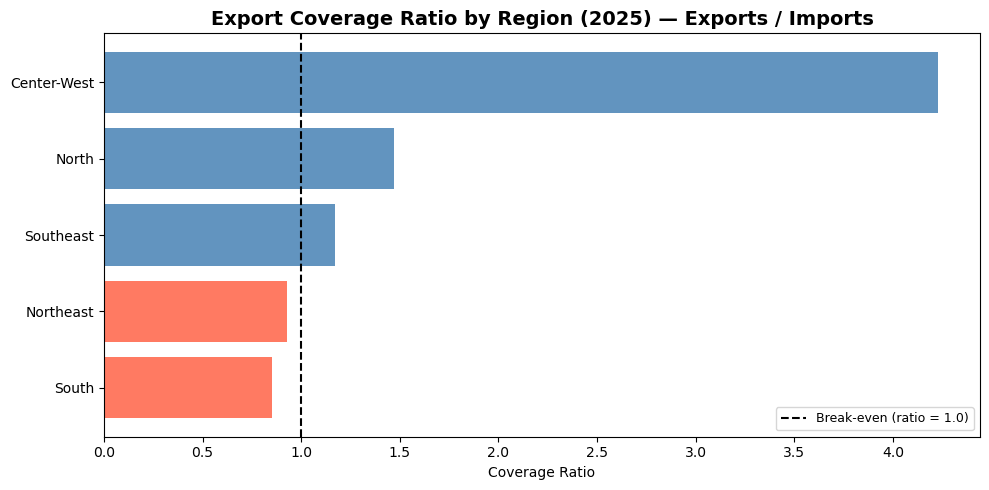

Region,Exports (USD bn),Imports (USD bn),Coverage Ratio
Center-West,$54.73bn,$12.95bn,4.23x
North,$31.90bn,$21.75bn,1.47x
Southeast,$176.71bn,$150.81bn,1.17x
Northeast,$25.25bn,$27.18bn,0.93x
South,$57.38bn,$67.52bn,0.85x


In [127]:
## Coverage ratio at regional level
df_coverage_region = (
    df_state.groupby('region')
    .agg(
        exports_usd_bn=('exports_usd_bn', 'sum'),
        imports_usd_bn=('imports_usd_bn', 'sum')
    )
    .reset_index()
)
df_coverage_region = df_coverage_region[df_coverage_region['imports_usd_bn'] > 0]
df_coverage_region['coverage_ratio'] = (
    df_coverage_region['exports_usd_bn'] / df_coverage_region['imports_usd_bn']
).round(2)

df_cov_reg_plot = df_coverage_region.sort_values('coverage_ratio', ascending=True)
colors = ['steelblue' if x >= 1.0 else 'tomato' for x in df_cov_reg_plot['coverage_ratio']]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(df_cov_reg_plot['region'], df_cov_reg_plot['coverage_ratio'],
        color=colors, alpha=0.85)
ax.axvline(x=1.0, color='black', linestyle='--', linewidth=1.5,
           label='Break-even (ratio = 1.0)')
ax.set_title(f'Export Coverage Ratio by Region ({MAX_YEAR}) — Exports / Imports',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Coverage Ratio')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('output_2_20b_coverage_ratio_region.png', dpi=150)
plt.show()

df_cov_reg_display = (
    df_coverage_region[['region', 'exports_usd_bn', 'imports_usd_bn', 'coverage_ratio']]
    .sort_values('coverage_ratio', ascending=False)
    .copy()
    .rename(columns={
        'region'         : 'Region',
        'exports_usd_bn' : 'Exports (USD bn)',
        'imports_usd_bn' : 'Imports (USD bn)',
        'coverage_ratio' : 'Coverage Ratio',
    })
)

df_cov_reg_display['Exports (USD bn)'] = df_cov_reg_display['Exports (USD bn)'].apply(lambda x: f'${x:.2f}bn')
df_cov_reg_display['Imports (USD bn)'] = df_cov_reg_display['Imports (USD bn)'].apply(lambda x: f'${x:.2f}bn')
df_cov_reg_display['Coverage Ratio']   = df_cov_reg_display['Coverage Ratio'].apply(lambda x: f'{x:.2f}x')

## Coverage Ratio by Region ({MAX_YEAR})
display(
    df_cov_reg_display.style
    .set_caption(f'Export Coverage Ratio by Region ({MAX_YEAR}) — Exports / Imports')
    .set_properties(**{'text-align': 'left'})
    .hide(axis='index')
)

#### Overview

At regional level the coverage ratio confirms the structural finding from Section 2.3: the commodity interior finances the import dependency of the coastal and industrial regions. Three regions are in surplus and two are in deficit.

**Center-West (4.23x)** generates \\$4.23 in exports for every \\$1.00 of imports — the largest regional surplus in the dataset by coverage ratio. Its \\$12.95bn import base is the smallest of any region, concentrated in fertilisers and agricultural inputs. The ratio is the regional-level expression of the Mato Grosso (11.52x) and Goiás (2.51x) state profiles documented in Section 2.14.1.

**North (1.47x)** runs a moderate surplus driven by Pará's mineral extraction base. The ratio is pulled down by Amazonas (0.06x state coverage ratio) — without Amazonas, the North regional ratio would be materially higher.

**Southeast (1.17x)** barely covers its imports at regional level. São Paulo's -\\$15.11bn state deficit nearly eliminates the combined surplus of Rio de Janeiro (\\$16.80bn) and Minas Gerais (\\$27.50bn), producing a net regional surplus of only \\$25.89bn on a \\$176.71bn export base.

**Northeast (0.93x)** is marginally in deficit — \\$25.25bn exports against \\$27.18bn imports. The region is not homogeneous: Piauí (3.87x) and Rio Grande do Norte (2.57x) are high-coverage states while Ceará (0.87x), Pernambuco (0.35x) and Paraíba (0.18x) pull the regional aggregate below break-even.

**South (0.85x)** is the largest absolute deficit region — \\$57.38bn exports against \\$67.52bn imports, a -\\$10.15bn gap. Without Santa Catarina (-\\$21.80bn state deficit), the South regional coverage ratio would be approximately 1.61x — surplus  territory consistent with Paraná (1.17x) and Rio Grande do Sul (1.61x) individually.

---

#### Cross-Cutting Observation

The two deficit regions — South and Northeast — have structurally different deficit drivers. The Northeast deficit (\\$1.93bn) is distributed across multiple states with limited export bases. The South deficit (\\$10.15bn) is concentrated in a single state whose import scale is anomalous relative to its export base. The analytical implications of these two deficit types are distinct and are not resolvable from regional aggregate data alone.

> ⚠️ *The regional coverage ratio confirms that Brazil's national trade surplus is geographically concentrated in the commodity-producing interior — Center-West and North — and is structurally offset by deficits in the South, Northeast, and partially the Southeast. Brazil's national trade balance depends on continuous commodity export revenue from a small number of interior states to finance the import requirements of the coastal economy. This finding is carried forward to Section 2.15 Key Findings.*


---
---

## 2.15 — Key Findings

### Overview

Step 2 disaggregates Brazil's national trade picture to the state level across fourteen analytical sections: state trade participation (2.1), export growth dynamics (2.2), regional export and import distribution (2.3), export and import sector structure (2.4–2.5), product-level NCM detail (2.6), China dependency (2.7), state and regional hub profiles (2.8–2.9), commodity composition (2.10), unit price analysis (2.11), volume vs value decomposition (2.12), market concentration (2.13), and trade self-sufficiency (2.14).

*Não Declarada and Exterior are excluded from all state-level analysis as they are not geographic states.*

---

### Finding 1 — Brazil's Trade Geography Is Highly Concentrated and Structurally Dual

64% of Brazil's \\$348.3bn in exports come from five states (Section 2.1.1). This concentration masks a structural duality that runs through every section of Step 2: Brazil operates simultaneously as two distinct trade economies.

**Commodity interior states** — Mato Grosso, Pará, Minas Gerais, Piauí, Tocantins, Goiás, Mato Grosso do Sul, Rondônia — export primary commodities at scale, run large surpluses, have low import requirements, and are concentrated on China as their dominant buyer.

**Industrial and coastal states** — São Paulo, Santa Catarina, Pernambuco, Ceará, Amazonas, Rio Grande do Sul, Paraná — have more diversified export baskets, higher USD/kg value density, broader destination markets, and structurally higher import requirements that make several of them net importers.

Every regional, sector, hub, and concentration finding in Step 2 is a variation of this same underlying divide.

---

### Finding 2 — Brazil's National Trade Surplus Depends on a Small Number of Interior States

The regional coverage ratios (Section 2.14.2) quantify the structural dependency:

| Region | Coverage Ratio | Balance |
|---|---|---|
| Center-West | 4.23x | +\\$41.78bn |
| North | 1.47x | +\\$10.16bn |
| Southeast | 1.17x | +\\$25.89bn |
| Northeast | 0.93x | -\\$1.92bn |
| South | 0.85x | -\\$10.15bn |

Brazil's national trade surplus is generated across three regions — Center-West (+\\$41.78bn), Southeast (+\\$25.89bn), and North (+\\$10.16bn) — and is partially offset by deficits in the South (-\\$10.15bn) and Northeast (-\\$1.92bn). The Center-West surplus alone (\\$41.78bn) exceeds the combined deficits of the South and Northeast (\\$12.07bn) by a significant margin. Without Santa Catarina's -\\$21.80bn deficit, the South would run a +\\$11.65bn surplus (Section 2.1.1 and 2.14.2).

---

### Finding 3 — China Dependency Is Not 28.7% — It Is Near-Total in the States That Matter Most

The 28.7% national average is a statistical result of blending states with near-total China dependency with states like Ceará and Pernambuco that have structurally distinct export profiles with little to none Chinese import demand (3.8% and 3.2% respectively). 

At state level, the average obscures two structurally distinct groups: commodity interior states where China is the overwhelmingly dominant buyer, and industrialised or coastal states where China absorbs a below-average share of exports despite, in some cases, generating significant absolute flows — São Paulo sends \\$9.78bn to China at only 13.7% of its total exports.

Among the states generating the largest absolute China-bound flows (Section 2.7.1):

| State | China Share |
|---|---|
| Piauí | 72.5% |
| Tocantins | 55.6% |
| Pará | 45.4% |
| Mato Grosso do Sul | 44.6% |
| Goiás | 43.3% |
| Mato Grosso | 40.7% |
| Rio de Janeiro | 37.5% (\\$18.38bn — largest single state-to-country bilateral flow) |

China is the top export partner for all five macro-regions and the top import partner for four of five (Section 2.9).

---

### Finding 4 — China Does Not Buy Brazil's Industrial Goods

Across all 27 states, Brazil's China-bound exports are defined by three primary commodity categories: soybeans, iron ore, and crude oil (Section 2.7.2). No state has vehicles, aerospace products, machinery, or electrical equipment in its top China-bound export sectors. Even in São Paulo — where vehicles (\\$7.80bn), machinery (\$6.94bn), and aircraft (\\$4.54bn) are among the largest total export sectors — China-bound exports are led by petroleum (\\$2.42bn) and beef (\\$2.05bn). China does not source Brazil's industrial output in any meaningful volume regardless of the state's manufacturing capacity.

The Brazil-China bilateral relationship is structurally a primary commodity exchange: Brazil supplies the raw materials — ore, grain, and crude oil — that Chinese manufacturing and construction require, and sources back the capital goods and industrial inputs that Brazilian manufacturing requires. The commodity-for-capital-goods exchange visible in the national import-export contrast (Section 2.5.2) is, at the bilateral level, almost entirely a Brazil-China exchange.

---

### Finding 5 — China Dependency Is Structurally Determined by Product Classification, Not State Size or Geography

The correlation between a state's China export share and its dominant product classification holds exactly across all 27 states: every state above the 28.7% national average exports a primary commodity majority; every semimanufactured and manufactured majority state falls below it. Three states — Ceará, Alagoas, and Amapá — form a structurally distinct intermediate group with semimanufactured majority profiles and below-average China dependency, confirming that destination market diversification increases progressively from primary commodity through semimanufactured to manufactured export profiles.

A state's proximity to China as a trading partner is determined entirely by what it exports, not by its size, infrastructure, or regional location. São Paulo — Brazil's largest economy — sends 13.7% of its exports to China. Piauí sends 72.5%. The 28.7% national average, confirmed by official sources and corroborated by this analysis, obscures this divide entirely and has no representative value at the state level.

---

### Finding 6 — Santa Catarina Is the Most Analytically Unresolved State in the Dataset

Santa Catarina is an outlier across more sections than any other state:

- 11th largest exporter (\\$12.20bn) but 2nd largest importer (\\$33.99bn) — Section 2.1.1
- Largest negative trade balance of any state (-\\$21.80bn) — Section 2.1.2
- Coverage ratio of 0.36x — imports nearly 3x what it exports — Section 2.14.1
- Trade balance deteriorated from +\\$1.31bn (1997) to -\\$21.80bn (2025) — the largest absolute deterioration of any state over 28 years — Section 2.1.3
- Import profile spans machinery, electrical equipment, plastics, copper, rubber and chemicals at a scale that exceeds its own industrial export base — Section 2.5.1
- The South regional deficit of -\\$10.15bn is entirely attributable to this single state — Section 2.14.2

The import composition at NCM level required to explain this finding is deferred to Step 4.

---

### Finding 7 — Brazil's Export Composition Underwent a Complete Structural Reversal

| Category | 1997 | 2025 | Change |
|---|---|---|---|
| Primary commodities | 27.7% | 58.2% | +30.5pp |
| Manufactured goods | 56.0% | 28.7% | -27.3pp |
| Semi-manufactured | 16.2% | 13.1% | -3.1pp |

In 1997 manufactured goods were the majority export category at 56.0% — Brazil's export identity was industrial. By 2025 primary commodities hold that position at 58.2%, a complete inversion over 28 years (Section 2.10.2). In absolute terms, manufactured exports grew from approximately \\$25bn to \\$100bn — a 4x increase that would be significant in isolation. But primary commodity exports surged from approximately \\$10bn to over \\$200bn over the same period — a 20x increase that rendered the manufactured goods expansion proportionally irrelevant. Brazil's industrial base did not contract; it was outpaced.

At regional level the reversal is not uniform. The Center-West (84.8% primary) and North (81.1% primary) are now effectively commodity regions with negligible manufactured output — their export identities did not exist at scale in 1997 and were built entirely on the commodity expansion. The South (40.1% manufactured) and Southeast (35.9% manufactured) retain the largest industrial export shares but are no longer manufactured-goods-majority regions — primary commodities account for 51.3% and 50.2% of their exports respectively. Even Brazil's two most industrialised regions now export more commodities than manufactured goods by value.

---

### Finding 8 — Brazil's Agricultural Surplus Is Structurally Dependent on Imported Inputs

Fertilisers (SH31) appear in the top 10 import sectors of 17 states and account for \\$15.49bn (5.5%) of national imports (Section 2.5.2). Mato Grosso — Brazil's largest soybean exporter at \\$30.19bn — imports \$1.62bn in fertilisers, representing 61.7% of its entire import base. The agricultural surplus that underpins Brazil's national trade balance is not self-sustaining: it requires a continuous flow of imported agricultural inputs to maintain output levels.

This dependency extends beyond fertilisers. The six sectors where Brazil's imports materially exceed its exports — machinery (-\\$33.14bn), electrical equipment (-\\$25.03bn), fertilisers (-\\$15.17bn), pharmaceuticals (-\\$13.27bn), organic chemicals (-\$13.25bn), and vehicles (-\\$7.98bn) — generate a combined structural import deficit of \\$107.77bn (Section 2.5.2). Brazil's overall trade surplus exists because commodity export revenues are large enough to offset this deficit — not because Brazil has reduced its dependency on imported industrial and agricultural inputs. The surplus is structurally contingent on commodity prices and volumes remaining at or above current levels.

---

### Finding 9 — Product Diversity and Market Diversity Are Directly Correlated

The HHI destination market concentration index (Section 2.13) produces a ranking that maps directly onto the product complexity findings from Section 2.10. The five most diversified states by destination market — Santa Catarina (HHI: 0.0488), Paraíba (0.0684), Paraná (0.0697), Rio Grande do Sul (0.0718), and São Paulo (0.0755) — are all states with manufactured goods or diversified agro-industrial export profiles. The five most concentrated states — Piauí (HHI: 0.5329), Tocantins (0.3204), Roraima (0.2363), Ceará (0.2270), and Sergipe (0.2181) — are all single-commodity or small-volume states.

The pattern is consistent across the full 27-state ranking: states with narrow product ranges — predominantly single commodities — send the majority of their exports to one or two destination countries, most commonly China. States with diversified product ranges — manufactured goods, mixed agro-industrial, or processed goods — distribute exports across a broader set of destination countries with no single buyer accounting for a dominant share. This provides quantitative confirmation that a state's export product mix determines the range of buyers it can access: commodity products have a narrow set of viable large-scale buyers, while manufactured and processed goods reach a wider set of markets.

---

### Finding 10 — The Northeast Contains Brazil's Full Trade Spectrum Within One Region

The Northeast cannot be treated as a homogeneous trade region. Piauí (3.87x coverage ratio, 95.9% primary commodities, 72.5% China share) and Pernambuco (0.35x coverage ratio, 77.6% manufactured goods, Argentina as first export partner) represent opposite ends of Brazil's trade typology within the same region. Ceará's 55.6% YoY export growth in 2025 — confirmed as semi-finished steel billets at NCM level in Section 2.6 — is the fastest of any state in the dataset (Section 2.2). Any aggregate Northeast-level generalisation about Brazil's trade structure will be analytically misleading.

---

### Finding 11 — The Import Side Is Structurally More Uniform Than the Export Side

On the export side, five structurally distinct state profiles were identified — soybean-led agricultural, mineral extraction, petroleum-dominant, industrialised, and transition states (Section 2.4.1). On the import side, the majority of states draw from the same three or four sectors regardless of their export profile: machinery (SH84, present in the top 10 of all 27 states), electrical equipment (SH85, 24 states), mineral fuels (SH27, 22 states), and fertilisers (SH31, 18 states), confirmed in Section 2.5.1. A commodity frontier state (Mato Grosso) and an industrial economy (São Paulo) both list machinery in their top import sectors — the difference is in the weighting, not the composition.

This uniformity has a direct structural implication: Brazil's import dependency on industrial capital goods and energy is not a characteristic of its industrial states alone — it is a national dependency that persists across every regional and economic profile. The export side reflects Brazil's geographic and resource diversity; the import side reflects a consistent and broad-based dependency on externally sourced capital goods, energy, and agricultural inputs that no region has substituted domestically.

---

### Limitations

**Santa Catarina's import profile** requires NCM-level investigation in Step 4 before any conclusions about its trade balance can be drawn.

**The gold bullion (SH71) classification** across 8 states is partially resolved by the NCM analysis in Section 2.6 — NCM 71081210 confirms gold bullion as the dominant product. Full disaggregation at national level is deferred to Step 4.

**Ceará's 55.6% YoY growth** is confirmed at NCM level as semi-finished steel billets but requires multi-year data to distinguish structural from cyclical expansion.

---

### Open Investigations Carried Forward to Step 4

1. **Santa Catarina import composition** — NCM-level breakdown of \\$33.99bn import base
2. **Espírito Santo** — ore and pulp routing to non-Chinese destinations; trade balance reversal from +\\$4.89bn (2014) to -\\$3.30bn (2025)
3. **SH27 crude vs refined product split** — Brazil's \\$25.43bn net petroleum surplus conflates crude exports with refined product imports; refining deficit unquantified
4. **Ferro-niobium destination markets** — NCM 72029300, \\$2.657bn combined across three states, routes to non-Chinese destinations; end markets unconfirmed
5. **Cotton destination markets** — Mato Grosso accounts for 62.0% of national cotton exports; 86.1% not directed to China; buyers unconfirmed
6. **Rio Grande do Sul tobacco destinations** — 89.9% of national tobacco exports, 18.2% China-directed; remaining destination composition unconfirmed
7. **Goiás pharmaceutical imports** — \\$1.94bn (36.3% of state imports) as top import sector is inconsistent with an agricultural commodity profile
8. **National SH2/NCM China share** — what percentage of all Brazilian soybean, iron ore, cotton, tobacco, and meat exports goes to China at national level
9. **Manufactured goods destination markets** — who buys Brazil's vehicles (\\$15.08bn), machinery (\\$13.89bn), aircraft (\\$4.89bn), and electrical equipment (\\$5.10bn)
10. **Rio Grande do Norte first export partner is Panama** — transit hub rather than end market; final destination unconfirmed

---

### What Comes Next

**Step 2b — Structural Competitiveness Analysis** Extending the state-level trade analysis into structural competitiveness metrics across all 27 states. Six analytical lenses are applied — RCA, KSI, HHI, export frequency, shipment size and value density — alongside two panel regressions covering 1997–2025.

**Step 2c — Regression Analysis** The regression relationships introduced in Step 2b — frequency vs HHI and shipment size vs USD/kg — are explored across multiple specifications, the COVID-19 structural break, and the outlier behaviour of Amazonas and Rio de Janeiro.

**Step 3 — Municipality-Level Hotspots** Disaggregating the state-level findings to municipality level to identify the specific clusters driving each state's export profile.

**Step 4 — Product Complexity and Diversification** NCM-level investigation of all open flags listed above, including Santa Catarina's import composition, Espírito Santo's routing divergence, ferro-niobium and cotton destination markets, and the national SH2/NCM China share analysis.

**Step 5 — Seasonal Patterns** Monthly export and import volatility analysis by state and sector, extending the volume vs value decomposition across the full 1997–2025 period.